# Metropolis Ising

In [7]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
BASE_DIR = "/Users/ianpile/Downloads/results_metropolis"
Tc = 2.269185314  # critical temperature

# === 1. Load all CSVs into one DataFrame ===
pattern = os.path.join(BASE_DIR, "L*", "metropolis_L*_T*.csv")
files = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No CSV files found with pattern: {pattern}")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# Optional: sort by L and T for sanity
all_df = all_df.sort_values(["L", "T"]).reset_index(drop=True)

print("Combined DataFrame shape:", all_df.shape)
# print(all_df.head())

fontsize = 20

Combined DataFrame shape: (480, 18)


In [8]:
all_df

,L,N,T,beta,mean_unflipped,var_unflipped,median_unflipped,q25_unflipped,q75_unflipped,mean_energy_per_spin,var_energy_per_spin,mean_energy_total,var_energy_total,mean_energy2_total,Cv_per_spin,n_measurements,n_thermalization,rng_seed
0,64,4096,1.000000,1.000000,0.999277,1.912191e-07,0.999268,0.999023,0.999512,-1.997162,0.000006,-8180.375712,95.737720,6.691864e+07,0.023373,1000000,200000,1930057826
1,64,4096,1.037852,0.963529,0.999020,2.622855e-07,0.999023,0.998779,0.999268,-1.996164,0.000008,-8176.286712,129.623462,6.685179e+07,0.029380,1000000,200000,1127465718
2,64,4096,1.075704,0.929624,0.998696,3.548546e-07,0.998779,0.998291,0.999023,-1.994915,0.000010,-8171.170056,172.940774,6.676819e+07,0.036488,1000000,200000,324873610
3,64,4096,1.113556,0.898024,0.998296,4.736745e-07,0.998291,0.997803,0.998779,-1.993378,0.000014,-8164.875668,227.450441,6.666542e+07,0.044782,1000000,200000,1669765150
4,64,4096,1.151407,0.868502,0.997812,6.171213e-07,0.997803,0.997314,0.998291,-1.991528,0.000017,-8157.300672,291.750848,6.654185e+07,0.053727,1000000,200000,866173039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,512,262144,3.751407,0.266567,0.573696,1.460961e-06,0.573696,0.572880,0.574509,-0.603669,0.000011,-158248.209244,752850.461787,2.504325e+10,0.204070,1000000,200000,271275311
476,512,262144,3.813556,0.262222,0.573518,1.438073e-06,0.573521,0.572708,0.574326,-0.591300,0.000011,-155005.736628,743802.415942,2.402752e+10,0.195100,1000000,200000,143435966
477,512,262144,3.875704,0.258018,0.573592,1.414656e-06,0.573593,0.572788,0.574394,-0.579464,0.000011,-151902.987764,733441.484228,2.307525e+10,0.186262,1000000,200000,14596618
478,512,262144,3.937852,0.253946,0.573895,1.395428e-06,0.573898,0.573097,0.574692,-0.568132,0.000011,-148932.395376,724168.312742,2.218158e+10,0.178148,1000000,200000,2033240918


In [9]:
# ================= Plot styling by L =================
L_styles = {
    64: dict(color="gray",  marker="+"),
    128:  dict(color="green",  marker="^"),
    256:  dict(color="orange", marker="s"),
    384:  dict(color="tab:blue", marker="o"),
    512:  dict(color="purple", marker="D"),
    1024: dict(color="red", marker="v"),
    1536: dict(color="brown", marker="P"),
}

_default_colors = ["black", "gray"]
_default_markers = ["x", "*"]

def get_style(L, idx=0):
    if L in L_styles:
        return L_styles[L]
    return dict(
        color=_default_colors[idx % len(_default_colors)],
        marker=_default_markers[idx % len(_default_markers)]
    )

In [10]:
all_df.to_csv('ising_metropolis.csv', index = False)

In [38]:
df_all_sorted = all_df.iloc[(all_df["T"] - Tc).abs().argsort()]  # closest T to Tc
Ec = df_all_sorted["mean_energy_per_spin"].iloc[0]

In [39]:
Ec

-1.4338955850982666

Found lattice sizes: [64, 128, 256, 512]


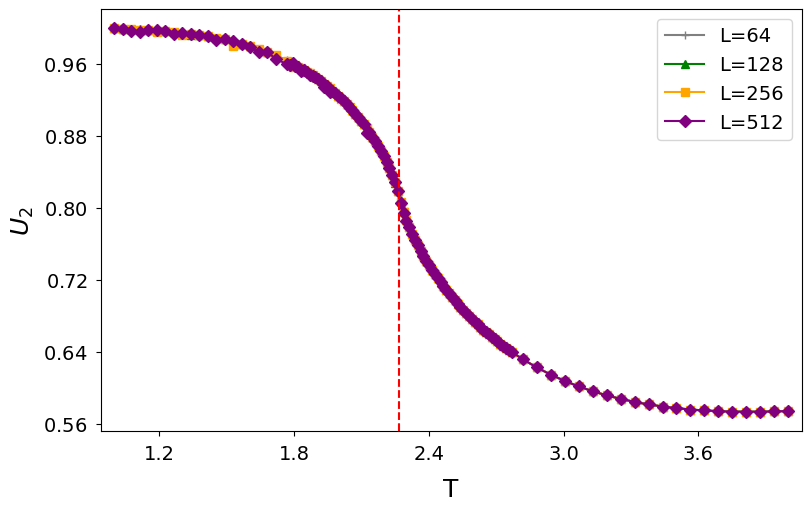

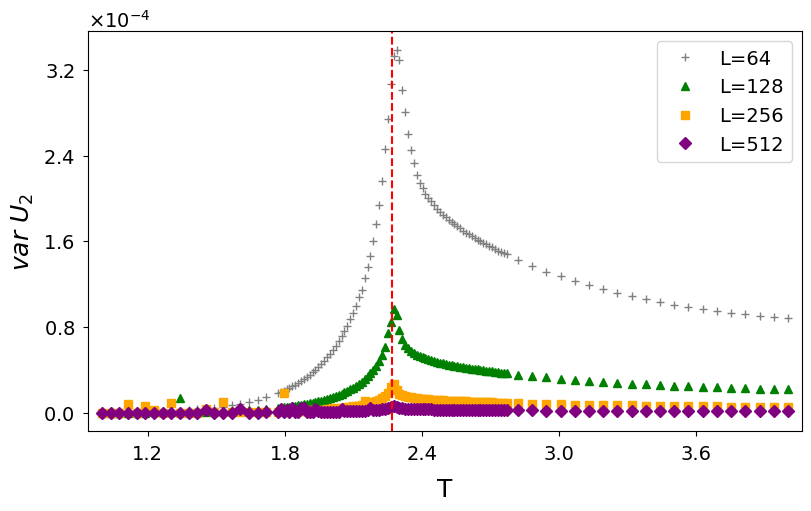

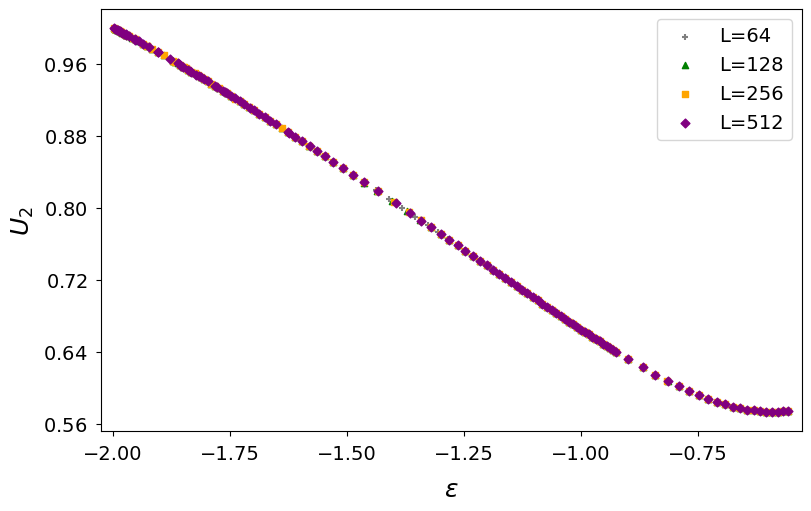

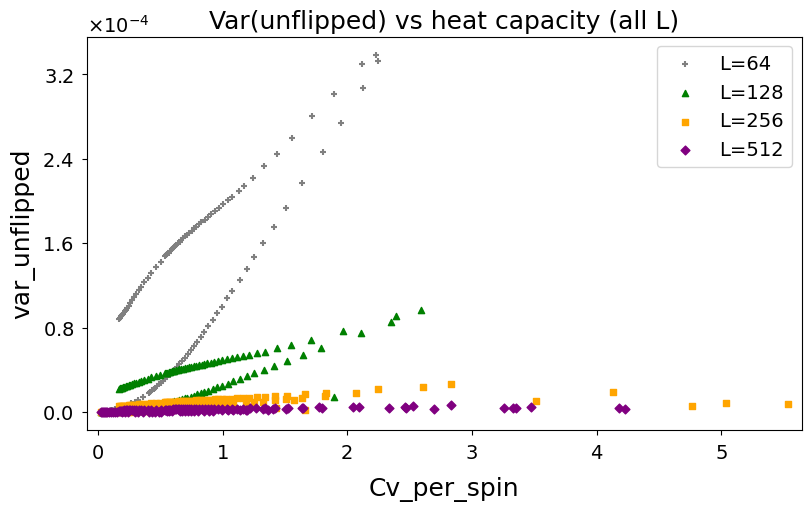

In [170]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

# ---- fixed font sizes everywhere ----
LABEL_FONTSIZE = 18   # axis labels
TICK_FONTSIZE  = 14   # ticks
LEGEND_FONTSIZE = 14  # legend

# ---- list all L values in your dataset ----
Ls = sorted(all_df["L"].unique())
print("Found lattice sizes:", Ls)
prefix = "metropolis_ising_"   # <-- prefix requested


# ---------- global styling helper ----------
def style_axis(ax, *, x_nbins=6, y_nbins=6, y_rotation=90):
    """
    Ensures:
      - tick values fontsize = 16
      - y-label horizontal like x-label, and moved left so it never overlaps ticks
      - no overlap by limiting tick count + layout padding
    """
    # Tick label size + padding
    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE, pad=6)
    ax.tick_params(axis="both", which="minor", labelsize=TICK_FONTSIZE, pad=6)

    # Reduce tick density to avoid collisions
    ax.xaxis.set_major_locator(MaxNLocator(nbins=x_nbins, prune=None))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=y_nbins, prune=None))

    # Clean numeric formatting (esp. tiny y-values) without extra clutter
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(sf)
    ax.yaxis.get_offset_text().set_fontsize(14)
    
    # Label padding
    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 5

    # Horizontal y-label like x-label; move it left to avoid overlap with tick labels
    ax.yaxis.label.set_rotation(y_rotation)  # 0 = horizontal
    if y_rotation == 0:
        ax.yaxis.set_label_coords(-0.14, 0.5)

    # Small margins so data isn't flush against frame
    ax.margins(x=0.02, y=0.05)
    ax.grid(False)


def add_legend(ax):
    ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True)


# === 3. Plot mean_unflipped vs T for ALL L ===
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("T")
    ax.plot(
        dfL["T"],
        dfL["mean_unflipped"],
        color=style["color"],
        marker=style["marker"],
        label=f"L={L}"
    )

ax.axvline(Tc, color="red", linestyle="--")
ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

style_axis(ax, x_nbins=6, y_nbins=6)
add_legend(ax)

fig.savefig(prefix + "mean_unflipped_vs_T.png", dpi=300)
plt.show()


# === 4. Plot var_unflipped vs T for ALL L ===
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("T")
    ax.plot(
        dfL["T"],
        dfL["var_unflipped"],
        color=style["color"],
        marker=style["marker"],
        label=f"L={L}",
        linestyle=""
    )

ax.axvline(Tc, color="red", linestyle="--")
ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$var\ U_2$", fontsize=LABEL_FONTSIZE, rotation=0)

style_axis(ax, x_nbins=6, y_nbins=5)
add_legend(ax)

fig.savefig(prefix + "var_unflipped_vs_T.png", dpi=300)
plt.show()


df_all_sorted = all_df.iloc[(all_df["T"] - Tc).abs().argsort()]  # closest T to Tc
Ec = df_all_sorted["mean_energy_per_spin"].iloc[0]

# === 5. Plot mean_unflipped vs energy (per spin) for ALL L ===
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("mean_energy_per_spin")
    ax.scatter(
        dfL["mean_energy_per_spin"],
        dfL["mean_unflipped"],
        s=20,
        color=style["color"],
        marker=style["marker"],
        label=f"L={L}"
    )

ax.axvline(Ec, color="red", linestyle="")
ax.set_xlabel(r"$\epsilon$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE, rotation=0)

style_axis(ax, x_nbins=6, y_nbins=6)
add_legend(ax)

fig.savefig(prefix + "mean_unflipped_vs_energy.png", dpi=300)
plt.show()


# === 6. Plot var_unflipped vs heat capacity for ALL L ===
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("Cv_per_spin")
    ax.scatter(
        dfL["Cv_per_spin"],
        dfL["var_unflipped"],
        s=20,
        color=style["color"],
        marker=style["marker"],
        label=f"L={L}"
    )

ax.set_xlabel("Cv_per_spin", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("var_unflipped", fontsize=LABEL_FONTSIZE, rotation=0)
ax.set_title("Var(unflipped) vs heat capacity (all L)", fontsize=LABEL_FONTSIZE)

style_axis(ax, x_nbins=6, y_nbins=6)
add_legend(ax)

fig.savefig(prefix + "var_unflipped_vs_heat_capacity.png", dpi=300)
plt.show()

# Как положение максимумов падает

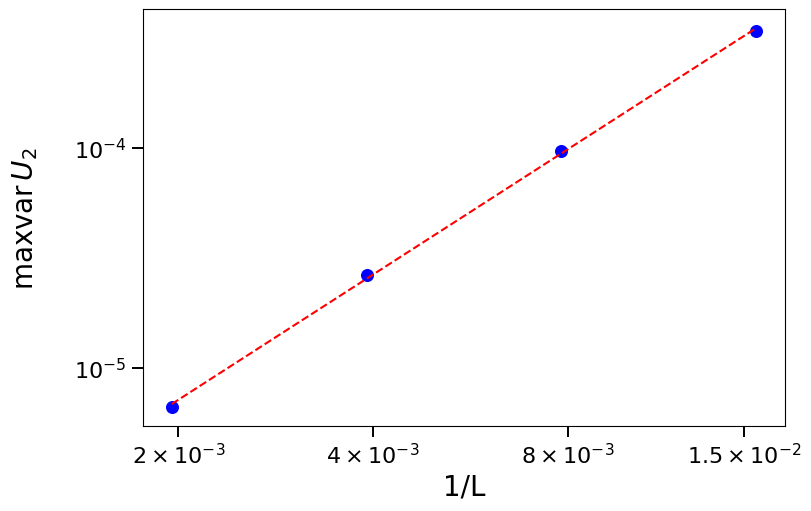

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullLocator

# ---- fixed font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# === 7. Plot max(var_unflipped) vs L ===
max_var = (
    all_df.groupby("L")["var_unflipped"]
    .max()
    .reset_index()
    .sort_values("L")
)

max_var["invL"] = 1 / max_var["L"]

# ---- log-log linear fit ----
x = max_var["invL"].values
y = max_var["var_unflipped"].values

logx = np.log10(x)
logy = np.log10(y)

coefficients, cov_matrix  = np.polyfit(logx, logy, 1, cov='unscaled')

slope, intercept = coefficients

x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
y_fit = 10 ** (intercept + slope * np.log10(x_fit))

# ---- plotting ----
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# Data
ax.scatter(x, y, color="blue", s=70)

# Fit
ax.plot(x_fit, y_fit, color="red", linestyle="--",
        label=rf"slope = {slope:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")

# ---- labels ----
ax.set_xlabel("1/L", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\max \mathrm{var}\, U_2$",
              fontsize=LABEL_FONTSIZE)

# Move horizontal y-label left
ax.yaxis.set_label_coords(-0.16, 0.5)

# ---- EXACT X TICKS (only these four) ----
xticks = np.array([2e-3, 4e-3, 8e-3, 1.5e-2])
ax.set_xticks(xticks)

def sci_formatter(val, pos):
    exponent = int(np.floor(np.log10(val)))
    mantissa = val / 10**exponent

    if np.isclose(mantissa, round(mantissa)):
        mantissa_str = f"{int(round(mantissa))}"
    else:
        mantissa_str = f"{mantissa:g}"

    return rf"${mantissa_str}\times10^{{{exponent}}}$"

ax.xaxis.set_major_formatter(FuncFormatter(sci_formatter))

# ---- REMOVE ALL MINOR TICKS ----
ax.minorticks_off()
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# ---- tick styling ----
ax.tick_params(axis='both', which='major',
               labelsize=TICK_FONTSIZE,
               length=8, width=1.4)

ax.grid(False)

fig.savefig(prefix + "max_var_unflipped_vs_L.png", dpi=300)
plt.show()

In [27]:
# ---- compute statistical error of slope ----
slope_error = np.sqrt(cov_matrix[0, 0])

print(f"Slope = {slope:.5f} ± {slope_error:.5f}")

x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
y_fit = 10 ** (intercept + slope * np.log10(x_fit))

Slope = 1.88985 ± 1.48561


In [16]:
coefficients, np.sqrt(np.diag(cov_matrix))

(array([ 1.88985158, -0.04387535]), array([1.48561141, 3.39116499]))

Estimated critical energy per spin Ec: -1.4338955850982666
Points in fitting window: 32
Slope near critical point: -0.347344
Intercept: 0.320177


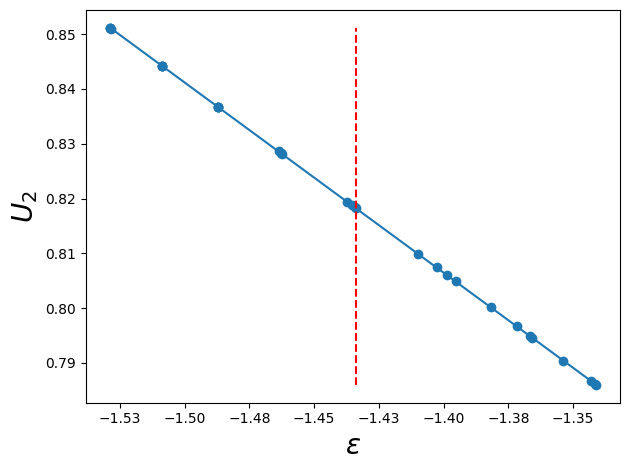

In [8]:
# Как положение максимумов падает
import numpy as np
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import StrMethodFormatter

# ---- Step 1: estimate critical energy Ec using the data closest to Tc ----
df_all_sorted = all_df.iloc[(all_df["T"] - Tc).abs().argsort()]  # closest T to Tc
Ec = df_all_sorted["mean_energy_per_spin"].iloc[0]
print("Estimated critical energy per spin Ec:", Ec)

# ---- Step 2: choose an energy window around Ec ----
deltaE = 0.1   # you may adjust this window
mask = (all_df["mean_energy_per_spin"] > Ec - deltaE) & \
       (all_df["mean_energy_per_spin"] < Ec + deltaE)

df_window = all_df[mask].copy().sort_values("mean_energy_per_spin")
print("Points in fitting window:", len(df_window))

# ---- Step 3: linear fit y = a x + b ----
X = df_window["mean_energy_per_spin"].values.reshape(-1, 1)
y = df_window["mean_unflipped"].values

model = LinearRegression().fit(X, y)
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope near critical point: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")

# ---- Optional: plot the fit ----
plt.figure()
plt.scatter(X, y, label="data (window)")
plt.plot(X, model.predict(X), label=f"fit (slope={slope:.3f})")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
plt.xlabel(r"$\epsilon$", fontsize = fontsize)
plt.ylabel(r"$U_2$", fontsize = fontsize)
# plt.title("Local linear slope near critical energy")
plt.vlines(Ec, 
           ymin = df_window.mean_unflipped.min(), 
           ymax = df_window.mean_unflipped.max(), 
           ls = '--', 
           color = 'red', label = f'Ec={round(Ec,3)}')
# plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig(prefix + "local_linear_slope.png", dpi=300)  # <-- save
plt.show()


In [10]:
# linear fit with covariance
x = df_window["mean_energy_per_spin"].values
y = df_window["mean_unflipped"].values

coeffs, cov_matrix = np.polyfit(x, y, deg=1, cov=True)

slope = coeffs[0]
intercept = coeffs[1]

slope_error = np.sqrt(cov_matrix[0, 0])

print(f"Slope = {slope:.6f} ± {slope_error:.6f}")

Slope = -0.347344 ± 0.000157


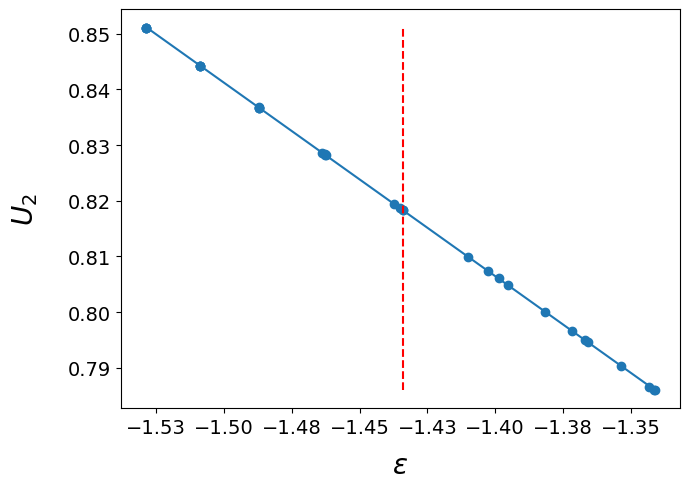

In [61]:
# ---- Optional: plot the fit ----
plt.figure(figsize=(7,5))

plt.scatter(X, y, label="data (window)")
plt.plot(X, model.predict(X), label=f"fit (slope={slope:.3f})")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

# ---- Larger axis labels with padding ----
plt.xlabel(r"$\epsilon$", fontsize=20, labelpad=10)
plt.ylabel(r"$U_2$", fontsize=20, labelpad=20)  # <-- key fix

# ---- Larger tick values ----
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Optional: add extra space on the left
plt.gcf().subplots_adjust(left=0.18)

plt.vlines(
    Ec,
    ymin=df_window.mean_unflipped.min(),
    ymax=df_window.mean_unflipped.max(),
    ls='--',
    color='red',
    label=f'Ec={round(Ec,3)}'
)

plt.gbrid(False)
plt.tight_layout()
plt.savefig(prefix + "local_linear_slope.png", dpi=300)  # <-- save
plt.show()

In [24]:
model.coef_

array([-0.34734359])

# Potts metropolis

In [11]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === CONFIG ===
BASE_DIR = "/Users/ianpile/Downloads/results_metropolis_potts3"
Tc = 1/np.log(1+np.sqrt(3))  # critical temperature

# === 1. Load all CSVs into one DataFrame ===
pattern = os.path.join(BASE_DIR, "L*", "metropolis_potts3_L*_T*.csv")
files = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No CSV files found with pattern: {pattern}")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# Optional: sort by L and T for sanity
all_df = all_df.sort_values(["L", "T"]).reset_index(drop=True)

print("Combined DataFrame shape:", all_df.shape)
# print(all_df.head())

Combined DataFrame shape: (480, 19)


In [12]:
all_df.to_csv('potts_metropolis.csv', index = False)

Found lattice sizes: [64, 128, 256, 512]


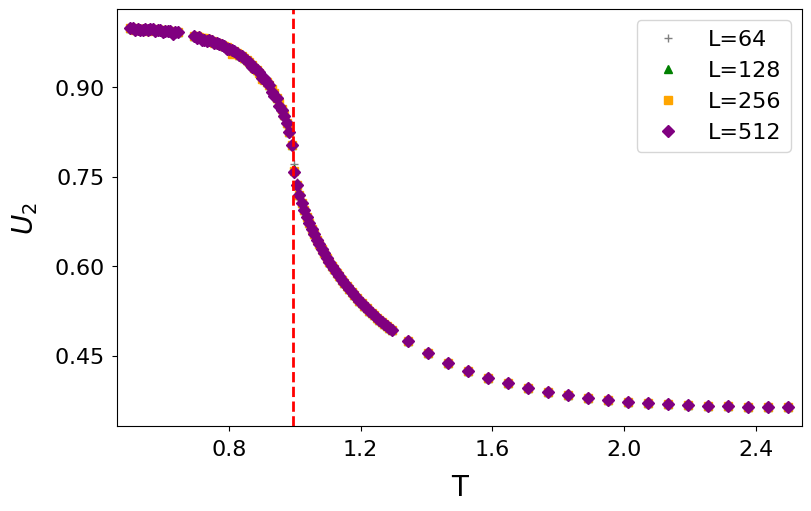

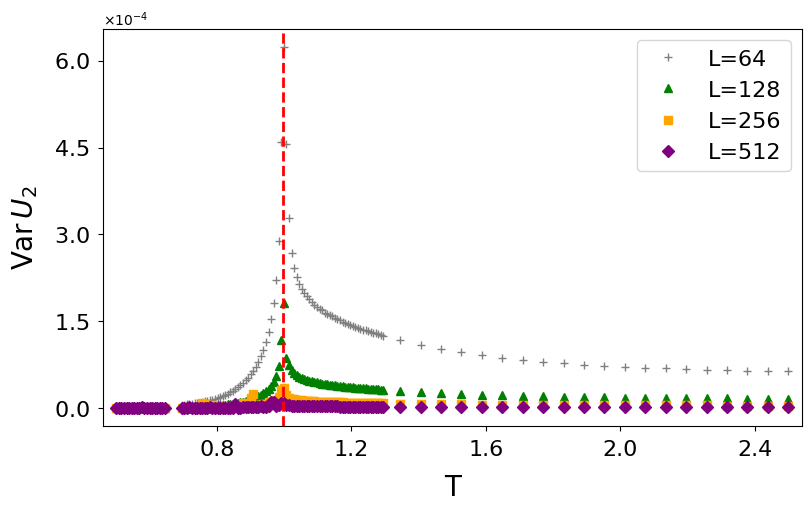

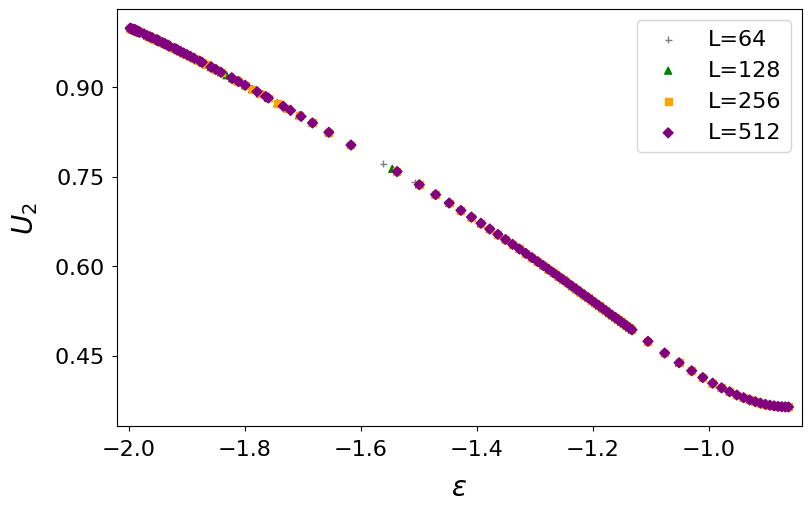

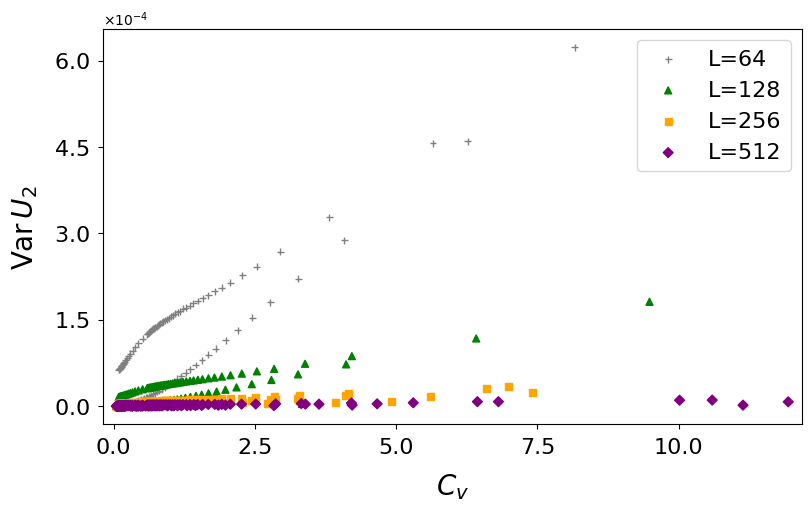

In [187]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

# ---- fixed font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# ---- list all L values in your dataset ----
Ls = sorted(all_df["L"].unique())
print("Found lattice sizes:", Ls)

prefix = "potts_metropolis_"


# ---------- styling helper (same logic as Ising, but NO rotation=0) ----------
def style_axis(ax, *, x_nbins=6, y_nbins=6):
    ax.tick_params(axis="both", which="major",
                   labelsize=TICK_FONTSIZE, pad=6)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=x_nbins))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=y_nbins))

    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(sf)

    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 10

    ax.margins(x=0.02, y=0.05)
    ax.grid(False)


def add_legend(ax):
    ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True)


# ---------------------------------------------------------
# 1. mean_unflipped vs T
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("T")
    ax.plot(dfL["T"],
            dfL["mean_unflipped"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}", linestyle = '')

ax.axvline(Tc, color="red", linestyle="--", linewidth=2)

ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

style_axis(ax)
add_legend(ax)

fig.savefig(prefix + "mean_unflipped_vs_T.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 2. var_unflipped vs T
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("T")
    ax.plot(dfL["T"],
            dfL["var_unflipped"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}", linestyle = '')

ax.axvline(Tc, color="red", linestyle="--", linewidth=2)

ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

style_axis(ax, y_nbins=5)
add_legend(ax)

fig.savefig(prefix + "var_unflipped_vs_T.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 3. mean_unflipped vs energy per spin
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("mean_energy_per_spin")
    ax.scatter(dfL["mean_energy_per_spin"],
               dfL["mean_unflipped"],
               s=25,
               color=style["color"],
               marker=style["marker"],
               label=f"L={L}", linestyle = '')

ax.set_xlabel(r"$\epsilon$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

style_axis(ax)
add_legend(ax)

fig.savefig(prefix + "mean_unflipped_vs_energy.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 4. var_unflipped vs heat capacity
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    dfL = all_df[all_df["L"] == L].sort_values("Cv_per_spin")
    ax.scatter(dfL["Cv_per_spin"],
               dfL["var_unflipped"],
               s=25,
               color=style["color"],
               marker=style["marker"],
               label=f"L={L}", linestyle = '')

ax.set_xlabel(r"$C_v$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

style_axis(ax)
add_legend(ax)

fig.savefig(prefix + "var_unflipped_vs_heat_capacity.png", dpi=300)
plt.show()


In [16]:
# ---- compute statistical error of slope ----
slope_error = np.sqrt(cov_matrix[0, 0])

print(f"Slope = {slope:.5f} ± {slope_error:.5f}")

x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
y_fit = 10 ** (intercept + slope * np.log10(x_fit))

Slope = 2.00824 ± 1.48561


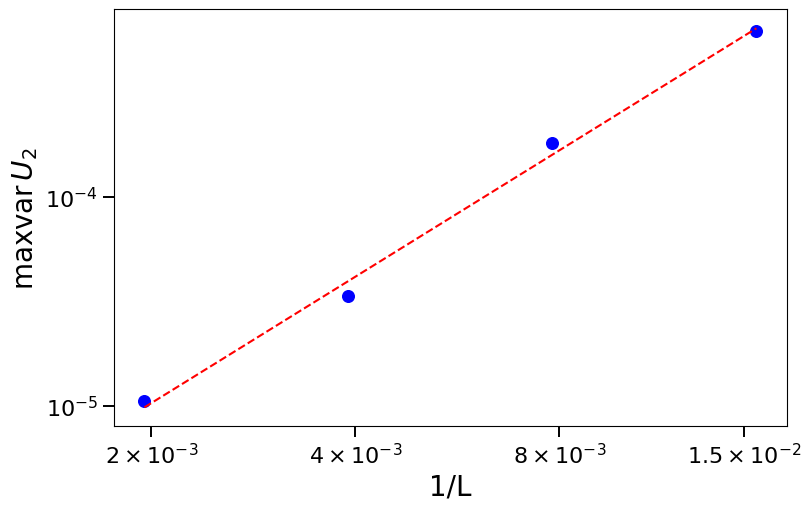

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullLocator

# ---- fixed font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# === 7. Plot max(var_unflipped) vs L (Potts) ===
max_var_potts = (
    all_df.groupby("L")["var_unflipped"]
    .max()
    .reset_index()
    .sort_values("L")
)

max_var_potts["invL"] = 1 / max_var_potts["L"]

# ---- log-log linear fit ----
x = max_var_potts["invL"].values
y = max_var_potts["var_unflipped"].values

logx = np.log10(x)
logy = np.log10(y)

coefficients, cov_matrix  = np.polyfit(logx, logy, 1, cov='unscaled')

slope, intercept = coefficients

x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
y_fit = 10 ** (intercept + slope * np.log10(x_fit))

# ---- plotting ----
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# Blue scatter (no connecting line)
ax.scatter(x, y, color="blue", s=70)

# Red dashed fit
ax.plot(x_fit, y_fit, color="red", linestyle="--",
        label=rf"slope = {slope:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")

# ---- labels ----
ax.set_xlabel("1/L", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\max \mathrm{var}\, U_2$",
              fontsize=LABEL_FONTSIZE)

# ---- EXACT X TICKS (same as Ising) ----
xticks = np.array([2e-3, 4e-3, 8e-3, 1.5e-2])
ax.set_xticks(xticks)

def sci_formatter(val, pos):
    exponent = int(np.floor(np.log10(val)))
    mantissa = val / 10**exponent

    if np.isclose(mantissa, round(mantissa)):
        mantissa_str = f"{int(round(mantissa))}"
    else:
        mantissa_str = f"{mantissa:g}"

    return rf"${mantissa_str}\times10^{{{exponent}}}$"

ax.xaxis.set_major_formatter(FuncFormatter(sci_formatter))

# ---- remove all minor ticks ----
ax.minorticks_off()
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# ---- tick styling ----
ax.tick_params(axis='both', which='major',
               labelsize=TICK_FONTSIZE,
               length=8, width=1.4)

ax.grid(False)

fig.savefig(prefix + "max_var_unflipped_vs_L.png", dpi=300)
plt.show()

In [18]:
# ---- compute statistical error of slope ----
slope_error = np.sqrt(cov_matrix[0, 0])

print(f"Slope = {slope:.5f} ± {slope_error:.5f}")

x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
y_fit = 10 ** (intercept + slope * np.log10(x_fit))

Slope = 2.00824 ± 1.48561


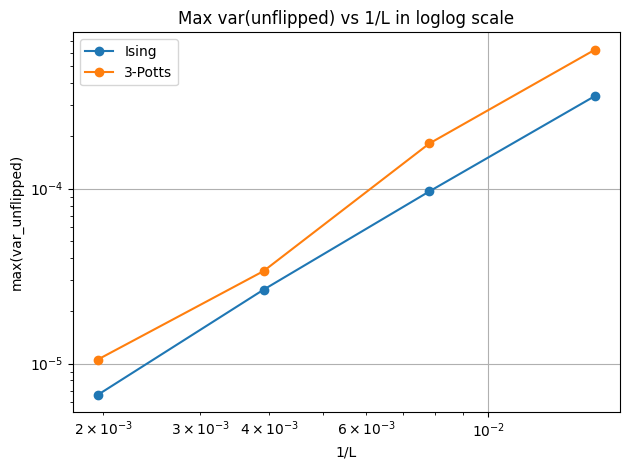

In [18]:
plt.figure()
plt.loglog(max_var["invL"], max_var["var_unflipped"], marker="o", linestyle="-", label = 'Ising')
plt.loglog(max_var_potts["invL"], max_var_potts["var_unflipped"], marker="o", linestyle="-",label = '3-Potts')
plt.xlabel("1/L")
plt.ylabel("max(var_unflipped)")
plt.title("Max var(unflipped) vs 1/L in loglog scale")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

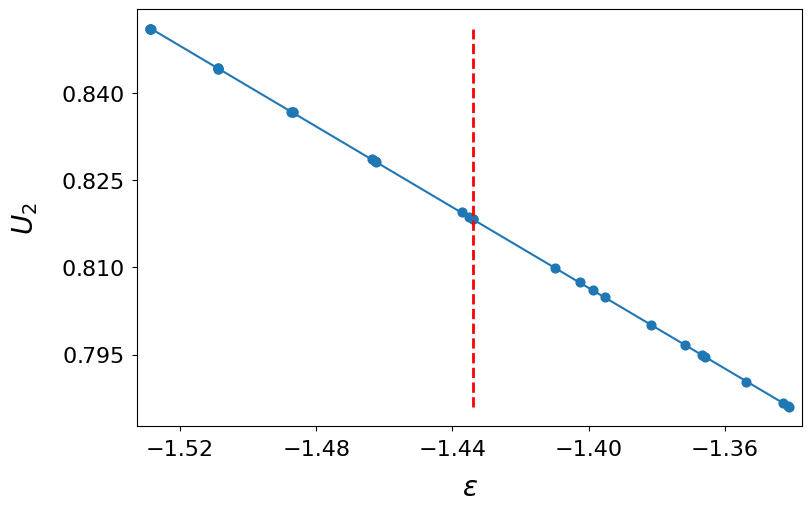

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter, StrMethodFormatter
from sklearn.linear_model import LinearRegression

# ---- fixed font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# =========================================================
# Step 1: estimate critical energy Ec
# =========================================================
df_all_sorted = all_df.iloc[(all_df["T"] - Tc).abs().argsort()]
Ec = df_all_sorted["mean_energy_per_spin"].iloc[0]

# =========================================================
# Step 2: choose fitting window
# =========================================================
deltaE = 0.1
mask = (
    (all_df["mean_energy_per_spin"] > Ec - deltaE) &
    (all_df["mean_energy_per_spin"] < Ec + deltaE)
)

df_window = all_df[mask].copy().sort_values("mean_energy_per_spin")

# =========================================================
# Step 3: linear fit
# =========================================================
X = df_window["mean_energy_per_spin"].values.reshape(-1, 1)
y = df_window["mean_unflipped"].values

model = LinearRegression().fit(X, y)
slope = model.coef_[0]

# =========================================================
# Step 4: Styled Plot (analogous to Ising)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# ---- Scatter (default matplotlib blue) ----
ax.scatter(X, y, s=40, label="Data (window)")

# ---- Fit line (default matplotlib orange) ----
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = model.predict(x_fit.reshape(-1, 1))
ax.plot(x_fit, y_fit, linestyle="-",
        label=rf"Fit (slope={slope:.3f})")

# ---- Vertical critical energy line (red dashed) ----
ax.vlines(
    Ec,
    ymin=y.min(),
    ymax=y.max(),
    colors='red',
    linestyles='--',
    linewidth=2,
    label=rf"$E_c={Ec:.3f}$"
)

# ---- Axis labels ----
ax.set_xlabel(r"$\epsilon$", fontsize=LABEL_FONTSIZE, labelpad=10)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE, labelpad=15)

# ---- Tick formatting ----
ax.tick_params(axis="both", which="major",
               labelsize=TICK_FONTSIZE, pad=6)

ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(sf)

ax.margins(x=0.02, y=0.05)
ax.grid(False)

# ax.legend(fontsize=LEGEND_FONTSIZE)

fig.savefig(prefix + "local_linear_slope.png", dpi=300)
plt.show()

In [20]:
# linear fit with covariance
x = df_window["mean_energy_per_spin"].values
y = df_window["mean_unflipped"].values

coeffs, cov_matrix = np.polyfit(x, y, deg=1, cov=True)

slope = coeffs[0]
intercept = coeffs[1]

slope_error = np.sqrt(cov_matrix[0, 0])

print(f"Slope = {slope:.6f} ± {slope_error:.6f}")

Slope = -0.573509 ± 0.001870


# Swendsen-Wang Ising

Found 600 SW files
L values: [64, 128, 256, 512, 1024]


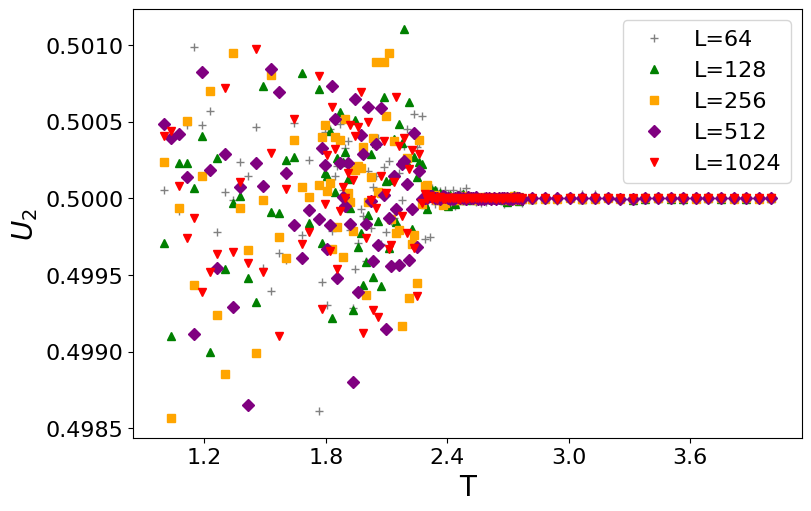

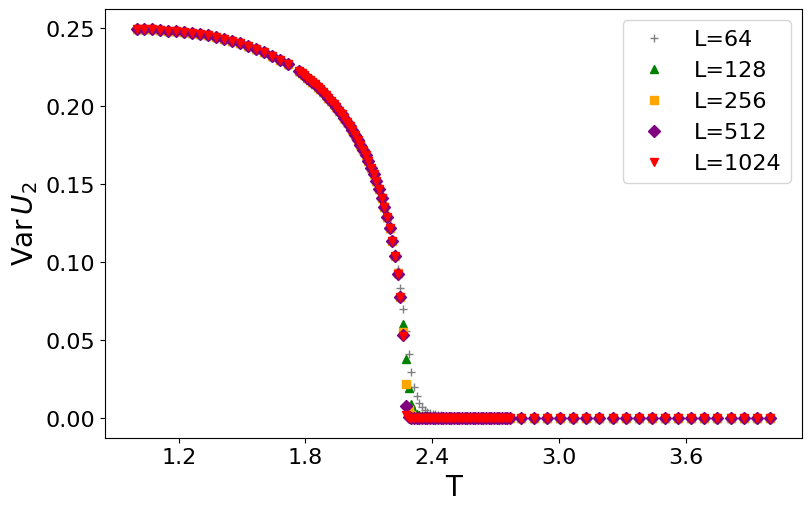

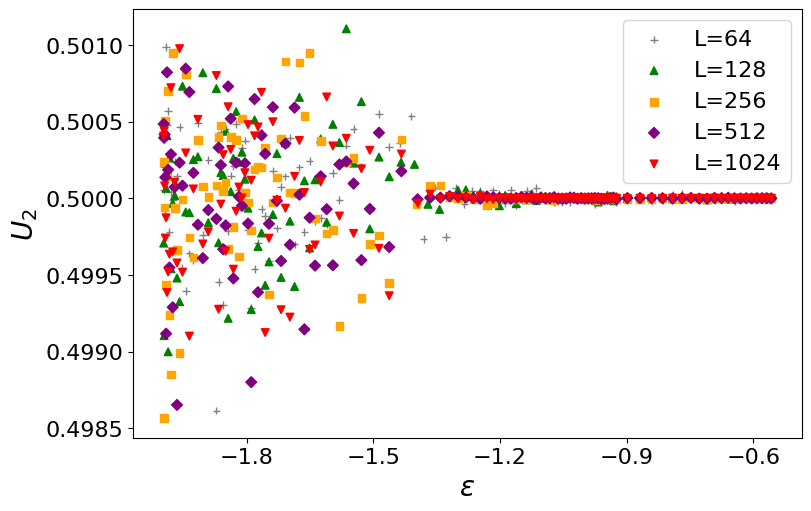

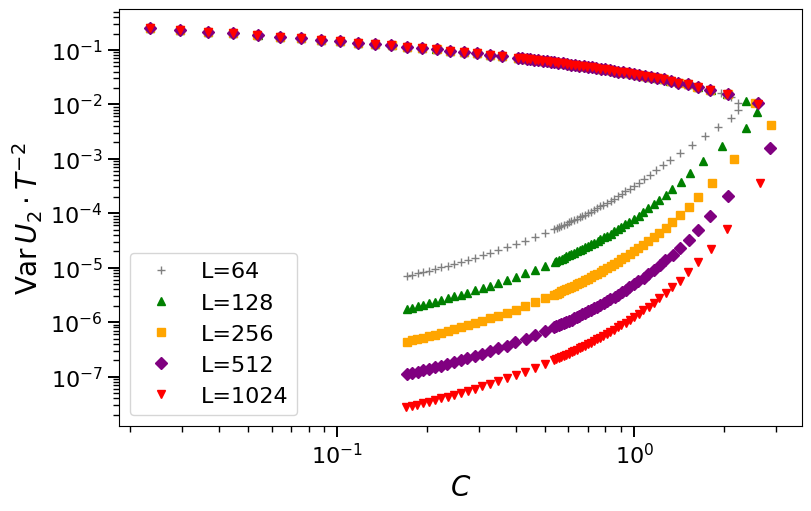

In [13]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, LogFormatterMathtext, NullFormatter

# ---- global font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# ===============================
# Load ALL Swendsen–Wang results
# ===============================
base = "/Users/ianpile/Downloads/results_sw"
pattern = os.path.join(base, "L*", "swendsen_L*.csv")

files = glob.glob(pattern)
print(f"Found {len(files)} SW files")

dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(["L", "T"])
Ls = sorted(df["L"].unique())
print("L values:", Ls)

prefix = "sw_ising_"


# ============================================================
# 1. Overlap vs T
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    ax.plot(sub["T"],
            sub["mean_two_step_overlap"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}", linestyle = '')

ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "overlap_vs_T.png", dpi=300)
plt.show()


# ============================================================
# 2. Variance(overlap) vs T
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    ax.plot(sub["T"],
            sub["var_two_step_overlap"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}", linestyle = '')

ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "var_overlap_vs_T.png", dpi=300)
plt.show()


# ============================================================
# 3. Overlap vs Energy per spin
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    ax.scatter(sub["mean_energy_per_spin"],
               sub["mean_two_step_overlap"],
               s=30,
               color=style["color"],
               marker=style["marker"],
               label=f"L={L}", linestyle = '')

ax.set_xlabel(r"$\epsilon$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "overlap_vs_energy.png", dpi=300)
plt.show()


# ============================================================
# 4. Var(overlap)*T^{-2} vs Heat Capacity (log-log)
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    y = sub["var_two_step_overlap"] * (sub["T"]**(-2))

    ax.loglog(sub["Cv_per_spin"],
              y,
              color=style["color"],
              marker=style["marker"],
              label=f"L={L}", linestyle = '')

ax.set_xlabel(r"$C$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2 \cdot T^{-2}$", fontsize=LABEL_FONTSIZE)

# Clean log ticks
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(axis="both", which="major",
               labelsize=TICK_FONTSIZE,
               length=8, width=1.4)

ax.tick_params(axis="both", which="minor",
               length=4, width=1.0)

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "var_overlap_vs_Cv_loglog.png", dpi=300)
plt.show()

L=64: alpha = 0.2662
L=128: alpha = 0.2790
L=256: alpha = 0.2851
L=512: alpha = 0.2874
L=1024: alpha = 0.2880


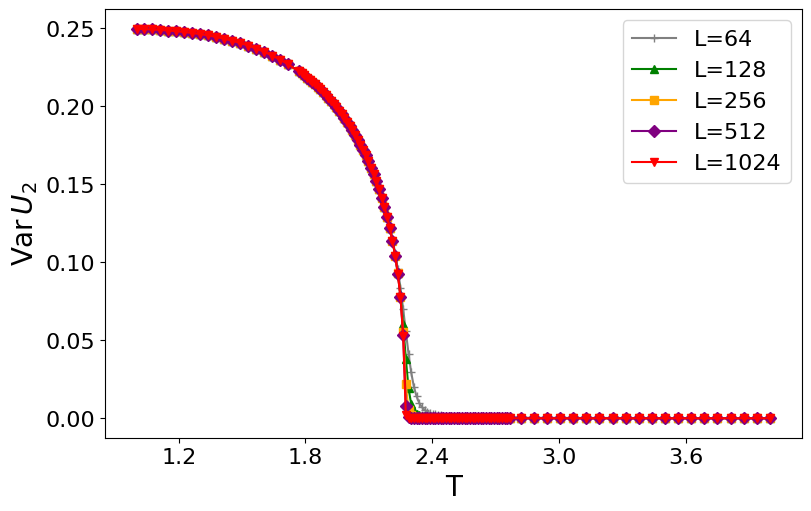


Critical exponents:
L=64: alpha = 0.2662
L=128: alpha = 0.2790
L=256: alpha = 0.2851
L=512: alpha = 0.2874
L=1024: alpha = 0.2880


In [43]:
delta = 1.2         # ширина окна слева от Tc (например 0.05 или 0.1)
Ls = sorted(df["L"].unique())

# ===================== ГРАФИК =====================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

alphas = {}

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L].copy()

    # --- основной график ---
    ax.plot(sub["T"],
            sub["var_two_step_overlap"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}")

    # ===================== ОЦЕНКА СТЕПЕНИ =====================
    fit = sub[(sub["T"] < Tc) & (sub["T"] > Tc - delta)].copy()

    # убираем нули/отрицательные значения
    fit = fit[fit["var_two_step_overlap"] > 0]

    if len(fit) > 3:
        x = np.log(Tc - fit["T"].values)
        y = np.log(fit["var_two_step_overlap"].values)

        coeffs = np.polyfit(x, y, 1)
        alpha = coeffs[0]
        alphas[L] = alpha

        print(f"L={L}: alpha = {alpha:.4f}")

# ===================== ОФОРМЛЕНИЕ =====================
ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "var_overlap_vs_T.png", dpi=300)
plt.show()

# ===================== ВЫВОД =====================
print("\nCritical exponents:")
for L, alpha in alphas.items():
    print(f"L={L}: alpha = {alpha:.4f}")

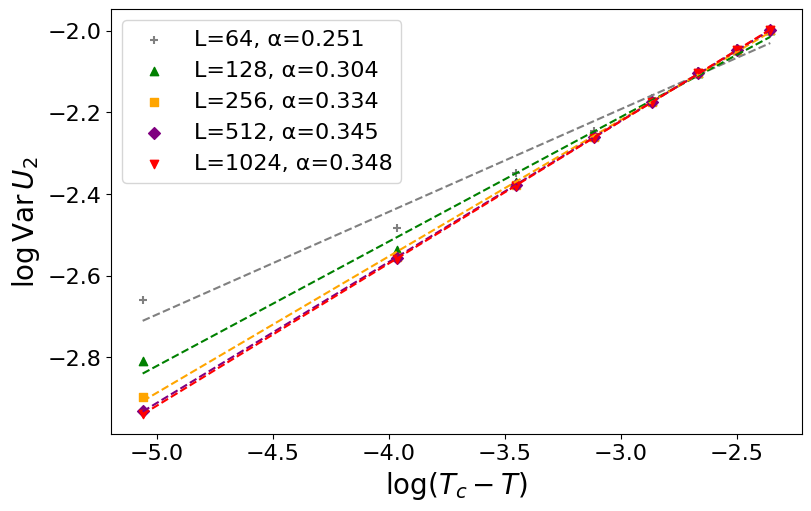

In [44]:
# ===================== ЛОГ-ЛОГ ФИТ =====================
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)

delta = 0.1

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L].copy()

    fit = sub[(sub["T"] < Tc) & (sub["T"] > Tc - delta)].copy()
    fit = fit[fit["var_two_step_overlap"] > 0]

    if len(fit) > 3:
        x = np.log(Tc - fit["T"].values)
        y = np.log(fit["var_two_step_overlap"].values)

        coeffs = np.polyfit(x, y, 1)
        alpha = coeffs[0]

        # --- точки ---
        ax2.scatter(x, y,
                    color=style["color"],
                    marker=style["marker"],
                    label=f"L={L}, α={alpha:.3f}")

        # --- линия фита ---
        x_fit = np.linspace(min(x), max(x), 100)
        y_fit = np.polyval(coeffs, x_fit)

        ax2.plot(x_fit, y_fit,
                 color=style["color"],
                 linestyle="--")

# ===================== ОФОРМЛЕНИЕ =====================
ax2.set_xlabel(r"$\log(T_c - T)$", fontsize=LABEL_FONTSIZE)
ax2.set_ylabel(r"$\log \mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax2.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax2.grid(False)
ax2.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "loglog_fit_var_overlap.png", dpi=300)
plt.show()

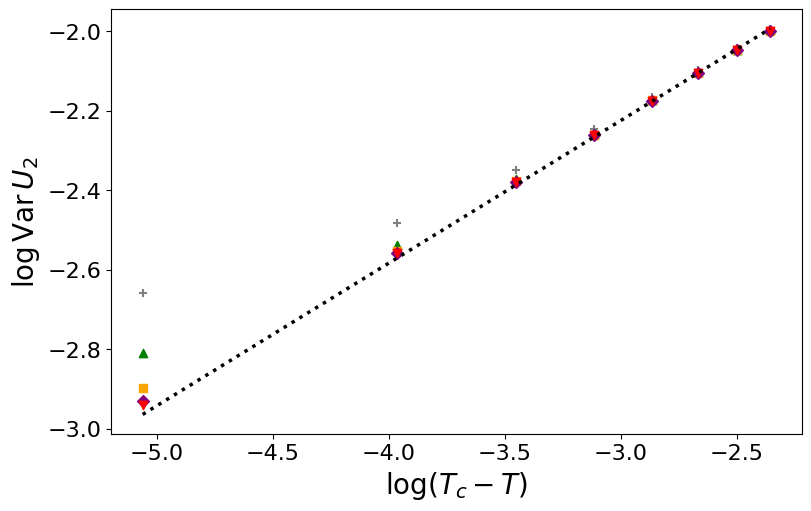

In [78]:
# ===================== ЛОГ-ЛОГ ФИТ =====================
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)

delta = 0.1
data_by_L = {}

# ===================== СБОР ДАННЫХ =====================
for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L].copy()

    fit = sub[(sub["T"] < Tc) & (sub["T"] > Tc - delta)].copy()
    fit = fit[fit["var_two_step_overlap"] > 0]

    if len(fit) > 3:
        x = np.log(Tc - fit["T"].values)
        y = np.log(fit["var_two_step_overlap"].values)

        # сортировка
        idx = np.argsort(x)
        x, y = x[idx], y[idx]

        data_by_L[L] = (x, y)

        # --- фит для каждого L ---
        coeffs = np.polyfit(x, y, 1)
        alpha = coeffs[0]

        ax2.scatter(x, y,
                    color=style["color"],
                    marker=style["marker"],
                    label=f"L={L}, α={alpha:.3f}")

        x_fit = np.linspace(min(x), max(x), 100)
        y_fit = np.polyval(coeffs, x_fit)

#         ax2.plot(x_fit, y_fit,
#                  color=style["color"],
#                  linestyle="--")

# ===================== ЭКСТРАПОЛЯЦИЯ L → ∞ =====================
from scipy.optimize import curve_fit

def lin_invL(L, y_inf, a):
    return y_inf + a / L

# общий диапазон x (пересечение)
x_min = max([min(v[0]) for v in data_by_L.values()])
x_max = min([max(v[0]) for v in data_by_L.values()])
common_x = np.linspace(x_min, x_max, 100)

Ls_sorted = np.array(sorted(data_by_L.keys()))
y_inf_vals = []

# ===================== ПОТОЧЕЧНАЯ ЭКСТРАПОЛЯЦИЯ =====================
for x0 in common_x:
    y_vs_L = []

    for L in Ls_sorted:
        x, y = data_by_L[L]

        if x0 >= x[0] and x0 <= x[-1]:
            y_interp = np.interp(x0, x, y)
            y_vs_L.append(y_interp)
        else:
            y_vs_L.append(np.nan)

    y_vs_L = np.array(y_vs_L)

    mask = ~np.isnan(y_vs_L)
    L_fit = Ls_sorted[mask]
    y_fit = y_vs_L[mask]

    if len(L_fit) >= 3:
        try:
            popt, _ = curve_fit(lin_invL, L_fit, y_fit)
            y_inf = popt[0]

            if not np.isfinite(y_inf) or abs(y_inf) > 5:
                raise RuntimeError

        except:
            y_inf = y_fit[-1]
    else:
        y_inf = np.nan

    y_inf_vals.append(y_inf)

y_inf_vals = np.array(y_inf_vals)

# ===================== ФИТ α В ПРЕДЕЛЕ L → ∞ =====================
mask = np.isfinite(y_inf_vals)

x_fit_inf = common_x[mask]
y_fit_inf = y_inf_vals[mask]

# линейный фит
coeffs_inf = np.polyfit(x_fit_inf, y_fit_inf, 1)
alpha_inf = coeffs_inf[0]

# линия фита
x_line = np.linspace(min(x_fit_inf), max(x_fit_inf), 200)
y_line = np.polyval(coeffs_inf, x_line)

# ===================== РИСУЕМ =====================
# кривая L → ∞
# ax2.plot(common_x, y_inf_vals,
#          color="black",
#          linewidth=3,
#          label=r"$L \to \infty$")

# линия α∞
ax2.plot(x_line, y_line,
         color="black",
         linestyle=":",
         linewidth=2.5,
         label=rf"$\alpha_{{\infty}} = {alpha_inf:.4f}$")

# ===================== ОФОРМЛЕНИЕ =====================
ax2.set_xlabel(r"$\log(T_c - T)$", fontsize=LABEL_FONTSIZE)
ax2.set_ylabel(r"$\log \mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax2.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax2.grid(False)
# ax2.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "loglog_fit_var_overlap.png", dpi=300)
plt.show()

In [14]:
df.to_csv('ising_swendsen_wang.csv', index = False)

# Var at T_c Ising SW

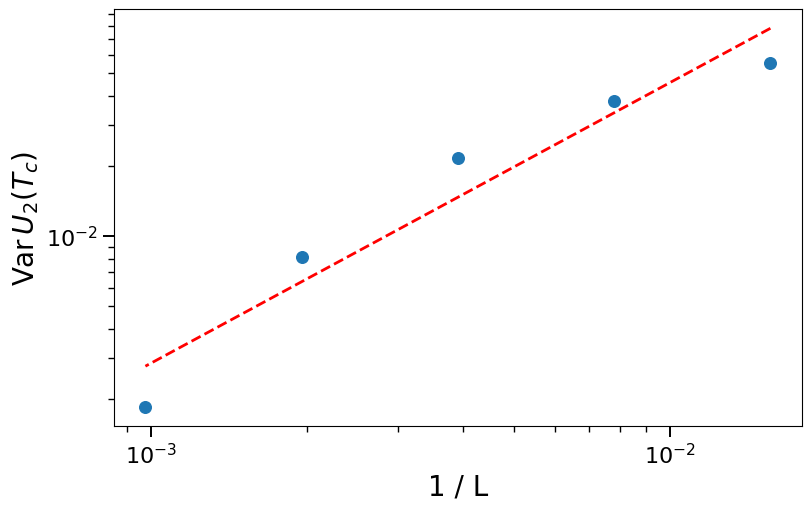


Log–log linear fit:
a = 11.69
b = 1.2043 ± 0.1870


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

# ---- global font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16


def plot_finite_size_scaling_var(df, Tc, prefix="sw_potts_"):
    """
    Finite-size scaling via log-log linear fit:
    Var(overlap at Tc) ~ L^{-b}
    """

    # -------------------------------------------------
    # Pick closest T to Tc for each L
    # -------------------------------------------------
    Ls = []
    vars_tc = []

    for L in sorted(df["L"].unique()):
        sub = df[df["L"] == L]
        idx = (sub["T"] - Tc).abs().idxmin()
        row = sub.loc[idx]

        Ls.append(L)
        vars_tc.append(row["var_two_step_overlap"])

    Ls = np.array(Ls, dtype=float)
    vars_tc = np.array(vars_tc, dtype=float)
    invL = 1.0 / Ls

    # -------------------------------------------------
    # Log-log linear fit
    # -------------------------------------------------
    logL = np.log(Ls)
    logy = np.log(vars_tc)

    (slope, intercept), cov = np.polyfit(logL, logy, 1, cov=True)

    b_fit = -slope
    b_err = np.sqrt(cov[0, 0])
    a_fit = np.exp(intercept)

    # Smooth curve
    L_fit = np.linspace(Ls.min(), Ls.max(), 300)
    invL_fit = 1.0 / L_fit
    y_fit = a_fit * L_fit**(-b_fit)

    # -------------------------------------------------
    # Styled Plot (consistent with your scaling figures)
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

    # Data (blue scatter)
    ax.scatter(invL, vars_tc, s=70, label="Data")

    # Fit (red dashed)
    ax.loglog(
        invL_fit,
        y_fit,
        linestyle="--",
        color="red",
        linewidth=2,
        label=rf"Fit: $ \propto L^{{-{b_fit:.2f} \pm {b_err:.2f}}}$"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    # Axis labels
    ax.set_xlabel("1 / L", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"$\mathrm{Var}\, U_2(T_c)$", fontsize=LABEL_FONTSIZE)

    # Clean log ticks
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.tick_params(axis="both", which="major",
                   labelsize=TICK_FONTSIZE,
                   length=8, width=1.4)

    ax.tick_params(axis="both", which="minor",
                   length=4, width=1.0)

    ax.grid(False)
#     ax.legend(fontsize=LEGEND_FONTSIZE)

    plt.savefig(prefix + "var_overlap_at_Tc_FSS_loglog_linear.png", dpi=300)
    plt.show()

    # -------------------------------------------------
    # Print results
    # -------------------------------------------------
    print("\nLog–log linear fit:")
    print(f"a = {a_fit:.4g}")
    print(f"b = {b_fit:.4f} ± {b_err:.4f}")


# ================================
# Run
# ================================
prefix = "sw_ising_"

Tc = 2 / np.log(1 + np.sqrt(2))  # Ising Tc
plot_finite_size_scaling_var(df, Tc=Tc, prefix=prefix)

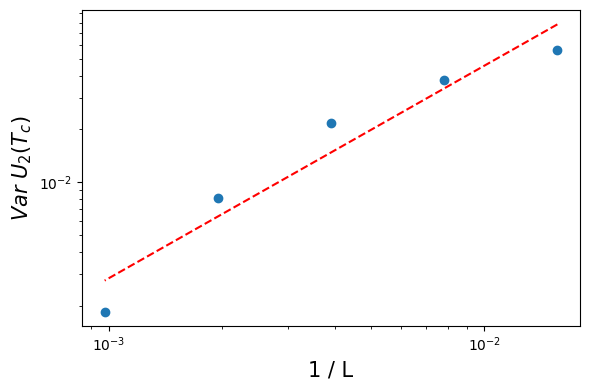


Log–log linear fit:
a = 11.69
b = 1.2043 ± 0.1870


In [53]:
prefix = "sw_ising_"  # change if needed

Tc = 2 / np.log(1 + np.sqrt(2))  # Ising critical temperature
plot_finite_size_scaling_var(df, Tc=Tc, prefix = prefix)

# Swendsen-Wang Potts

Found 600 SW files
L values: [64, 128, 256, 512, 1024]


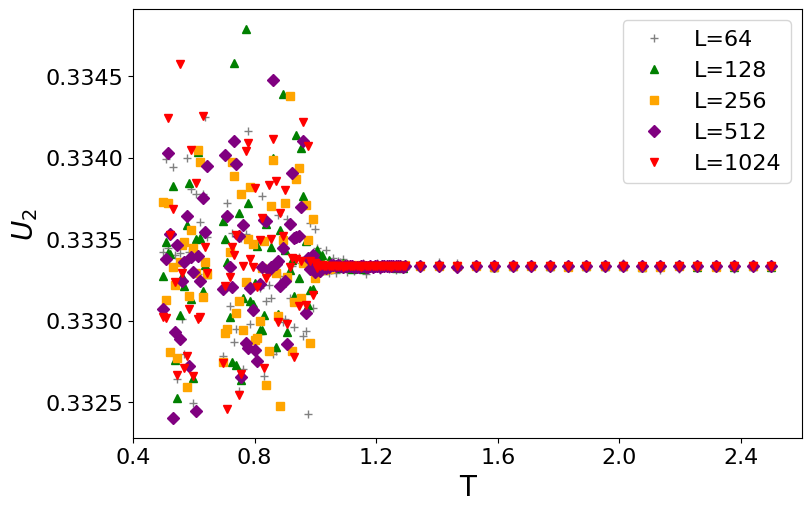

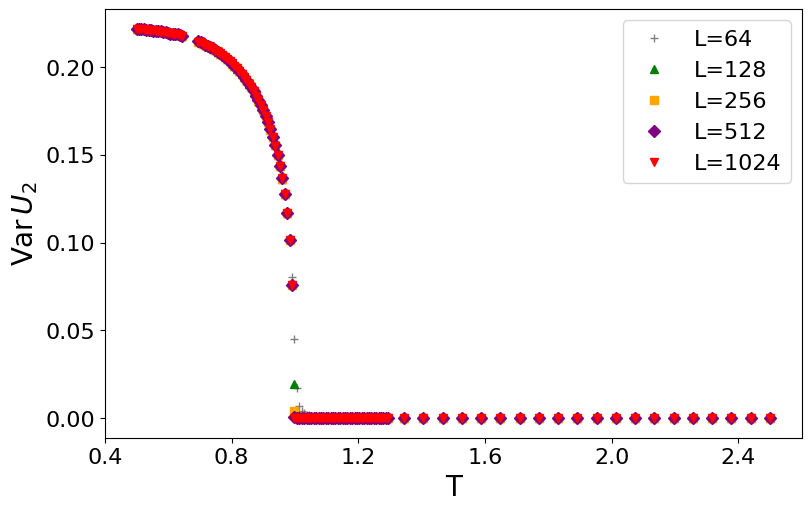

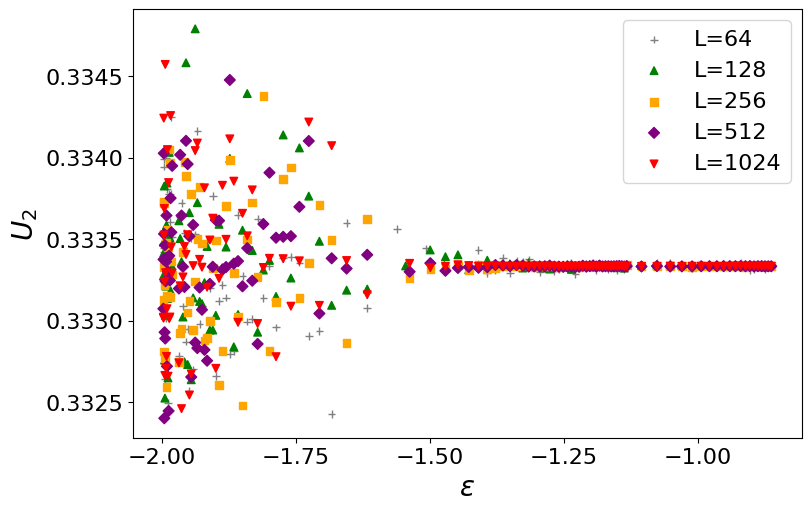

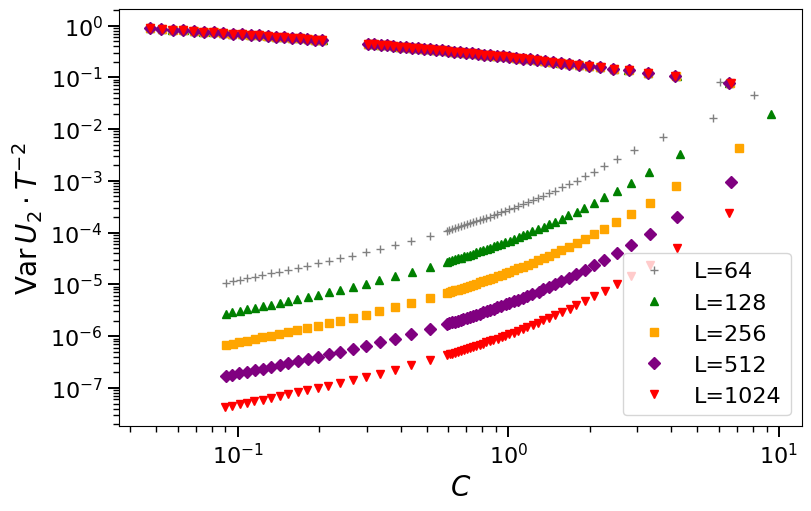

In [15]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, LogFormatterMathtext, NullFormatter

# ---- global font sizes ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# ===============================
# Load ALL Swendsen–Wang Potts3 results
# ===============================
base = "/Users/ianpile/Downloads/results_sw_potts3"
pattern = os.path.join(base, "L*", "swendsen_potts3_L*.csv")

files = glob.glob(pattern)
print(f"Found {len(files)} SW files")

dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(["L", "T"])
Ls = sorted(df["L"].unique())
print("L values:", Ls)

prefix = "sw_potts_"


# ============================================================
# 1. Overlap vs T
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    ax.plot(sub["T"],
            sub["mean_two_step_overlap"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}", linestyle = '')

ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "overlap_vs_T.png", dpi=300)
plt.show()


# ============================================================
# 2. Variance(overlap) vs T
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    ax.plot(sub["T"],
            sub["var_two_step_overlap"],
            color=style["color"],
            marker=style["marker"],
            label=f"L={L}", linestyle = '')

ax.set_xlabel("T", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "var_overlap_vs_T.png", dpi=300)
plt.show()


# ============================================================
# 3. Overlap vs Energy per spin
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    ax.scatter(sub["mean_energy_per_spin"],
               sub["mean_two_step_overlap"],
               s=30,
               color=style["color"],
               marker=style["marker"],
               label=f"L={L}", linestyle = '')

ax.set_xlabel(r"$\epsilon$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$U_2$", fontsize=LABEL_FONTSIZE)

ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "overlap_vs_energy.png", dpi=300)
plt.show()


# ============================================================
# 4. Var(overlap)*T^{-2} vs Heat Capacity (log-log)
# ============================================================
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L]
    y = sub["var_two_step_overlap"] * (sub["T"]**(-2))

    ax.loglog(sub["Cv_per_spin"],
              y,
              color=style["color"],
              marker=style["marker"],
              label=f"L={L}", linestyle = '')

ax.set_xlabel(r"$C$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r"$\mathrm{Var}\, U_2 \cdot T^{-2}$", fontsize=LABEL_FONTSIZE)

# Clean log ticks
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(axis="both", which="major",
               labelsize=TICK_FONTSIZE,
               length=8, width=1.4)

ax.tick_params(axis="both", which="minor",
               length=4, width=1.0)

ax.grid(False)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "var_overlap_vs_Cv_loglog.png", dpi=300)
plt.show()

In [80]:
Tc = 1.0 / np.log(1 + np.sqrt(3))

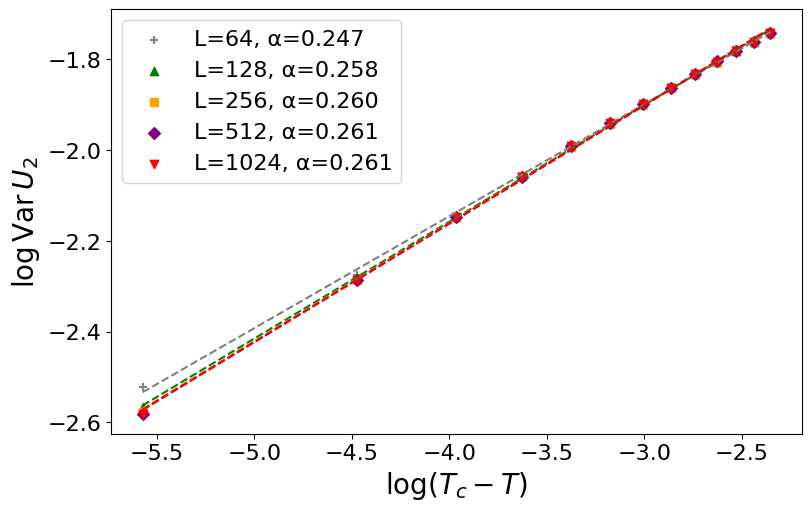

In [48]:
# ===================== ЛОГ-ЛОГ ФИТ =====================
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)

for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L].copy()

    fit = sub[(sub["T"] < Tc) & (sub["T"] > Tc - delta)].copy()
    fit = fit[fit["var_two_step_overlap"] > 0]

    if len(fit) > 3:
        x = np.log(Tc - fit["T"].values)
        y = np.log(fit["var_two_step_overlap"].values)

        coeffs = np.polyfit(x, y, 1)
        alpha = coeffs[0]

        # --- точки ---
        ax2.scatter(x, y,
                    color=style["color"],
                    marker=style["marker"],
                    label=f"L={L}, α={alpha:.3f}")

        # --- линия фита ---
        x_fit = np.linspace(min(x), max(x), 100)
        y_fit = np.polyval(coeffs, x_fit)

        ax2.plot(x_fit, y_fit,
                 color=style["color"],
                 linestyle="--")

# ===================== ОФОРМЛЕНИЕ =====================
ax2.set_xlabel(r"$\log(T_c - T)$", fontsize=LABEL_FONTSIZE)
ax2.set_ylabel(r"$\log \mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax2.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax2.grid(False)
ax2.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "loglog_fit_var_overlap.png", dpi=300)
plt.show()

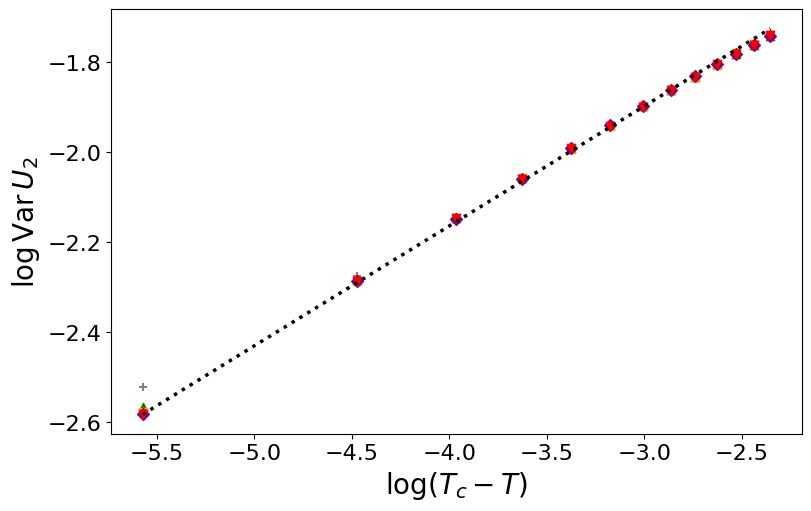

In [82]:
# ===================== ЛОГ-ЛОГ ФИТ =====================
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)

delta = 0.1
data_by_L = {}

# ===================== СБОР ДАННЫХ =====================
for L in Ls:
    style = get_style(L)
    sub = df[df["L"] == L].copy()

    fit = sub[(sub["T"] < Tc) & (sub["T"] > Tc - delta)].copy()
    fit = fit[fit["var_two_step_overlap"] > 0]

    if len(fit) > 3:
        x = np.log(Tc - fit["T"].values)
        y = np.log(fit["var_two_step_overlap"].values)

        # сортировка
        idx = np.argsort(x)
        x, y = x[idx], y[idx]

        data_by_L[L] = (x, y)

        # --- фит для каждого L ---
        coeffs = np.polyfit(x, y, 1)
        alpha = coeffs[0]

        ax2.scatter(x, y,
                    color=style["color"],
                    marker=style["marker"],
                    label=f"L={L}, α={alpha:.3f}")

        x_fit = np.linspace(min(x), max(x), 100)
        y_fit = np.polyval(coeffs, x_fit)

#         ax2.plot(x_fit, y_fit,
#                  color=style["color"],
#                  linestyle="--")

# ===================== ЭКСТРАПОЛЯЦИЯ L → ∞ =====================
from scipy.optimize import curve_fit

def lin_invL(L, y_inf, a):
    return y_inf + a / L

# общий диапазон x (пересечение)
x_min = max([min(v[0]) for v in data_by_L.values()])
x_max = min([max(v[0]) for v in data_by_L.values()])
common_x = np.linspace(x_min, x_max, 100)

Ls_sorted = np.array(sorted(data_by_L.keys()))
y_inf_vals = []

# ===================== ПОТОЧЕЧНАЯ ЭКСТРАПОЛЯЦИЯ =====================
for x0 in common_x:
    y_vs_L = []

    for L in Ls_sorted:
        x, y = data_by_L[L]

        if x0 >= x[0] and x0 <= x[-1]:
            y_interp = np.interp(x0, x, y)
            y_vs_L.append(y_interp)
        else:
            y_vs_L.append(np.nan)

    y_vs_L = np.array(y_vs_L)

    mask = ~np.isnan(y_vs_L)
    L_fit = Ls_sorted[mask]
    y_fit = y_vs_L[mask]

    if len(L_fit) >= 3:
        try:
            popt, _ = curve_fit(lin_invL, L_fit, y_fit)
            y_inf = popt[0]

            if not np.isfinite(y_inf) or abs(y_inf) > 5:
                raise RuntimeError

        except:
            y_inf = y_fit[-1]
    else:
        y_inf = np.nan

    y_inf_vals.append(y_inf)

y_inf_vals = np.array(y_inf_vals)

# ===================== ФИТ α В ПРЕДЕЛЕ L → ∞ =====================
mask = np.isfinite(y_inf_vals)

x_fit_inf = common_x[mask]
y_fit_inf = y_inf_vals[mask]

# линейный фит
coeffs_inf = np.polyfit(x_fit_inf, y_fit_inf, 1)
alpha_inf = coeffs_inf[0]

# линия фита
x_line = np.linspace(min(x_fit_inf), max(x_fit_inf), 200)
y_line = np.polyval(coeffs_inf, x_line)

# ===================== РИСУЕМ =====================
# кривая L → ∞
# ax2.plot(common_x, y_inf_vals,
#          color="black",
#          linewidth=3,
#          label=r"$L \to \infty$")

# линия α∞
ax2.plot(x_line, y_line,
         color="black",
         linestyle=":",
         linewidth=2.5,
         label=rf"$\alpha_{{\infty}} = {alpha_inf:.4f}$")

# ===================== ОФОРМЛЕНИЕ =====================
ax2.set_xlabel(r"$\log(T_c - T)$", fontsize=LABEL_FONTSIZE)
ax2.set_ylabel(r"$\log \mathrm{Var}\, U_2$", fontsize=LABEL_FONTSIZE)

ax2.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax2.grid(False)
# ax2.legend(fontsize=LEGEND_FONTSIZE)

plt.savefig(prefix + "loglog_fit_var_overlap.png", dpi=300)
plt.show()

# Var at T_c Potts SW

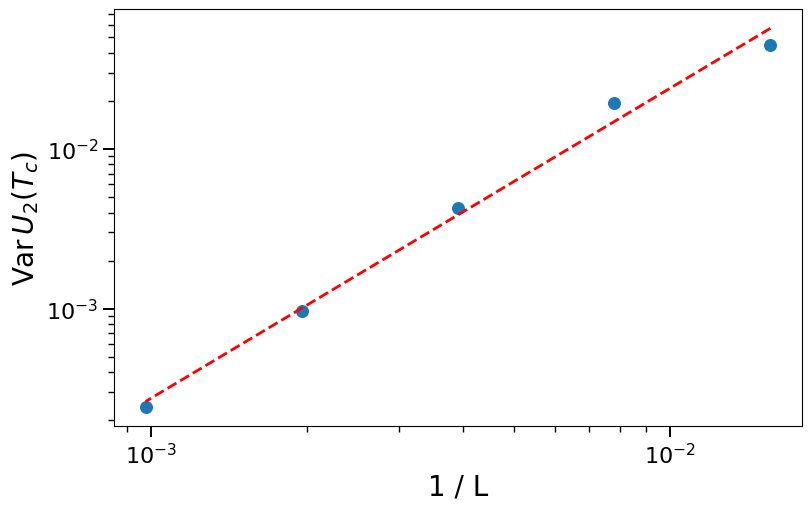


Log–log linear fit:
a = 183
b = 1.9412 ± 0.1009


In [107]:
prefix = "sw_potts_"  # change if needed

Tc = 1.0 / np.log(1 + np.sqrt(3))
plot_finite_size_scaling_var(df, Tc, prefix = prefix)

In [16]:
df.to_csv('potts_swendsen_wang.csv', index = False)

# Wolff Ising

In [246]:
import pandas as pd
big = pd.read_csv('/Users/ianpile/Downloads/combined_results_all.csv')
big = big.convert_dtypes()
# big.dtypes

In [247]:
import matplotlib.pyplot as plt

def plot_overlap_vs_T_for_Ls(df, Tc, ax=None, title="Overlap vs T for different L"):
    """
    Plot Overlap vs T for each lattice size L on the same axes.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: 'L', 'T', 'Overlap'
    Tc : float
        Critical temperature. A vertical red line will be drawn at this value.
    ax : matplotlib.axes.Axes, optional
        If provided, will plot on this axis. Otherwise creates a new figure.
    title : str
        Plot title.
    """
    # If no axis provided, make one
    if ax is None:
        fig, ax = plt.subplots()

    # Define some cycling styles
    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    # matplotlib will cycle through colors automatically, but we'll grab from current prop cycle
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # Make sure Ls are in a stable order
    unique_Ls = sorted(df["L"].unique())

    for i, L in enumerate(unique_Ls):
        style = get_style(L)
        sub = df[df["L"] == L].sort_values("T")
        color = color_cycle[i % len(color_cycle)]
        marker = markers[i % len(markers)]
        ax.plot(
            sub["T"],
            sub["mean_overlap_fraction"],
            label=f"L = {L}",
            color=style["color"],
            marker=style["marker"],
            linestyle="",
#             color=color,
            linewidth=1.5,
            markersize=6,
        )

    # Vertical line at Tc
    ax.axvline(Tc, color="red", linestyle="--", linewidth=1.5,
#                label=f"Tc = {Tc}"
              )

    ax.set_xlabel("T", fontsize = 16)
    ax.set_ylabel(r"$\epsilon$", fontsize = 16)
#     ax.set_title(title)
    ax.grid(False)
    # Tick labels (16 pt)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    ax.legend(fontsize = 16)
    plt.savefig("ising_wolff_normvar_vs_T.png", dpi=300,  bbox_inches="tight",
            pad_inches=0.05)
#     , dpi=300,
#             bbox_inches="tight",
#             pad_inches=0.05
    plt.tight_layout()


In [248]:
prefix

'sw_potts_'

In [249]:
big

,std_energy,level_folder,std_cluster_size,mean_cluster_size,L,std_overlap_fraction,std_overlap_jaccard,beta,T,source_file,n_measurements,mean_overlap_fraction,mean_energy,mean_overlap_jaccard,dataset
0,0.000149,L1024,27514.377208,1047093.494565,1024,0.037082,0.037096,1.0,1.0,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.997535,-1.99716,0.997897,combined_results
1,0.000212,L1024,39579.922378,1045548.966757,1024,0.053286,0.053325,0.916573,1.09102,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.99496,-1.994334,0.995686,combined_results
2,0.000287,L1024,53550.605688,1043032.1185,1024,0.072005,0.072101,0.845995,1.18204,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.990771,-1.989756,0.992095,combined_results
3,0.000375,L1024,69941.911146,1039125.280576,1024,0.093774,0.093988,0.785509,1.27306,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.984287,-1.982846,0.986524,combined_results
4,0.000476,L1024,88910.651377,1033328.023542,1024,0.118827,0.119261,0.733095,1.36408,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.974659,-1.972961,0.978218,combined_results
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,0.027591,L64,7.79562,6.550262,64,0.000076,0.01613,0.291481,3.43075,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000003,-0.678766,0.000735,cluster_overlap
1535,0.026954,L64,6.653855,5.742434,64,0.000063,0.015656,0.279872,3.57306,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000002,-0.642248,0.00067,cluster_overlap
1536,0.026724,L64,5.794796,5.127679,64,0.000053,0.015129,0.269152,3.71537,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000002,-0.609928,0.000613,cluster_overlap
1537,0.025482,L64,5.133503,4.666511,64,0.000043,0.014439,0.259222,3.85769,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000002,-0.583783,0.000549,cluster_overlap


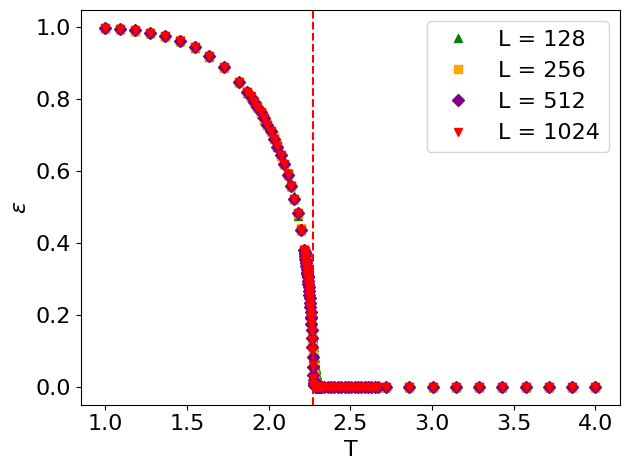

In [198]:
import pandas as pd

# df = pd.read_csv("/Users/ianpile/Downloads/combined_results_all.csv")  # adjust if needed
Tc = 2.269185314  # example
plot_overlap_vs_T_for_Ls(big[big.L.isin([128,256,512,1024])], Tc)
plt.show()

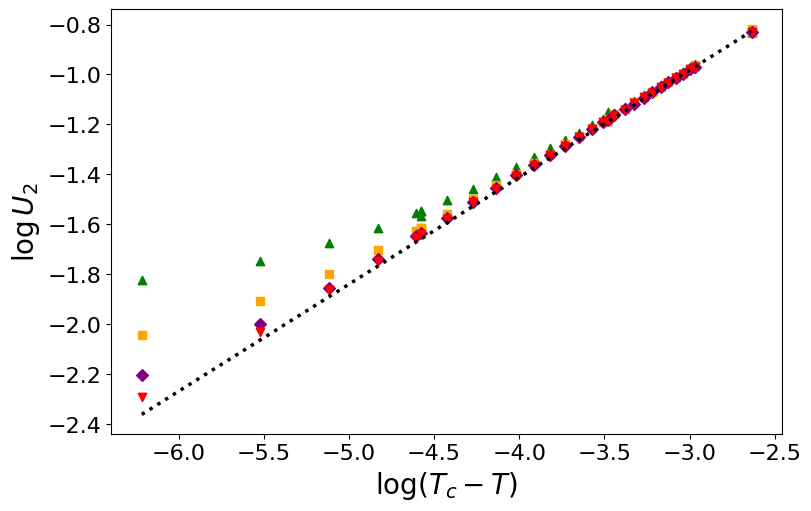

0.4284508538611723

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===================== ЛОГ-ЛОГ АНАЛИЗ ДЛЯ WOLFF =====================
def plot_loglog_wolff(df, Tc, prefix="ising_", delta = 0.08):

    fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

    data_by_L = {}

    # ===================== СБОР ДАННЫХ =====================
    for L in sorted(df["L"].unique()):
        style = get_style(L)
        sub = df[df["L"] == L].copy()

        # берём область около Tc
        fit = sub[(sub["T"] < Tc) & (sub["T"] > Tc - delta)].copy()
        fit = fit[fit["mean_overlap_fraction"] > 0]

        if len(fit) > 3:
            x = np.log(Tc - fit["T"].values)
            y = np.log(fit["mean_overlap_fraction"].values)

            # сортировка
            idx = np.argsort(x)
            x, y = x[idx], y[idx]

            data_by_L[L] = (x, y)

            # --- фит для каждого L ---
            coeffs = np.polyfit(x, y, 1)
            alpha = coeffs[0]

            ax.scatter(x, y,
                       color=style["color"],
                       marker=style["marker"],
                       label=f"L={L}, α={alpha:.3f}")

            x_fit = np.linspace(min(x), max(x), 100)
            y_fit = np.polyval(coeffs, x_fit)

#             ax.plot(x_fit, y_fit,
#                     color=style["color"],
#                     linestyle="--")

    # ===================== ЭКСТРАПОЛЯЦИЯ L → ∞ =====================
    def lin_invL(L, y_inf, a):
        return y_inf + a / L

    # пересечение диапазонов
    x_min = max([min(v[0]) for v in data_by_L.values()])
    x_max = min([max(v[0]) for v in data_by_L.values()])
    common_x = np.linspace(x_min, x_max, 100)

    Ls_sorted = np.array(sorted(data_by_L.keys()))
    y_inf_vals = []

    for x0 in common_x:
        y_vs_L = []

        for L in Ls_sorted:
            x, y = data_by_L[L]

            if x0 >= x[0] and x0 <= x[-1]:
                y_interp = np.interp(x0, x, y)
                y_vs_L.append(y_interp)
            else:
                y_vs_L.append(np.nan)

        y_vs_L = np.array(y_vs_L)

        mask = ~np.isnan(y_vs_L)
        L_fit = Ls_sorted[mask]
        y_fit = y_vs_L[mask]

        if len(L_fit) >= 3:
            try:
                popt, _ = curve_fit(lin_invL, L_fit, y_fit)
                y_inf = popt[0]

                if not np.isfinite(y_inf) or abs(y_inf) > 5:
                    raise RuntimeError

            except:
                y_inf = y_fit[-1]
        else:
            y_inf = np.nan

        y_inf_vals.append(y_inf)

    y_inf_vals = np.array(y_inf_vals)

    # ===================== ФИТ α∞ =====================
    mask = np.isfinite(y_inf_vals)

    x_fit_inf = common_x[mask]
    y_fit_inf = y_inf_vals[mask]

    coeffs_inf = np.polyfit(x_fit_inf, y_fit_inf, 1)
    alpha_inf = coeffs_inf[0]

    x_line = np.linspace(min(x_fit_inf), max(x_fit_inf), 200)
    y_line = np.polyval(coeffs_inf, x_line)

    # ===================== РИСУЕМ =====================
#     ax.plot(common_x, y_inf_vals,
#             color="black",
#             linewidth=3,
#             label=r"$L \to \infty$")

    ax.plot(x_line, y_line,
            color="black",
            linestyle=":",
            linewidth=2.5,
            label=rf"$\alpha_{{\infty}} = {alpha_inf:.4f}$")

    ax.set_xlabel(r"$\log(T_c - T)$", fontsize=20)
    ax.set_ylabel(r"$\log U_2$", fontsize=20)
    ax.grid(False)
#     ax.legend(fontsize=16)
    # Axis labels (20 pt)


    # Tick labels (16 pt)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.savefig(prefix + "loglog_wolff.png", dpi=300)
    plt.show()

    return alpha_inf

plot_loglog_wolff(big[big.L.isin([128,256,512,1024])], Tc)

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def plot_finite_size_scaling(df, Tc, T_tol=0.001, N_samples=1_000_000, weighted_fit=True):
    """
    Finite-size scaling: Overlap(Tc) vs 1/L with uncertainties.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain: 'L', 'T', 'mean_overlap_fraction', 'std_overlap_fraction'
    Tc : float
        Critical temperature.
    T_tol : float
        Tolerance around Tc for averaging Overlap values (default ±0.001).
    N_samples : int
        Number of statistically independent samples per temperature.
    weighted_fit : bool
        If True, use 1/σ² weighting in the fit.
    """

    Ls, overlaps, errors = [], [], []

    # Collect mean and SEM for each L around Tc
    for L in sorted(df["L"].unique()):
        sub = df[df["L"] == L]
        near_Tc = sub[np.abs(sub["T"] - Tc) < T_tol]
        if len(near_Tc) == 0:
            continue

        mean_overlap = near_Tc["mean_overlap_fraction"].mean()
        std_overlap = near_Tc["std_overlap_fraction"].mean()

        # Standard error of the mean
        sem = std_overlap / np.sqrt(N_samples)

        Ls.append(L)
        overlaps.append(mean_overlap)
        errors.append(sem)

    Ls = np.array(Ls, dtype=float)
    overlaps = np.array(overlaps, dtype=float)
    errors = np.array(errors, dtype=float)
    invL = 1.0 / Ls

    # Define power-law scaling: O(L) = a * L^(-b)
    def power_law(L, a, b):
        return a * L**(-b)

    # Fit with weights if available
    if weighted_fit:
        popt, pcov = curve_fit(power_law, Ls, overlaps, sigma=errors, absolute_sigma=True, p0=[1, 1])
    else:
        popt, pcov = curve_fit(power_law, Ls, overlaps, p0=[1, 1])

    a_fit, b_fit = popt
    perr = np.sqrt(np.diag(pcov))
    a_err, b_err = perr

    # Extrapolation curve (in L-space)
    L_fit = np.linspace(Ls.min(), Ls.max(), 200)
    y_fit = power_law(L_fit, a_fit, b_fit)

    # Plot
    # Plot
    plt.figure(figsize=(8, 5))  # 8×5 layout

    plt.loglog(1/L_fit, y_fit, 'r--',
               label=f'$Fit: ⟨U_2⟩ ∝ L^(-{b_fit:.2f})$')

    plt.errorbar(1/Ls, overlaps, yerr=errors,
                 fmt='o', color='blue', capsize=3,
                 label='Data')

    # Axis labels (20 pt)
    plt.xlabel('1 / L', fontsize=20)
    plt.ylabel(r'$U_2$', fontsize=20)

    # Tick labels (16 pt)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Legend (16 pt)
#     plt.legend(fontsize=16)

    # No grid
    plt.grid(False)

    # Clean margins
    plt.tight_layout()

    # Save at DPI 300
    plt.savefig('ising_wolff_FSS_overlap_loglog.png', dpi=300)
    print(Ls)
    print(f"Fit results:")
    print(f" a = {a_fit:.4g} ± {a_err:.2g}")
    print(f" b = {b_fit:.4f} ± {b_err:.4f}")


[  64.  128.  192.  256.  384.  512.  768. 1024. 1536.]
Fit results:
 a = 1.165 ± 0.0038
 b = 0.4240 ± 0.0006


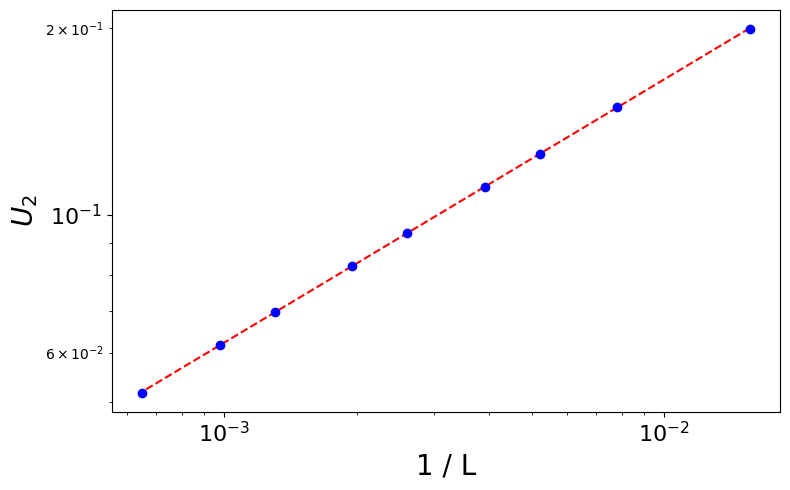

In [127]:
plot_finite_size_scaling(
    big,
    Tc=2.2691853,
    T_tol=0.001,
    N_samples=1_000_000,
    weighted_fit=True
)

In [125]:
big.L.unique()

<IntegerArray>
[1024, 1536, 192, 384, 48, 512, 768, 96, 128, 256, 64, 16, 32]
Length: 13, dtype: Int64

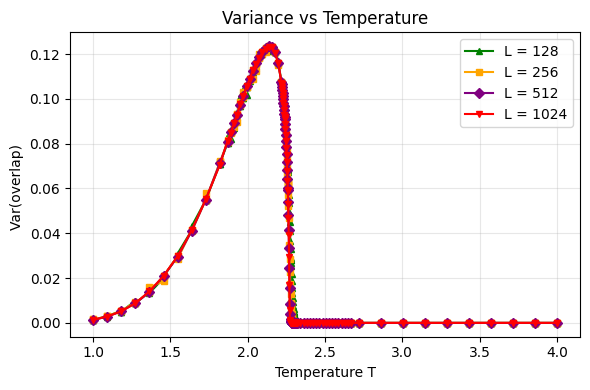

In [100]:
import matplotlib.pyplot as plt
import numpy as np

def plot_by_L(df, xcol, ycol, xlabel="", ylabel="", title="", loglog=False):
    """
    Plot ycol vs xcol for each L (no saving, just show).
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L)
        sub = df[df["L"] == L].sort_values(xcol)
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        ax.plot(
            sub[xcol], sub[ycol],
            color=style["color"],
            marker=style["marker"], linestyle="-",
            label=f"L = {L}", linewidth=1.5, markersize=5
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if loglog:
        ax.set_xscale("log")
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()


# ==========================================================
# (5) Normalized variance vs Temperature (per L)
# ==========================================================

# Compute normalized variance
big["var"] = (big["std_overlap_fraction"] ** 2) 

plot_by_L(
    big[big.L.isin([128,256,512,1024])],
    xcol="T",
    ycol="var",
    xlabel="Temperature T",
    ylabel="Var(overlap) ",
    title="Variance vs Temperature",
    loglog=False
)


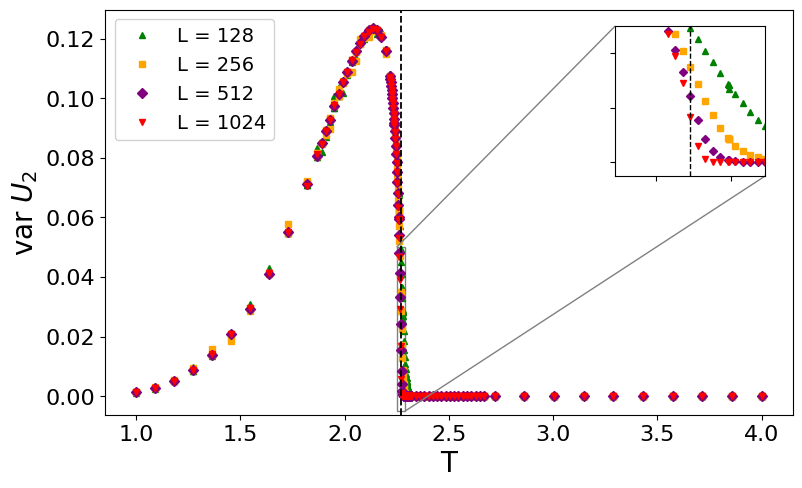

In [199]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

def plot_normvar_vs_T_with_inset(
    df,
    Tc,
    xcol="T",
    ycol="var_overlap",
    L_values=None,
    title="Variance vs Temperature (with zoom)",
    xlabel="T",
    ylabel=r"var $U_2$",
    window=0.1,
    inset_width_inch=1.6,
    inset_height_inch=1.0,
    inset_ylim=None,
    corner_offset=0.03,
    show_connectors=True
):

    if L_values is not None:
        df = df[df["L"].isin(L_values)].copy()

    if xcol not in df.columns or ycol not in df.columns or "L" not in df.columns:
        raise ValueError("df must have columns: 'L', xcol, and ycol")

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---- Main plot ----
    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L, i)
        sub = df[df["L"] == L].sort_values(xcol)
        if sub.empty:
            continue

        ax.plot(
            sub[xcol],
            sub[ycol],
            color=style["color"],
            marker=style["marker"],
            linestyle="",
            linewidth=1.5,
            markersize=5,
            label=f"L = {L}",
        )

    ax.axvline(Tc, color="black", linestyle="--", linewidth=1.3)

    ax.set_xlabel(xlabel or xcol, fontsize=20)
    ax.set_ylabel(ylabel or ycol, fontsize=20)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(False)

    legend = ax.legend(
        loc="upper left",
        fontsize=14,
        frameon=True,
        framealpha=0.9
    )
    legend.set_zorder(10)

    fig.canvas.draw_idle()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # ---- Inset ----
    axins = inset_axes(
        ax,
        width=float(inset_width_inch),
        height=float(inset_height_inch),
        loc="upper right",
        bbox_to_anchor=(1 - corner_offset, 1 - corner_offset),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    x1, x2 = Tc - window, Tc + window

    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L, i)
        sub = df[(df["L"] == L) & (df[xcol] >= x1) & (df[xcol] <= x2)].sort_values(xcol)
        if sub.empty:
            continue

        axins.plot(
            sub[xcol],
            sub[ycol],
            color=style["color"],
            marker=style["marker"],
            linestyle="",
            linewidth=1.2,
            markersize=4,
        )

    axins.axvline(Tc, color="black", linestyle="--", linewidth=1.0)
    axins.set_xlim(x1, x2)

    if inset_ylim is not None:
        axins.set_ylim(*inset_ylim)
    elif len(axins.lines):
        yy = np.concatenate([l.get_ydata() for l in axins.lines if len(l.get_ydata())])
        if yy.size:
            ypad = 0.05 * (np.nanmax(yy) - np.nanmin(yy) + 1e-12)
            axins.set_ylim(np.nanmin(yy) - ypad, np.nanmax(yy) + ypad)

    axins.grid(False)
    axins.set_xticklabels([])
    axins.set_yticklabels([])

    if show_connectors:
        y1c, y2c = axins.get_ylim()
        if (x1 >= xlim[0]) and (x2 <= xlim[1]) and (y1c >= ylim[0]) and (y2c <= ylim[1]):
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)
    fig.savefig("ising_wolff_normvar_vs_T.png", dpi=300, bbox_inches="tight")

    plt.show()
    
# Ensure normvar is computed:
big["var_overlap"] = (big["std_overlap_fraction"]**2)
# / big["mean_overlap_fraction"]

plot_normvar_vs_T_with_inset(
    big,
    Tc=round(Tc, 4),
    xcol="T",
    ycol="var_overlap",
    L_values=[128, 256, 512, 1024],
    title="Variance vs Temperature",
    window=0.02,                 # zoom half-width
    inset_width_inch=1.5,        # rectangular inset
    inset_height_inch=1.5,
    inset_ylim=(-0.005, 0.05),        # <--- custom inset y-limits
    corner_offset=0.04,
    show_connectors=True
)


In [102]:
big

,std_energy,level_folder,std_cluster_size,mean_cluster_size,L,std_overlap_fraction,std_overlap_jaccard,beta,T,source_file,n_measurements,mean_overlap_fraction,mean_energy,mean_overlap_jaccard,dataset,var,var_overlap
0,0.000149,L1024,27514.377208,1047093.494565,1024,0.037082,0.037096,1.0,1.0,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.997535,-1.99716,0.997897,combined_results,0.001375,0.001375
1,0.000212,L1024,39579.922378,1045548.966757,1024,0.053286,0.053325,0.916573,1.09102,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.99496,-1.994334,0.995686,combined_results,0.002839,0.002839
2,0.000287,L1024,53550.605688,1043032.1185,1024,0.072005,0.072101,0.845995,1.18204,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.990771,-1.989756,0.992095,combined_results,0.005185,0.005185
3,0.000375,L1024,69941.911146,1039125.280576,1024,0.093774,0.093988,0.785509,1.27306,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.984287,-1.982846,0.986524,combined_results,0.008794,0.008794
4,0.000476,L1024,88910.651377,1033328.023542,1024,0.118827,0.119261,0.733095,1.36408,/Users/ianpile/Downloads/results/L1024/results...,1000000,0.974659,-1.972961,0.978218,combined_results,0.01412,0.01412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,0.027591,L64,7.79562,6.550262,64,0.000076,0.01613,0.291481,3.43075,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000003,-0.678766,0.000735,cluster_overlap,0.0,0.0
1535,0.026954,L64,6.653855,5.742434,64,0.000063,0.015656,0.279872,3.57306,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000002,-0.642248,0.00067,cluster_overlap,0.0,0.0
1536,0.026724,L64,5.794796,5.127679,64,0.000053,0.015129,0.269152,3.71537,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000002,-0.609928,0.000613,cluster_overlap,0.0,0.0
1537,0.025482,L64,5.133503,4.666511,64,0.000043,0.014439,0.259222,3.85769,/Users/ianpile/Downloads/ising_cluster_overlap...,1000000,0.000002,-0.583783,0.000549,cluster_overlap,0.0,0.0


In [148]:
plot_normvar_vs_T_with_inset(
    big,
    Tc=round(Tc, 4),
    xcol="T",
    ycol="epsilon",
    L_values=[128, 256, 512, 1024],
    title="Variance vs Temperature",
    window=0.02,                 # zoom half-width
    inset_width_inch=1.5,        # rectangular inset
    inset_height_inch=1.5,
    inset_ylim=(-0.005, 0.05),        # <--- custom inset y-limits
    corner_offset=0.04,
    show_connectors=True
)


ValueError: df must have columns: 'L', xcol, and ycol

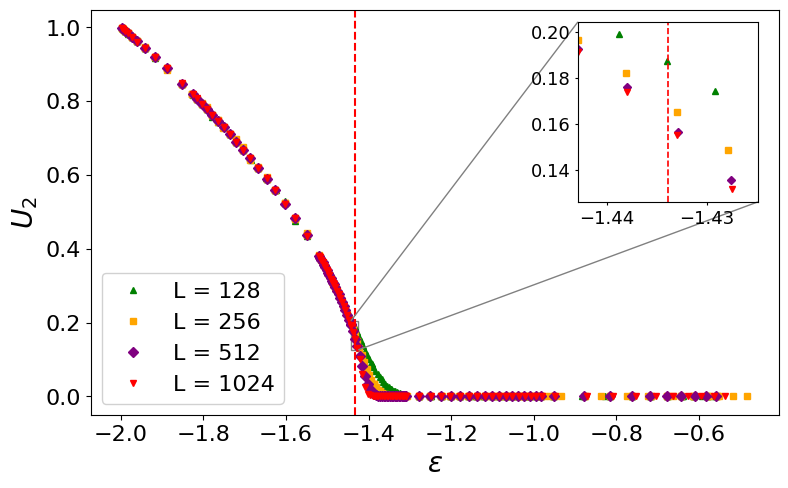

In [147]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

def plot_mean_overlap_vs_energy_with_inset(
    df,
    Ec,
    zoom_width=0.05,
    zoom_ylim=None,
    title="Mean overlap vs energy with zoom",
    inset_side_inch=1.8,
    corner_offset=0.03,
    label_fontsize=20,
    tick_fontsize=16,
    savepath="ising_wolff_overlap(E).png",
    dpi=300,
    inset_padding_frac=0.08
):

    if "energy" in df.columns:
        ecol = "energy"
    elif "mean_energy" in df.columns:
        ecol = "mean_energy"
    else:
        raise ValueError("DataFrame must have an 'energy' or 'mean_energy' column.")

    df = df.copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---------------- MAIN PLOT ----------------
    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L, i)
        sub = df[df["L"] == L].sort_values(ecol)
        if sub.empty:
            continue

        ax.plot(
            sub[ecol],
            sub["mean_overlap_fraction"],
            color=style["color"],
            marker=style["marker"],
            linestyle="",
            linewidth=1.5,
            markersize=5,
            label=f"L = {L}",
        )

    ax.axvline(Ec, color="red", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"$\epsilon$", fontsize=label_fontsize)
    ax.set_ylabel(r"$U_2$", fontsize=label_fontsize)

    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(False)

    legend = ax.legend(
        loc="lower left",
        fontsize=16,
        frameon=True,
        framealpha=0.9,
    )
    legend.set_zorder(10)

    # ---------------- INSET ----------------
    axins = inset_axes(
        ax,
        width=inset_side_inch,
        height=inset_side_inch,
        loc="upper right",
        bbox_to_anchor=(1 - corner_offset, 1 - corner_offset),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L, i)
        sub = df[df["L"] == L].sort_values(ecol)
        if sub.empty:
            continue

        axins.plot(
            sub[ecol],
            sub["mean_overlap_fraction"],
            color=style["color"],
            marker=style["marker"],
            linestyle="",
            linewidth=1.2,
            markersize=4,
        )

    axins.axvline(Ec, color="red", linestyle="--", linewidth=1.2)

    x1, x2 = Ec - zoom_width, Ec + zoom_width
    axins.set_xlim(x1, x2)

    if zoom_ylim is None:
        mask = (df[ecol] >= x1) & (df[ecol] <= x2)
        yvals = df.loc[mask, "mean_overlap_fraction"].to_numpy()
        yvals = yvals[np.isfinite(yvals)]

        if yvals.size >= 2:
            ymin, ymax = float(yvals.min()), float(yvals.max())
            span = max(1e-12, ymax - ymin)
            pad = inset_padding_frac * span
            axins.set_ylim(ymin - pad, ymax + pad)
        elif yvals.size == 1:
            y0 = float(yvals[0])
            axins.set_ylim(y0 - 0.05, y0 + 0.05)
        else:
            axins.set_ylim(ax.get_ylim())
    else:
        axins.set_ylim(*zoom_ylim)

    axins.grid(False)
    axins.tick_params(axis="both", labelsize=max(8, tick_fontsize - 3), length=2)

    fig.canvas.draw()
    y1, y2 = axins.get_ylim()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    if (x1 >= xlim[0]) and (x2 <= xlim[1]) and (y1 >= ylim[0]) and (y2 <= ylim[1]):
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)

    fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
    plt.show()
    
# пример вызова
plot_mean_overlap_vs_energy_with_inset(
    big[big.L.isin([128, 256, 512, 1024])],
    Ec=Ec,
    zoom_width=0.009,
    zoom_ylim=None,  # <-- рекомендую так, чтобы inset сам подобрал y-диапазон
    inset_side_inch=1.8,
    corner_offset=0.03,
    label_fontsize=20,
    savepath="ising_wolff_overlap(E).png",
)


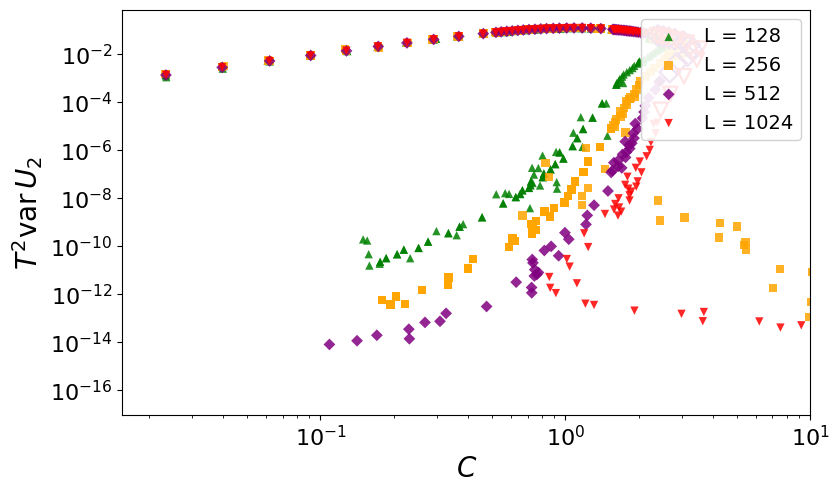

In [250]:
import numpy as np
import matplotlib.pyplot as plt

def plot_variance_vs_heat_capacity_by_L(
    df,
    Tc,
    L_values=None,
    window=0.1,
    loglog=True,
    point_size=40,
    critical_size=90,
    title="Variance vs Heat Capacity by L (critical region highlighted)"
):

    df = df.copy()

    if L_values is not None:
        df = df[df["L"].isin(L_values)]

    if "var_overlap" not in df.columns:
        if "std_overlap_fraction" not in df.columns:
            raise ValueError("df must contain 'std_overlap_fraction'.")
        df["var_overlap"] = df["std_overlap_fraction"]**2

    if "heat_capacity" not in df.columns:
        if not {"std_energy","T","L"}.issubset(df.columns):
            raise ValueError("Need 'std_energy','T','L' to compute heat_capacity.")
        df["var_energy"] = df["std_energy"]**2
        df["heat_capacity"] = (df["L"]**2) * df["var_energy"] / (df["T"]**2)

    crit_mask = (df["T"] >= Tc - window) & (df["T"] <= Tc + window)

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---------------- MAIN SCATTER ----------------
    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        sub = df[df["L"] == L]
        if sub.empty:
            continue

        # non-critical points
        sub_noncrit = sub[~crit_mask.loc[sub.index]]
        ax.scatter(
            sub_noncrit["heat_capacity"],
            sub_noncrit["var_overlap"],
            s=point_size,
            marker=marker,
            color=color,
            alpha=0.85,
            edgecolors="none",
            label=f"L = {L}"
        )

        # critical region (outlined in same L color)
        sub_crit = sub[crit_mask.loc[sub.index]]
        if not sub_crit.empty:
            ax.scatter(
                sub_crit["heat_capacity"],
                sub_crit["var_overlap"],
                s=critical_size,
                marker=marker,
                facecolors="none",
                edgecolors=color,
                linewidths=1.6,
                zorder=3,
            )

    if loglog:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlabel("$C$", fontsize=20)
    ax.set_ylabel(r"$T^2 \mathrm{var}\, U_2$", fontsize=20)

    ax.tick_params(axis="both", labelsize=16)
    ax.grid(False)
    ax.set_xlim(right = 10)

    legend = ax.legend(
        loc="upper right",
        fontsize=14,
        frameon=True,
        framealpha=0.9,
    )
    legend.set_zorder(10)

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)

    fig.savefig("variance_vs_heat_capacity.png", dpi=300, bbox_inches="tight")
    plt.show()
    
plot_variance_vs_heat_capacity_by_L(
    df=big,
    Tc=2.269185314,                 # your Ising Tc, or use your Potts Tc
    L_values=[128, 256, 512, 1024],
    window=0.01,                    # highlight |T - Tc| <= 0.12
    loglog=True,
    point_size=36,
    critical_size=110,
    title="Variance vs Heat Capacity (Ising) — critical region highlighted"
)


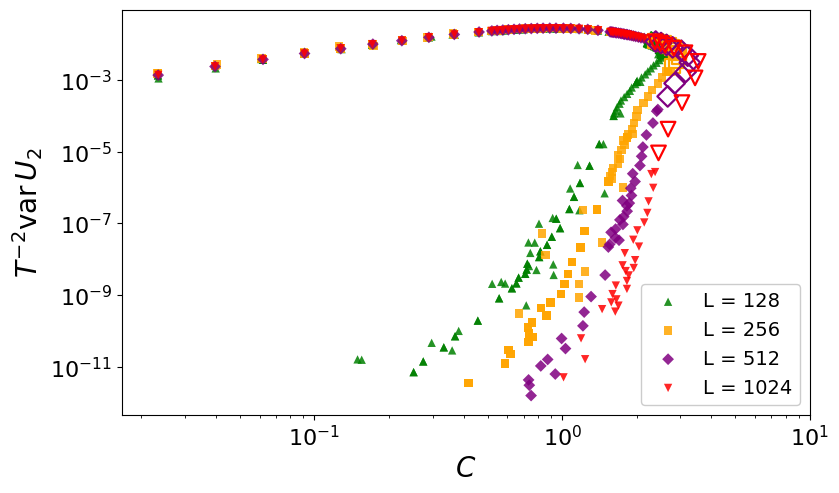

In [267]:
import numpy as np
import matplotlib.pyplot as plt

def plot_variance_vs_heat_capacity_by_L(
    df,
    Tc,
    L_values=None,
    window=0.1,
    loglog=True,
    point_size=40,
    critical_size=90,
    title="Variance vs Heat Capacity by L (critical region highlighted)",
    var_min=1e-12,              # <-- noise cutoff (adjust if needed)
    use_percentile_filter=True # <-- optional smarter filtering
):

    df = df.copy()

    if L_values is not None:
        df = df[df["L"].isin(L_values)]

    # ---------------- COMPUTE QUANTITIES ----------------
    if "var_overlap" not in df.columns:
        if "std_overlap_fraction" not in df.columns:
            raise ValueError("df must contain 'std_overlap_fraction'.")
        df["var_overlap"] = df["std_overlap_fraction"]**2/ df["T"]**2

    if "heat_capacity" not in df.columns:
        if not {"std_energy","T","L"}.issubset(df.columns):
            raise ValueError("Need 'std_energy','T','L' to compute heat_capacity.")
        df["var_energy"] = df["std_energy"]**2
        df["heat_capacity"] = (df["L"]**2) * df["var_energy"] / (df["T"]**2)

    # ---------------- REMOVE NOISE ----------------
    # Hard cutoff (removes extremely small noisy values)
    df = df[(df["var_overlap"] > var_min)]

    # Optional: remove bottom 5% per L (more robust)
    if use_percentile_filter:
        cleaned = []
        for L in df["L"].unique():
            sub = df[df["L"] == L]
            cutoff = np.percentile(sub["var_overlap"], 5)
            cleaned.append(sub[sub["var_overlap"] > cutoff])
        df = pd.concat(cleaned)

    # ---------------- CRITICAL MASK ----------------
    crit_mask = (df["T"] >= Tc - window) & (df["T"] <= Tc + window)

    fig, ax = plt.subplots(figsize=(8, 5))
    df["var_overlap"] = df["std_overlap_fraction"]**2/ df["T"]**2
    # ---------------- MAIN SCATTER ----------------
    for i, L in enumerate(sorted(df["L"].unique())):
        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        sub = df[df["L"] == L]
        if sub.empty:
            continue

        # non-critical points
        sub_noncrit = sub[~crit_mask.loc[sub.index]]
        ax.scatter(
            sub_noncrit["heat_capacity"],
            sub_noncrit["var_overlap"],
            s=point_size,
            marker=marker,
            color=color,
            alpha=0.85,
            edgecolors="none",
            label=f"L = {L}"
        )

        # critical region (outlined)
        sub_crit = sub[crit_mask.loc[sub.index]]
        if not sub_crit.empty:
            ax.scatter(
                sub_crit["heat_capacity"],
                sub_crit["var_overlap"],
                s=critical_size,
                marker=marker,
                facecolors="none",
                edgecolors=color,
                linewidths=1.6,
                zorder=3,
            )

    # ---------------- AXES ----------------
    if loglog:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlabel("$C$", fontsize=20)
    ax.set_ylabel(r"$T^{-2} \mathrm{var}\, U_2$", fontsize=20)

    ax.tick_params(axis="both", labelsize=16)
    ax.grid(False)
    ax.set_xlim(right=10)

    # ---------------- LEGEND (moved) ----------------
    legend = ax.legend(
        loc="lower right",   # <-- changed here
        fontsize=14,
        frameon=True,
        framealpha=1,
    )
    legend.set_zorder(10)

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)

    fig.savefig("variance_vs_heat_capacity_wolff_ising.png", dpi=300, bbox_inches="tight")
    plt.show()


# ---------------- RUN ----------------
plot_variance_vs_heat_capacity_by_L(
    df=big,
    Tc=2.269185314,
    L_values=[128, 256, 512, 1024],
    window=0.01,
    loglog=True,
    point_size=36,
    critical_size=110,
    var_min=1e-13,          # tune this if needed
    use_percentile_filter=True
)

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fig4_style_varO_left(
    df,
    Tc,
    L_values=None,           # e.g. [128,256,512,1024,1536]; None = use all
    window=0.10,             # critical region half-width for highlighting
    show_errors=True,        # draw error bars if n_measurements is present
    loglog_right=True,       # RHS panel on log–log axes
    point_size=36,
    critical_size=110,
    star_size=180,           # size for critical-point star markers
    legend_loc_left="best",
    legend_loc_right="best",
    title_left="(a) Var(Overlap) vs T",
    title_right="(b) Var(Overlap) × T⁻² vs C",
    save_path=None           # path to save PNG; None = just show
):
    """
    Two-panel figure (Fig.4-style):
      Left:  Var(Overlap) vs T   (clean; no critical-region highlighting, no stars)
      Right: Var(Overlap) * T^{-2} vs Heat Capacity (critical region highlighted; star at Tc point)

    Expects columns:
      - L, T
      - std_overlap_fraction (for Var(O))
      - std_energy (for Var(E) and C), or precomputed 'heat_capacity'
      - n_measurements (optional, for error bars)

    If heat_capacity is absent, it is computed as C = (N/T^2)*Var(E) with N=L^2.
    """
#     plt.rcParams["axes.grid"] = False
    data = df.copy()
    if L_values is not None:
        data = data[data["L"].isin(L_values)]

    # Var(Overlap)
    if "var_overlap" not in data.columns:
        if "std_overlap_fraction" not in data.columns:
            raise ValueError("Need 'std_overlap_fraction' to compute var_overlap.")
        data["var_overlap"] = data["std_overlap_fraction"]**2

    # Heat capacity (C = N/T^2 * Var(E)) if needed
    if "heat_capacity" not in data.columns:
        if "std_energy" not in data.columns:
            raise ValueError("Need 'std_energy' (or precomputed 'heat_capacity').")
        data["var_energy"] = data.get("var_energy", data["std_energy"]**2)
        data["heat_capacity"] = (data["L"]**2) * data["var_energy"] / (data["T"]**2)

    # Right-panel Y: Var(O)*T^{-2}
    data["var_overlap_T2"] = data["var_overlap"] / (data["T"]**2)

    # Critical region mask
    crit_mask = (data["T"] >= Tc - window) & (data["T"] <= Tc + window)

    # Error estimates (optional; shown if n_measurements present & show_errors=True)
    has_n = "n_measurements" in data.columns
    if has_n:
        Nmeas = data["n_measurements"].astype(float).replace(0, np.nan)
        # ΔVar ≈ Var * sqrt(2/(N-1))  (Gaussian assumption)
        data["varO_err"] = data["var_overlap"] * np.sqrt(2.0 / np.maximum(Nmeas - 1.0, 1.0))
        data["varO_T2_err"] = data["varO_err"] / (data["T"]**2)

    # Figure & axes
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # ---------- Left: Var(Overlap) vs T (no red region, no stars) ----------
    used_labels = set()
    for i, L in enumerate(sorted(data["L"].unique())):
        sub = data[data["L"] == L].sort_values("T")
        if sub.empty:
            continue
        label = f"L = {L}" if f"L = {L}" not in used_labels else None

        if show_errors and has_n:
            axL.errorbar(
                sub["T"], sub["var_overlap"],
                yerr=sub["varO_err"],
                fmt=markers[i % len(markers)] + "-", ms=5,
                elinewidth=1.2, capsize=3, alpha=0.85,
                label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                color=colors[i % len(colors)]
            )
        else:
            axL.plot(
                sub["T"], sub["var_overlap"],
                markers[i % len(markers)] + "-",
                ms=5, alpha=0.85,
                label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                color=colors[i % len(colors)]
            )
        used_labels.add(f"L = {L}")

    axL.axvline(Tc, color="gray", linestyle="--", linewidth=1.2)
    axL.set_xlabel("T", fontsize = fontsize)
    axL.set_ylabel(r"$Var\ U_2$", fontsize = fontsize)
#     axL.set_title(title_left)
    axL.grid(True, alpha=0.3)
    axL.legend(loc=legend_loc_left)

    # ---------- Right: Var(Overlap)*T^{-2} vs Heat Capacity ----------
    used_labels = set()
    for i, L in enumerate(sorted(data["L"].unique())):
        sub = data[data["L"] == L]
        if sub.empty:
            continue

        # non-critical points
        sub_nc = sub[~crit_mask.loc[sub.index]]
        if not sub_nc.empty:
            if show_errors and has_n:
                axR.errorbar(
                    sub_nc["heat_capacity"], sub_nc["var_overlap_T2"],
                    yerr=sub_nc["varO_T2_err"],
                    fmt=markers[i % len(markers)], ms=5,
                    elinewidth=1.2, capsize=3, alpha=0.85,
                    label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                    color=colors[i % len(colors)]
                )
            else:
                axR.scatter(
                    sub_nc["heat_capacity"], sub_nc["var_overlap_T2"],
                    s=point_size, alpha=0.85,
                    marker=markers[i % len(markers)],
                    color=colors[i % len(colors)],
                    label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                    edgecolors="none"
                )
            used_labels.add(f"L = {L}")

        # critical region (red hollow)
        sub_c = sub[crit_mask.loc[sub.index]]
        if not sub_c.empty:
            axR.scatter(
                sub_c["heat_capacity"], sub_c["var_overlap_T2"],
                s=critical_size, facecolors="none",
                edgecolors="red", linewidths=1.5, zorder=3
            )

        # star at point closest to Tc
        i_star = (sub["T"] - Tc).abs().idxmin()
        axR.scatter(
            sub.loc[i_star, "heat_capacity"], sub.loc[i_star, "var_overlap_T2"],
            marker="*", s=star_size, color="gold",
            edgecolors="black", linewidths=1.2, zorder=4
        )

    if loglog_right:
        axR.set_xscale("log")
        axR.set_yscale("log")

    axR.set_xlabel("C", fontsize = fontsize)
    axR.set_ylabel(r"$Var\ U_2 × T^{-2}$", fontsize = fontsize)
#     axR.set_title(title_right)
    axR.grid(True, alpha=0.3, which="both")

    # Legend only on the right panel
    crit_label = f"Critical region |T - Tc| ≤ {window}"
    star_proxy_R = axR.scatter([], [], marker="*", s=star_size, color="gold",
                               edgecolors="black", linewidths=1.2)
    crit_proxy_R = axR.scatter([], [], s=critical_size, facecolors="none",
                               edgecolors="red", linewidths=1.5)
    handles_R, labels_R = axR.get_legend_handles_labels()
    handles_R += [star_proxy_R, crit_proxy_R]
    labels_R  += ["Point nearest Tc", crit_label]
    axR.legend(handles_R, labels_R, loc=legend_loc_right)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"✓ Saved figure → {save_path}")
    else:
        plt.show()


In [102]:
plot_fig4_style_varO_left(
    df=big,
    Tc=2.269185314,                 # Ising Tc (or your Potts Tc)
    L_values=[128, 256, 512, 1024],
    window=0.01,
    show_errors=False,               # needs 'n_measurements'
    loglog_right=True,
    star_size=220,
    save_path='ising_wolff_var(O) vs C.png'                  # or "fig4_style_varO.png"
)


✓ Saved figure → ising_wolff_var(O) vs C.png


# Wolff Potts

In [240]:
big = pd.read_csv("/Users/ianpile/Downloads/combined_results_potts_wolff.csv")
big = big.convert_dtypes()

In [242]:
big['std_overlap_fraction']

Index(['std_overlap_fraction', 'n_measurements', 'mean_cluster_size',
       'mean_overlap_jaccard', 'std_energy', 'L', 'std_overlap_jaccard',
       'mean_energy', 'std_cluster_size', 'T', 'beta', 'mean_overlap_fraction',
       'level_folder', 'source_file'],
      dtype='object')

In [231]:
import matplotlib.pyplot as plt
import numpy as np

def plot_overlap_vs_T_for_Ls(df, Tc, ax=None, title="Overlap vs T for different L"):
    """
    Plot Overlap vs T for each lattice size L on the same axes.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: 'L', 'T', 'Overlap'
    Tc : float
        Critical temperature. A vertical red line will be drawn at this value.
    ax : matplotlib.axes.Axes, optional
        If provided, will plot on this axis. Otherwise creates a new figure.
    title : str
        Plot title.
    """
    # If no axis provided, make one
    if ax is None:
        fig, ax = plt.subplots()

    # Define some cycling styles
    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    # matplotlib will cycle through colors automatically, but we'll grab from current prop cycle
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # Make sure Ls are in a stable order
    unique_Ls = sorted(df["L"].unique())

    for i, L in enumerate(unique_Ls):
        sub = df[df["L"] == L].sort_values("T")
        color = color_cycle[i % len(color_cycle)]
        marker = markers[i % len(markers)]
        ax.plot(
            sub["T"],
            sub["mean_overlap_fraction"],
            label=f"L = {L}",
            marker=marker,
            linestyle="",
            color=color,
            linewidth=1.5,
            markersize=6,
        )

    # Vertical line at Tc
    ax.axvline(Tc, color="red", linestyle="--", linewidth=1.5, label=f"Tc = {Tc}")

    ax.set_xlabel("T")
    ax.set_ylabel(r"$U_2$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()


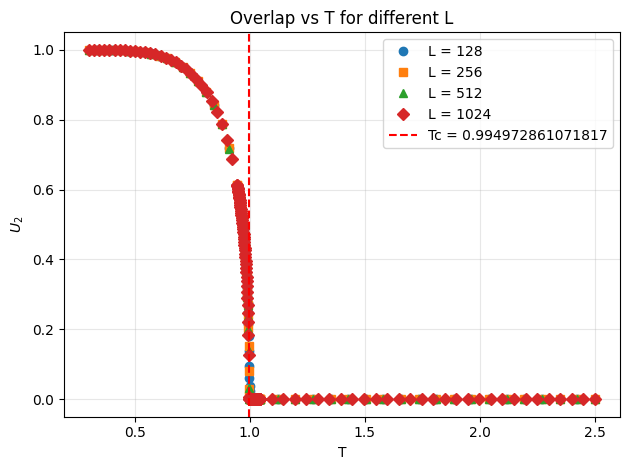

In [232]:
import pandas as pd

# df = pd.read_csv("/Users/ianpile/Downloads/combined_results_all.csv")  # adjust if needed

Tc=1/np.log(1+np.sqrt(3))
plot_overlap_vs_T_for_Ls(big[big.L.isin([128, 256, 512, 1024])], Tc)
plt.show()


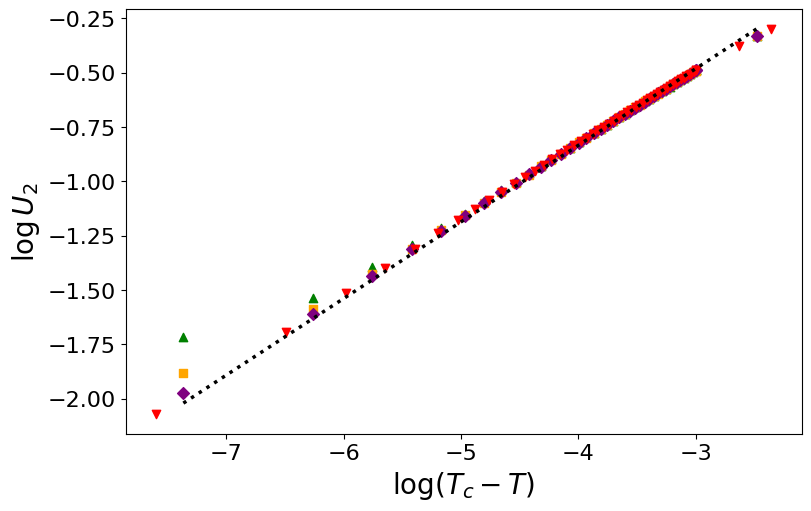

0.3525237955702436

In [233]:
plot_loglog_wolff(big[big.L.isin([128,256,512,1024])], Tc, prefix = 'potts_', delta = 0.1)

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def plot_finite_size_scaling(df, Tc, T_tol=0.001):
    """
    Finite-size scaling: Overlap(Tc) vs 1/L

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: 'L', 'T', 'Overlap'
    Tc : float
        Critical temperature
    T_tol : float
        Tolerance around Tc for averaging Overlap values (default ±0.02)
    """

    # Select points near Tc for each L
    Ls, overlaps = [], []
    for L in sorted(df["L"].unique()):
        sub = df[df["L"] == L]
        near_Tc = sub[np.abs(sub["T"] - Tc) < T_tol]
        if len(near_Tc) == 0:
            continue
        mean_overlap = near_Tc["mean_overlap_fraction"].mean()
        Ls.append(L)
        overlaps.append(mean_overlap)

    Ls = np.array(Ls, dtype=float)
    overlaps = np.array(overlaps, dtype=float)
    invL = 1.0 / Ls

    # Define power-law model: O(L) = a * L^(-b)
    def power_law(L, a, b):
        return a * L**(-b)

    popt, pcov = curve_fit(power_law, Ls, overlaps, p0=[1, 1])
    a_fit, b_fit = popt

    # Extrapolation (in 1/L space)
    x_fit = np.linspace(0, max(invL)*1.05, 200)
    y_fit = power_law(1/x_fit.clip(min=1e-6), a_fit, b_fit)

    # Plot
    plt.figure(figsize=(6, 4))
    plt.scatter(invL, overlaps, color='blue', marker='o', label='Data')
    plt.loglog(x_fit, y_fit, 'r--', label=f'Fit: $U_2(T_c)$ ∝ L^(-{b_fit:.2f})')
    plt.xlabel('1 / L', fontsize = fontsize)
    plt.ylabel(r'$U_2(T_c)$', fontsize = fontsize)
#     plt.title(r'Finite-Size Scaling: $U_2(T_c)$ vs 1/L')
#     plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('potts_wolff_FSS overlap loglog.png')
    plt.show()

    print(f"Fit parameters: a = {a_fit:.3g}, exponent b = {b_fit:.3f}")


In [235]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def plot_finite_size_scaling(df, Tc, T_tol=0.001, fontsize=14):

    # Select points near Tc for each L
    Ls, overlaps = [], []

    for L in sorted(df["L"].unique()):
        sub = df[df["L"] == L]
        near_Tc = sub[np.abs(sub["T"] - Tc) < T_tol]
        if len(near_Tc) == 0:
            continue

        mean_overlap = near_Tc["mean_overlap_fraction"].mean()
        Ls.append(L)
        overlaps.append(mean_overlap)

    Ls = np.array(Ls, dtype=float)
    overlaps = np.array(overlaps, dtype=float)

    invL = 1.0 / Ls

    # --- Fit in L space ---
    def power_law(L, a, b):
        return a * L**(-b)

    popt, pcov = curve_fit(power_law, Ls, overlaps, p0=[1, 1])
    a_fit, b_fit = popt

    # --- Fit curve ONLY over data range (fixes long tail) ---
    x_fit = np.linspace(invL.min(), invL.max(), 300)
    y_fit = power_law(1.0 / x_fit, a_fit, b_fit)

    # --- Plot ---
    plt.figure(figsize=(6, 4))

    plt.loglog(invL, overlaps, 'o', label='Data')
    plt.loglog(x_fit, y_fit, 'r--',
               label=rf'Fit: $U_2(T_c) \propto L^{{-{b_fit:.2f}}}$')

    # Axis labels
    plt.xlabel('1 / L', fontsize=fontsize)
    plt.ylabel(r'$U_2(T_c)$',
               fontsize=fontsize,      # make horizontal
               labelpad=5)     # add spacing from axis

    # Enlarge tick labels
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    plt.grid(False)
#     plt.legend(fontsize=fontsize-2)
    plt.tight_layout()

    plt.savefig('potts_wolff_FSS_overlap_loglog.png', dpi=300)
    plt.show()

    print(f"Fit parameters: a = {a_fit:.3g}, exponent b = {b_fit:.3f}")
    return pcov

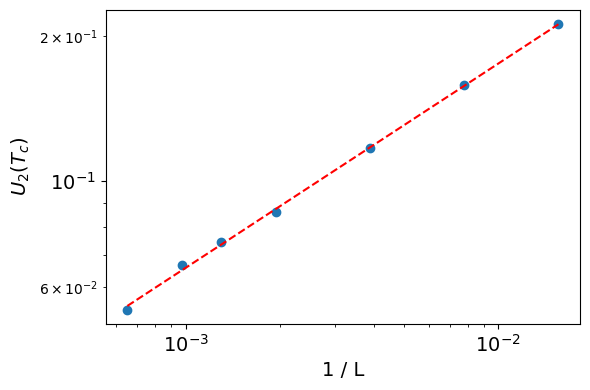

Fit parameters: a = 1.24, exponent b = 0.425


In [236]:
cv = plot_finite_size_scaling(big[big.L.isin([64, 128,256,512,768, 1024, 1536])], Tc, T_tol=0.001)

In [237]:


perr = np.sqrt(np.diag(cv))
a_err, b_err = perr

a_err, b_err

(0.02570902457996813, 0.004060900201579142)

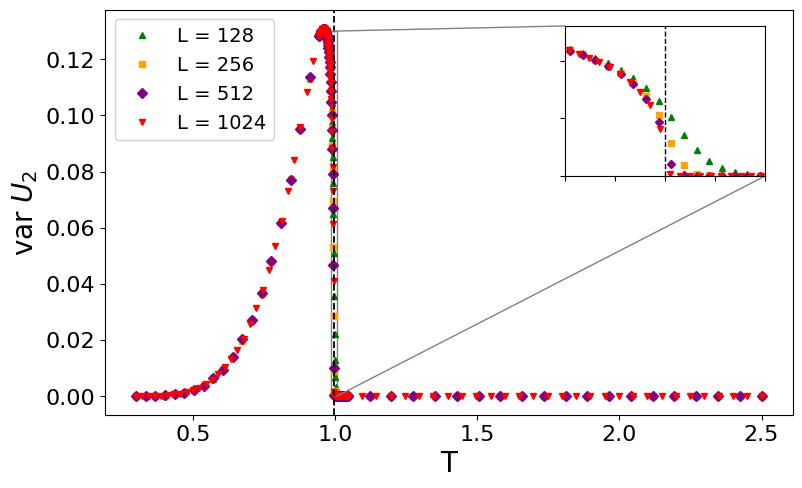

In [244]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

# ================= Plot styling by L =================
L_styles = {
    64:   dict(color="gray",      marker="+"),
    128:  dict(color="green",     marker="^"),
    256:  dict(color="orange",    marker="s"),
    384:  dict(color="tab:blue",  marker="o"),
    512:  dict(color="purple",    marker="D"),
    1024: dict(color="red",       marker="v"),
    1536: dict(color="brown",     marker="P"),
}

_default_colors = ["black", "gray"]
_default_markers = ["x", "*"]

def get_style(L, idx=0):
    if L in L_styles:
        return L_styles[L]
    return dict(
        color=_default_colors[idx % len(_default_colors)],
        marker=_default_markers[idx % len(_default_markers)]
    )


def plot_normvar_vs_T_with_inset(
    df,
    Tc,
    xcol="T",
    ycol="normvar",
    L_values=None,
    title="Normalized Variance vs Temperature (with zoom)",
    xlabel="T",
    ylabel=r"var $U_2$",
    window=0.1,
    inset_width_inch=1.6,
    inset_height_inch=1.0,
    inset_ylim=None,
    corner_offset=0.03,
    show_connectors=True
):

    fontsize_labels = 20
    fontsize_ticks = 16
    fontsize_legend = 14

    df = df.copy()
    if L_values is not None:
        df = df[df["L"].isin(L_values)]

    if xcol not in df.columns or ycol not in df.columns or "L" not in df.columns:
        raise ValueError("df must have columns: 'L', xcol, and ycol")

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---- Main plot ----
    for i, L in enumerate(sorted(df["L"].unique())):
        sub = df[df["L"] == L].sort_values(xcol)
        if sub.empty:
            continue

        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        ax.plot(
            sub[xcol],
            sub[ycol],
            marker=marker,
            color=color,
            linestyle="",
            linewidth=1.5,
            markersize=5,
            label=f"L = {L}",
        )

    ax.axvline(Tc, color="black", linestyle="--", linewidth=1.3)

    ax.set_xlabel(xlabel or xcol, fontsize=fontsize_labels)
    ax.set_ylabel(ylabel or ycol, fontsize=fontsize_labels)
    ax.tick_params(axis="both", labelsize=fontsize_ticks)
    ax.grid(False)

    legend = ax.legend(
        loc="upper left",
        fontsize=fontsize_legend,
        frameon=True,
        framealpha=0.9
    )
    legend.set_zorder(10)

    # ---- Inset ----
    axins = inset_axes(
        ax,
        width=float(inset_width_inch),
        height=float(inset_height_inch),
        loc="upper right",
        bbox_to_anchor=(1 - corner_offset, 1 - corner_offset),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    x1, x2 = Tc - window, Tc + window

    for i, L in enumerate(sorted(df["L"].unique())):
        sub = df[(df["L"] == L) & (df[xcol] >= x1) & (df[xcol] <= x2)].sort_values(xcol)
        if sub.empty:
            continue

        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        axins.plot(
            sub[xcol],
            sub[ycol],
            marker=marker,
            color=color,
            linestyle="",
            linewidth=1.2,
            markersize=4,
        )

    axins.axvline(Tc, color="black", linestyle="--", linewidth=1.0)
    axins.set_xlim(x1, x2)

    if inset_ylim is not None:
        axins.set_ylim(*inset_ylim)
    elif len(axins.lines):
        yy = np.concatenate([l.get_ydata() for l in axins.lines if len(l.get_ydata())])
        if yy.size:
            ypad = 0.05 * (np.nanmax(yy) - np.nanmin(yy) + 1e-12)
            axins.set_ylim(np.nanmin(yy) - ypad, np.nanmax(yy) + ypad)

    axins.grid(False)
    axins.set_xticklabels([])
    axins.set_yticklabels([])

    if show_connectors:
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        y1c, y2c = axins.get_ylim()

        if (x1 >= xlim[0]) and (x2 <= xlim[1]) and (y1c >= ylim[0]) and (y2c <= ylim[1]):
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)

    fig.savefig("potts_wolff_var_overlap_vs_T.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    
    
    
# Ensure normvar is computed:
big["var_overlap"] = (big["std_overlap_fraction"]**2)
# / big["mean_overlap_fraction"]

# plot_normvar_vs_T_with_inset(
#     big,
#     Tc=round(Tc, 4),
#     xcol="T",
#     ycol="var_overlap",
#     L_values=[128, 256, 512, 1024],
#     title="Variance vs Temperature",
#     window=0.02,                 # zoom half-width
#     inset_width_inch=1.5,        # rectangular inset
#     inset_height_inch=1.5,
#     inset_ylim=(-0.005, 0.05),        # <--- custom inset y-limits
#     corner_offset=0.04,
#     show_connectors=True
# )
plot_normvar_vs_T_with_inset(
    big[big.L.isin([128,256,512,1024])],
    Tc=round(Tc, 4),
    xcol="T",
    ycol="var_overlap",
    L_values=[128, 256, 512, 1024],
    title="Variance vs Temperature",
    window=0.01,                 # zoom half-width
    inset_width_inch=2,        # rectangular inset
    inset_height_inch=1.5,
    inset_ylim=(0.0, 0.13),        # <--- custom inset y-limits
    corner_offset=0.04,
    show_connectors=True
)


In [239]:
big.columns

Index(['std_overlap_fraction', 'n_measurements', 'mean_cluster_size',
       'mean_overlap_jaccard', 'std_energy', 'L', 'std_overlap_jaccard',
       'mean_energy', 'std_cluster_size', 'T', 'beta', 'mean_overlap_fraction',
       'level_folder', 'source_file'],
      dtype='object')

In [221]:
import matplotlib.pyplot as plt

def plot_mean_overlap_vs_energy(df, Ec, title="Mean overlap vs energy"):
    """
    Plot mean_overlap_fraction vs energy for each L and mark the critical energy.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain: 'L', 'mean_overlap_fraction', and an energy column ('energy' or 'E')
    Ec : float
        Critical energy (to draw vertical line)
    """
    # detect energy column
    if "energy" in df.columns:
        ecol = "energy"
    elif "mean_energy" in df.columns:
        ecol = "mean_energy"
    else:
        raise ValueError("DataFrame must have an 'energy' or 'E' column.")

    fig, ax = plt.subplots(figsize=(6, 4))

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, L in enumerate(sorted(df["L"].unique())):
        sub = df[df["L"] == L].sort_values(ecol)
        ax.plot(
            sub[ecol],
            sub["mean_overlap_fraction"],
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            linestyle="-",
            linewidth=1.5,
            markersize=5,
            label=f"L = {L}",
        )

    # vertical line at critical energy
    ax.axvline(Ec, color="red", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"$\epsilon$", fontsize = fontsize)
    ax.set_ylabel(r"$U_2$", fontsize = fontsize)
#     ax.set_title(title)
    ax.grid(False, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('potts_wolff_overlap(E).png')
    plt.show()


/var/folders/62/5kgnrj396cv9s3jb1nr9_mj40000gn/T/ipykernel_29746/2643589421.py:46: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, alpha=0.3)


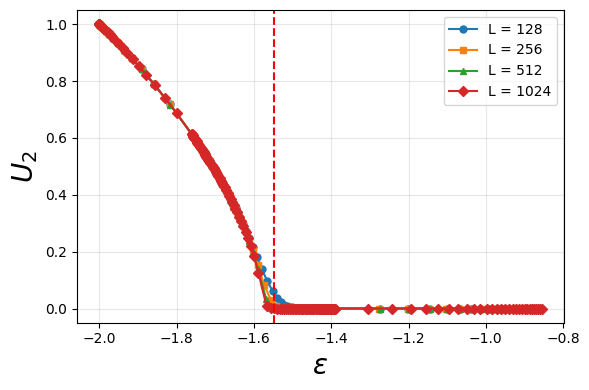

In [222]:
Ec = -1.547   # <-- put your critical energy here
plot_mean_overlap_vs_energy(big[big.L.isin([128,256,512, 1024])], Ec)

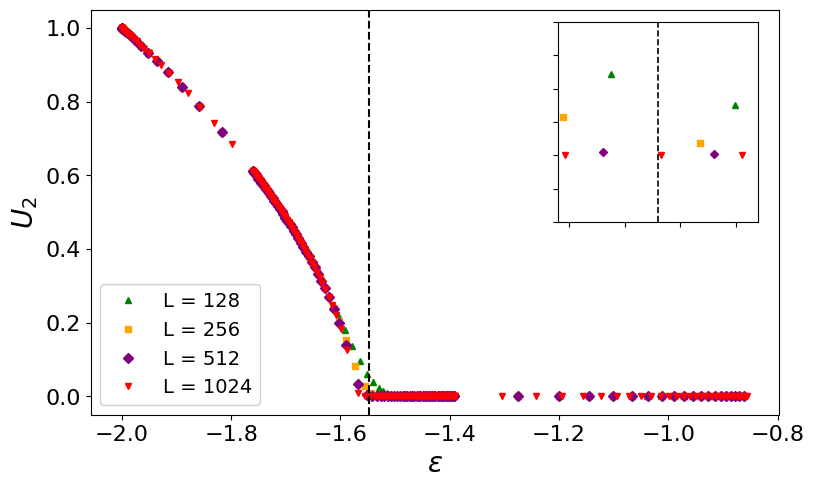

In [227]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

# ================= Plot styling by L =================
L_styles = {
    64:   dict(color="gray",      marker="+"),
    128:  dict(color="green",     marker="^"),
    256:  dict(color="orange",    marker="s"),
    384:  dict(color="tab:blue",  marker="o"),
    512:  dict(color="purple",    marker="D"),
    1024: dict(color="red",       marker="v"),
    1536: dict(color="brown",     marker="P"),
}

_default_colors = ["black", "gray"]
_default_markers = ["x", "*"]

def get_style(L, idx=0):
    if L in L_styles:
        return L_styles[L]
    return dict(
        color=_default_colors[idx % len(_default_colors)],
        marker=_default_markers[idx % len(_default_markers)]
    )


def plot_mean_overlap_vs_energy_with_inset(
    df,
    Ec,
    zoom_width=0.05,
    zoom_ylim=(-0.05, 0.1),
    title="Mean overlap vs energy with zoom",
    inset_side_inch=1.2,
    corner_offset=0.03,
):

    fontsize_labels = 20
    fontsize_ticks = 16
    fontsize_legend = 14

    # detect energy column
    if "energy" in df.columns:
        ecol = "energy"
    elif "mean_energy" in df.columns:
        ecol = "mean_energy"
    else:
        raise ValueError("DataFrame must have an 'energy' or 'mean_energy' column.")

    df = df.copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---- Main plot ----
    for i, L in enumerate(sorted(df["L"].unique())):
        sub = df[df["L"] == L].sort_values(ecol)
        if sub.empty:
            continue

        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        ax.plot(
            sub[ecol],
            sub["mean_overlap_fraction"],
            marker=marker,
            color=color,
            linestyle="",
            linewidth=1.5,
            markersize=5,
            label=f"L = {L}",
        )

    ax.axvline(Ec, color="black", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"$\epsilon$", fontsize=fontsize_labels)
    ax.set_ylabel(r"$U_2$", fontsize=fontsize_labels)
    ax.tick_params(axis="both", labelsize=fontsize_ticks)
    ax.grid(False)

    legend = ax.legend(
        loc="lower left",
        fontsize=fontsize_legend,
        frameon=True,
        framealpha=0.9
    )
    legend.set_zorder(10)

    # ---- Inset ----
    axins = inset_axes(
        ax,
        width=inset_side_inch,
        height=inset_side_inch,
        loc="upper right",
        bbox_to_anchor=(1 - corner_offset, 1 - corner_offset),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    for i, L in enumerate(sorted(df["L"].unique())):
        sub = df[df["L"] == L].sort_values(ecol)
        if sub.empty:
            continue

        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        axins.plot(
            sub[ecol],
            sub["mean_overlap_fraction"],
            marker=marker,
            color=color,
            linestyle="",
            linewidth=1.2,
            markersize=4
        )

    axins.axvline(Ec, color="black", linestyle="--", linewidth=1.2)

    axins.set_xlim(Ec - zoom_width, Ec + zoom_width)
    axins.set_ylim(*zoom_ylim)

    axins.grid(False)
    axins.set_xticklabels([])
    axins.set_yticklabels([])

    # Connector box if valid
    x1, x2 = Ec - zoom_width, Ec + zoom_width
    y1, y2 = zoom_ylim
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    if (x1 >= xlim[0]) and (x2 <= xlim[1]) and (y1 >= ylim[0]) and (y2 <= ylim[1]):
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)

    fig.savefig("potts_wolff_overlap(E).png", dpi=300, bbox_inches="tight")
    plt.show()

Ec = -1.547

plot_mean_overlap_vs_energy_with_inset(
    big[big.L.isin([128, 256, 512, 1024])],
    Ec=Ec,
    zoom_width=0.009,
    zoom_ylim=(-0.05, 0.1),
    inset_side_inch=2,  # smaller square inset
    corner_offset=0.03
)


In [224]:
1/(1+np.sqrt(3))

0.36602540378443865

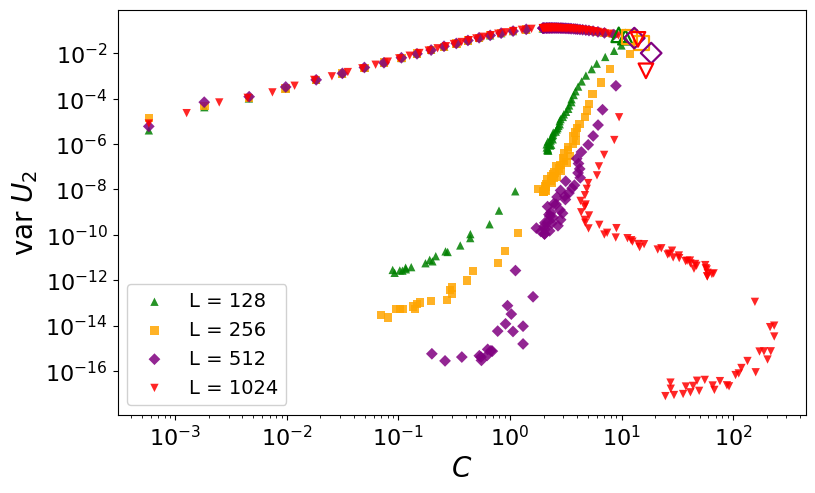

In [225]:
import numpy as np
import matplotlib.pyplot as plt

# ================= Plot styling by L =================
# L_styles = {
#     64:   dict(color="gray",      marker="+"),
#     128:  dict(color="green",     marker="^"),
#     256:  dict(color="orange",    marker="s"),
#     384:  dict(color="tab:blue",  marker="o"),
#     512:  dict(color="purple",    marker="D"),
#     1024: dict(color="red",       marker="v"),
#     1536: dict(color="brown",     marker="P"),
# }

# _default_colors = ["black", "gray"]
# _default_markers = ["x", "*"]

# def get_style(L, idx=0):
#     if L in L_styles:
#         return L_styles[L]
#     return dict(
#         color=_default_colors[idx % len(_default_colors)],
#         marker=_default_markers[idx % len(_default_markers)]
#     )


def plot_variance_vs_heat_capacity_by_L(
    df,
    Tc,
    L_values=None,
    window=0.1,
    loglog=False,
    annotate_peaks=False,
    point_size=40,
    critical_size=90,
    title="Variance vs Heat Capacity by L (critical region highlighted)"
):

    fontsize_labels = 20
    fontsize_ticks = 16
    fontsize_legend = 14

    df = df.copy()

    if L_values is not None:
        df = df[df["L"].isin(L_values)]

    if "var_overlap" not in df.columns:
        if "std_overlap_fraction" not in df.columns:
            raise ValueError("df must contain 'std_overlap_fraction'.")
        df["var_overlap"] = df["std_overlap_fraction"]**2

    if "heat_capacity" not in df.columns:
        if not {"std_energy", "T", "L"}.issubset(df.columns):
            raise ValueError("Need 'std_energy','T','L' to compute heat_capacity.")
        df["var_energy"] = df["std_energy"]**2
        df["heat_capacity"] = (df["L"]**2) * df["var_energy"] / (df["T"]**2)

    crit_mask = (df["T"] >= Tc - window) & (df["T"] <= Tc + window)

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, L in enumerate(sorted(df["L"].unique())):
        sub = df[df["L"] == L]
        if sub.empty:
            continue

        style = get_style(L, i)
        color = style["color"]
        marker = style["marker"]

        # --- non-critical points ---
        sub_noncrit = sub[~crit_mask.loc[sub.index]]
        ax.scatter(
            sub_noncrit["heat_capacity"],
            sub_noncrit["var_overlap"],
            s=point_size,
            marker=marker,
            color=color,
            alpha=0.85,
            edgecolors="none",
            label=f"L = {L}"
        )

        # --- critical points (same color, hollow) ---
        sub_crit = sub[crit_mask.loc[sub.index]]
        if not sub_crit.empty:
            ax.scatter(
                sub_crit["heat_capacity"],
                sub_crit["var_overlap"],
                s=critical_size,
                marker=marker,
                facecolors="none",
                edgecolors=color,   # match L color
                linewidths=1.6,
                zorder=3,
            )

        # --- optional peak ---
        if annotate_peaks and len(sub) > 0:
            idx_max = sub["var_overlap"].idxmax()
            ax.scatter(
                sub.loc[idx_max, "heat_capacity"],
                sub.loc[idx_max, "var_overlap"],
                s=critical_size,
                facecolors="none",
                edgecolors="black",
                linewidths=1.5,
                marker="D",
                zorder=4,
            )

    if loglog:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlabel("$C$", fontsize=fontsize_labels)
    ax.set_ylabel(r"var $U_2$", fontsize=fontsize_labels)
    ax.tick_params(axis="both", labelsize=fontsize_ticks)
    ax.grid(False)

    legend = ax.legend(
        loc="lower left",
        fontsize=fontsize_legend,
        frameon=True,
        framealpha=0.9
    )
    legend.set_zorder(10)

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.95)
    fig.savefig("variance_vs_heat_capacity.png", dpi=300, bbox_inches="tight")

    plt.show()

plot_variance_vs_heat_capacity_by_L(
    df=big,
    Tc=round(Tc, 4),             # your Ising Tc, or use your Potts Tc
    L_values=[128, 256, 512, 1024],
    window=0.001,                    # highlight |T - Tc| <= 0.12
    loglog=True,
    annotate_peaks=False,
    point_size=36,
    critical_size=110,
    title="Variance vs Heat Capacity (Potts) — critical region highlighted"
)


In [124]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fig4_style_varO_left(
    df,
    Tc,
    L_values=None,           # e.g. [128,256,512,1024,1536]; None = use all
    window=0.10,             # critical region half-width for highlighting
    show_errors=True,        # draw error bars if n_measurements is present
    loglog_right=True,       # RHS panel on log–log axes
    point_size=36,
    critical_size=110,
    star_size=180,           # size for critical-point star markers
    legend_loc_left="best",
    legend_loc_right="best",
    title_left="(a) Var(Overlap) vs T",
    title_right="(b) Var(Overlap) × T⁻² vs C",
    save_path=None           # path to save PNG; None = just show
):
    """
    Two-panel figure (Fig.4-style):
      Left:  Var(Overlap) vs T   (clean; no critical-region highlighting, no stars)
      Right: Var(Overlap) * T^{-2} vs Heat Capacity (critical region highlighted; star at Tc point)

    Expects columns:
      - L, T
      - std_overlap_fraction (for Var(O))
      - std_energy (for Var(E) and C), or precomputed 'heat_capacity'
      - n_measurements (optional, for error bars)

    If heat_capacity is absent, it is computed as C = (N/T^2)*Var(E) with N=L^2.
    """

    data = df.copy()
    if L_values is not None:
        data = data[data["L"].isin(L_values)]

    # Var(Overlap)
    if "var_overlap" not in data.columns:
        if "std_overlap_fraction" not in data.columns:
            raise ValueError("Need 'std_overlap_fraction' to compute var_overlap.")
        data["var_overlap"] = data["std_overlap_fraction"]**2

    # Heat capacity (C = N/T^2 * Var(E)) if needed
    if "heat_capacity" not in data.columns:
        if "std_energy" not in data.columns:
            raise ValueError("Need 'std_energy' (or precomputed 'heat_capacity').")
        data["var_energy"] = data.get("var_energy", data["std_energy"]**2)
        data["heat_capacity"] = (data["L"]**2) * data["var_energy"] / (data["T"]**2)

    # Right-panel Y: Var(O)*T^{-2}
    data["var_overlap_T2"] = data["var_overlap"] / (data["T"]**2)

    # Critical region mask
    crit_mask = (data["T"] >= Tc - window) & (data["T"] <= Tc + window)

    # Error estimates (optional; shown if n_measurements present & show_errors=True)
    has_n = "n_measurements" in data.columns
    if has_n:
        Nmeas = data["n_measurements"].astype(float).replace(0, np.nan)
        # ΔVar ≈ Var * sqrt(2/(N-1))  (Gaussian assumption)
        data["varO_err"] = data["var_overlap"] * np.sqrt(2.0 / np.maximum(Nmeas - 1.0, 1.0))
        data["varO_T2_err"] = data["varO_err"] / (data["T"]**2)

    # Figure & axes
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # ---------- Left: Var(Overlap) vs T (no red region, no stars) ----------
    used_labels = set()
    for i, L in enumerate(sorted(data["L"].unique())):
        sub = data[data["L"] == L].sort_values("T")
        if sub.empty:
            continue
        label = f"L = {L}" if f"L = {L}" not in used_labels else None

        if show_errors and has_n:
            axL.errorbar(
                sub["T"], sub["var_overlap"],
                yerr=sub["varO_err"],
                fmt=markers[i % len(markers)] + "-", ms=5,
                elinewidth=1.2, capsize=3, alpha=0.85,
                label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                color=colors[i % len(colors)]
            )
        else:
            axL.plot(
                sub["T"], sub["var_overlap"],
                markers[i % len(markers)] + "-",
                ms=5, alpha=0.85,
                label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                color=colors[i % len(colors)]
            )
        used_labels.add(f"L = {L}")

    axL.axvline(Tc, color="gray", linestyle="--", linewidth=1.2)
    axL.set_xlabel("T")
    axL.set_ylabel(r"$Var\ U_2$")
    axL.set_title(title_left)
    axL.grid(True, alpha=0.3)
    axL.legend(loc=legend_loc_left)

    # ---------- Right: Var(Overlap)*T^{-2} vs Heat Capacity ----------
    used_labels = set()
    for i, L in enumerate(sorted(data["L"].unique())):
        sub = data[data["L"] == L]
        if sub.empty:
            continue

        # non-critical points
        sub_nc = sub[~crit_mask.loc[sub.index]]
        if not sub_nc.empty:
            if show_errors and has_n:
                axR.errorbar(
                    sub_nc["heat_capacity"], sub_nc["var_overlap_T2"],
                    yerr=sub_nc["varO_T2_err"],
                    fmt=markers[i % len(markers)], ms=5,
                    elinewidth=1.2, capsize=3, alpha=0.85,
                    label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                    color=colors[i % len(colors)]
                )
            else:
                axR.scatter(
                    sub_nc["heat_capacity"], sub_nc["var_overlap_T2"],
                    s=point_size, alpha=0.85,
                    marker=markers[i % len(markers)],
                    color=colors[i % len(colors)],
                    label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                    edgecolors="none"
                )
            used_labels.add(f"L = {L}")

        # critical region (red hollow)
        sub_c = sub[crit_mask.loc[sub.index]]
        if not sub_c.empty:
            axR.scatter(
                sub_c["heat_capacity"], sub_c["var_overlap_T2"],
                s=critical_size, facecolors="none",
                edgecolors="red", linewidths=1.5, zorder=3
            )

        # star at point closest to Tc
        i_star = (sub["T"] - Tc).abs().idxmin()
        axR.scatter(
            sub.loc[i_star, "heat_capacity"], sub.loc[i_star, "var_overlap_T2"],
            marker="*", s=star_size, color="gold",
            edgecolors="black", linewidths=1.2, zorder=4
        )

    if loglog_right:
        axR.set_xscale("log")
        axR.set_yscale("log")

    axR.set_xlabel("C")
    axR.set_ylabel(r"$Var\ U_2 × T^{-2}$")
#     axR.set_title(title_right)
    axR.grid(True, alpha=0.3, which="both")

    # Legend only on the right panel
    crit_label = f"Critical region |T - Tc| ≤ {window}"
    star_proxy_R = axR.scatter([], [], marker="*", s=star_size, color="gold",
                               edgecolors="black", linewidths=1.2)
    crit_proxy_R = axR.scatter([], [], s=critical_size, facecolors="none",
                               edgecolors="red", linewidths=1.5)
    handles_R, labels_R = axR.get_legend_handles_labels()
    handles_R += [star_proxy_R, crit_proxy_R]
    labels_R  += ["Point nearest Tc", crit_label]
    axR.legend(handles_R, labels_R, loc=legend_loc_right)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"✓ Saved figure → {save_path}")
    else:
        plt.show()
        
plot_fig4_style_varO_left(
    df=big,
    Tc=round(Tc, 4),             # your Ising Tc, or use your Potts Tc
    L_values=[128, 256, 512, 1024],
    window=0.001,                    # highlight |T - Tc| <= 0.12
    show_errors=False,               # needs 'n_measurements'
    loglog_right=True,
    star_size=220,
    save_path="potts_wolff_var(O) vs C.png"                  # or "fig4_style_varO.png"
)

✓ Saved figure → potts_wolff_var(O) vs C.png


In [126]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fig4_style_varO_left(
    df,
    Tc,
    L_values=None,           # e.g. [128,256,512,1024,1536]; None = use all
    window=0.10,             # critical region half-width for highlighting
    show_errors=True,        # draw error bars if n_measurements is present
    loglog_right=True,       # RHS panel on log–log axes
    point_size=36,
    critical_size=110,
    star_size=180,           # size for critical-point star markers
    legend_loc_left="best",
    legend_loc_right="best",
    title_left="(a) Var(Overlap) vs T",
    title_right="(b) Var(Overlap) × T⁻² vs C",
    save_path=None           # path to save PNG; None = just show
):

    data = df.copy()
    if L_values is not None:
        data = data[data["L"].isin(L_values)]

    # Var(Overlap)
    if "var_overlap" not in data.columns:
        if "std_overlap_fraction" not in data.columns:
            raise ValueError("Need 'std_overlap_fraction' to compute var_overlap.")
        data["var_overlap"] = data["std_overlap_fraction"]**2

    # Heat capacity
    if "heat_capacity" not in data.columns:
        if "std_energy" not in data.columns:
            raise ValueError("Need 'std_energy' (or precomputed 'heat_capacity').")
        data["var_energy"] = data.get("var_energy", data["std_energy"]**2)
        data["heat_capacity"] = (data["L"]**2) * data["var_energy"] / (data["T"]**2)

    # Right-panel Y
    data["var_overlap_T2"] = data["var_overlap"] / (data["T"]**2)

    # Critical region mask
    crit_mask = (data["T"] >= Tc - window) & (data["T"] <= Tc + window)

    # Error estimates
    has_n = "n_measurements" in data.columns
    if has_n:
        Nmeas = data["n_measurements"].astype(float).replace(0, np.nan)
        data["varO_err"] = data["var_overlap"] * np.sqrt(2.0 / np.maximum(Nmeas - 1.0, 1.0))
        data["varO_T2_err"] = data["varO_err"] / (data["T"]**2)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # ---------- Left panel ----------
    used_labels = set()
    for i, L in enumerate(sorted(data["L"].unique())):
        sub = data[data["L"] == L].sort_values("T")
        if sub.empty:
            continue

        if show_errors and has_n:
            axL.errorbar(
                sub["T"], sub["var_overlap"],
                yerr=sub["varO_err"],
                fmt=markers[i % len(markers)] + "-", ms=5,
                elinewidth=1.2, capsize=3, alpha=0.85,
                label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                color=colors[i % len(colors)]
            )
        else:
            axL.plot(
                sub["T"], sub["var_overlap"],
                markers[i % len(markers)] + "-",
                ms=5, alpha=0.85,
                label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                color=colors[i % len(colors)]
            )

        used_labels.add(f"L = {L}")

    axL.axvline(Tc, color="gray", linestyle="--", linewidth=1.2)
    axL.set_xlabel("T")
    axL.set_ylabel(r"$Var\ U_2$")
#     axL.set_title(title_left)

    # REMOVE GRID
    axL.grid(False)

    axL.legend(loc=legend_loc_left)

    # ---------- Right panel ----------
    used_labels = set()
    for i, L in enumerate(sorted(data["L"].unique())):
        sub = data[data["L"] == L]
        if sub.empty:
            continue

        sub_nc = sub[~crit_mask.loc[sub.index]]
        if not sub_nc.empty:
            if show_errors and has_n:
                axR.errorbar(
                    sub_nc["heat_capacity"], sub_nc["var_overlap_T2"],
                    yerr=sub_nc["varO_T2_err"],
                    fmt=markers[i % len(markers)], ms=5,
                    elinewidth=1.2, capsize=3, alpha=0.85,
                    label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                    color=colors[i % len(colors)]
                )
            else:
                axR.scatter(
                    sub_nc["heat_capacity"], sub_nc["var_overlap_T2"],
                    s=point_size, alpha=0.85,
                    marker=markers[i % len(markers)],
                    color=colors[i % len(colors)],
                    label=f"L = {L}" if f"L = {L}" not in used_labels else None,
                    edgecolors="none"
                )
            used_labels.add(f"L = {L}")

        sub_c = sub[crit_mask.loc[sub.index]]
        if not sub_c.empty:
            axR.scatter(
                sub_c["heat_capacity"], sub_c["var_overlap_T2"],
                s=critical_size, facecolors="none",
                edgecolors="red", linewidths=1.5, zorder=3
            )

        i_star = (sub["T"] - Tc).abs().idxmin()
        axR.scatter(
            sub.loc[i_star, "heat_capacity"], sub.loc[i_star, "var_overlap_T2"],
            marker="*", s=star_size, color="gold",
            edgecolors="black", linewidths=1.2, zorder=4
        )

    if loglog_right:
        axR.set_xscale("log")
        axR.set_yscale("log")

    axR.set_xlabel("C")
    axR.set_ylabel(r"$Var\ U_2 × T^{-2}$")
#     axR.set_title(title_right)

    # REMOVE GRID (including minor log grid)
    axR.grid(False)

    crit_label = f"Critical region |T - Tc| ≤ {window}"
    star_proxy_R = axR.scatter([], [], marker="*", s=star_size, color="gold",
                               edgecolors="black", linewidths=1.2)
    crit_proxy_R = axR.scatter([], [], s=critical_size, facecolors="none",
                               edgecolors="red", linewidths=1.5)

    handles_R, labels_R = axR.get_legend_handles_labels()
    handles_R += [star_proxy_R, crit_proxy_R]
    labels_R  += ["Point nearest Tc", crit_label]

    axR.legend(handles_R, labels_R, loc=legend_loc_right)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"✓ Saved figure → {save_path}")
    else:
        plt.show()


# Example call
plot_fig4_style_varO_left(
    df=big,
    Tc=round(Tc, 4),
    L_values=[128, 256, 512, 1024],
    window=0.001,
    show_errors=False,
    loglog_right=True,
    star_size=220,
    save_path="potts_wolff_var(O) vs C.png"
)

✓ Saved figure → potts_wolff_var(O) vs C.png


# New block

# Ising Многошаговый Swendsen-Wang

In [171]:
df = pd.read_csv('/Users/ianpile/Downloads/results_ising_sw_new.csv')

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


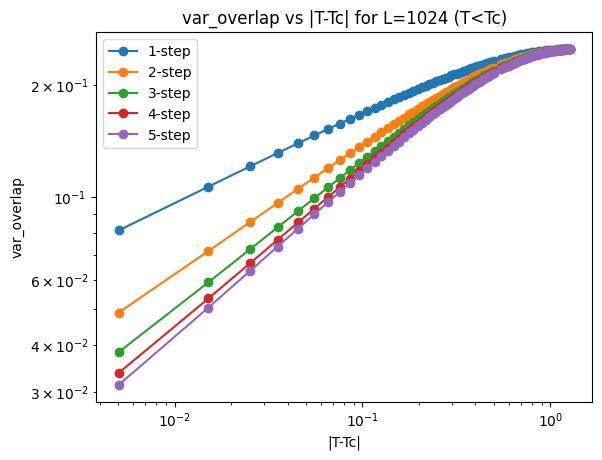

In [173]:

# df=pd.read_csv('/mnt/data/results_ising_sw_new.csv')
Tc=2.269185
sub=df[(df['L']==1024)&(df['T']<Tc)]
plt.figure()
for k in range(1,6):
    x=np.abs(sub['T']-Tc)
    y=sub[f'var_overlap_{k}step']
    plt.loglog(x,y,'o-',label=f'{k}-step')
plt.xlabel('|T-Tc|'); plt.ylabel('var_overlap'); plt.title('var_overlap vs |T-Tc| for L=1024 (T<Tc)')
plt.legend()
plt.show()


# это вставляем в статью

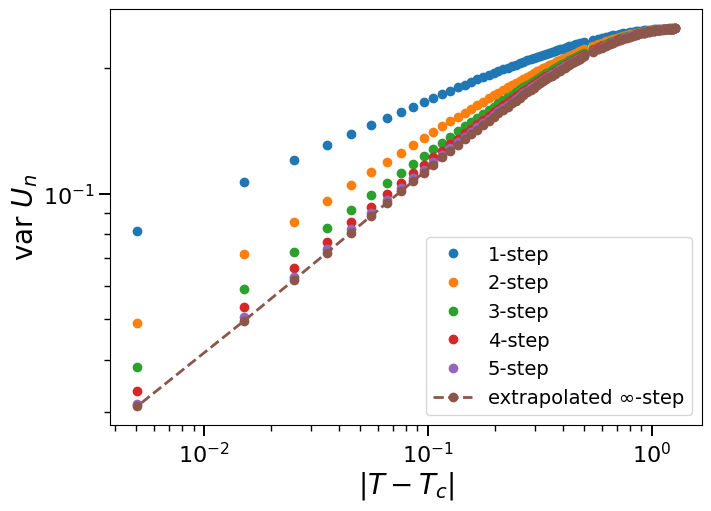

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

# Try importing scipy for curve fitting
try:
    from scipy.optimize import curve_fit
    have_scipy = True
except Exception:
    have_scipy = False

# ---- fixed font sizes (same as other plots) ----
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 15

Tc = 2.269185

# Select L=1024 and T<Tc
sub = df[(df['L'] == 1024) & (df['T'] < Tc)].copy()
sub = sub.sort_values('T')

# Collect k-step columns (1..5)
k_vals = np.arange(1, 6)
cols = [f'var_overlap_{k}step' for k in k_vals]

# Exponential model
def model(k, v_inf, A, tau):
    return v_inf + A * np.exp(-k / tau)

v_inf_list = []
x_list = []

for _, row in sub.iterrows():
    vk = row[cols].values.astype(float)
    T = row['T']
    x = abs(T - Tc)

    p0 = [vk[-1], vk[0] - vk[-1], 1.0]

    if have_scipy:
        try:
            popt, _ = curve_fit(model, k_vals, vk, p0=p0, maxfev=5000)
            v_inf = popt[0]
        except Exception:
            v_inf = vk[-1]
    else:
        v_inf = vk[-1]

    v_inf_list.append(v_inf)
    x_list.append(x)

x_arr = np.array(x_list)
v_inf_arr = np.array(v_inf_list)

# =========================================================
# Styled Plot (consistent with previous Ising plots)
# =========================================================
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Finite k curves
for k in k_vals:
    ax.loglog(x_arr,
              sub[f'var_overlap_{k}step'].values,
              marker='o',
              linestyle='',
              label=f'{k}-step')

# Extrapolated infinite-step curve
ax.loglog(x_arr,
          v_inf_arr,
          marker='o',
          linestyle='--',
          linewidth=2,
          label='extrapolated ∞-step')

# ---- Labels ----
ax.set_xlabel(r'$|T-T_c|$', fontsize=LABEL_FONTSIZE, labelpad=2)
ax.set_ylabel(r'$\mathrm{var}\ U_n$', fontsize=LABEL_FONTSIZE, labelpad=2)

# ---- Log tick styling (clean powers of 10) ----
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))

ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_major_formatter(LogFormatterMathtext())

# Remove minor tick labels
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

# ---- Tick appearance ----
ax.tick_params(axis='both', which='major',
               labelsize=TICK_FONTSIZE,
               length=8, width=1.4)

ax.tick_params(axis='both', which='minor',
               length=4, width=1.0)

ax.grid(False)
ax.legend(fontsize=14)

plt.savefig('Ising_SW_varU_multistep_vs_T.png', dpi=300,
            bbox_inches="tight",
            pad_inches=0.05)

plt.show()

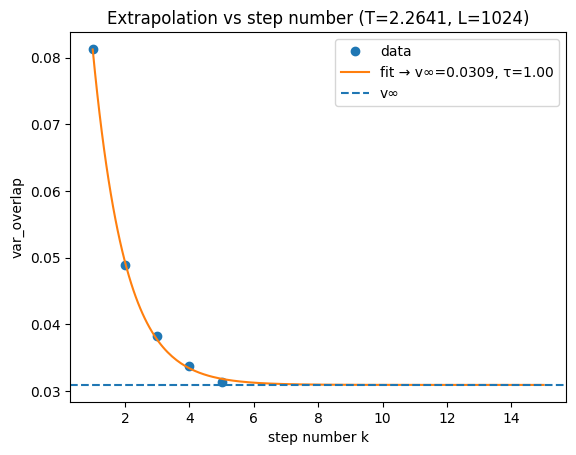

(2.264134808949495, 0.03091517537130701, 1.0009283717292337)

In [175]:
# df = pd.read_csv('/mnt/data/results_ising_sw_new.csv')

Tc = 2.269185

# Choose a representative temperature close to Tc but not the closest one
sub = df[(df['L'] == 1024) & (df['T'] < Tc)].copy()
sub['x'] = abs(sub['T'] - Tc)
sub = sub.sort_values('x')

# Pick, for example, the 10th closest point to Tc
row = sub.iloc[0]
T_sel = row['T']

k_vals = np.arange(1, 6)
vk = np.array([row[f'var_overlap_{k}step'] for k in k_vals])

# Exponential convergence model
def model_k(k, v_inf, A, tau):
    return v_inf + A * np.exp(-k*tau)

p0 = [vk[-1], vk[0] - vk[-1], 1.0]
popt, pcov = curve_fit(model_k, k_vals, vk, p0=p0, maxfev=5000)
v_inf, A_fit, tau_fit = popt

# Fine k-grid for extrapolation
k_fine = np.linspace(1, 15, 200)
vk_fit = model_k(k_fine, *popt)

# Plot
plt.figure()
plt.plot(k_vals, vk, 'o', label='data')
plt.plot(k_fine, vk_fit, '-', label=f'fit → v∞={v_inf:.4f}, τ={tau_fit:.2f}')
plt.axhline(v_inf, ls='--', label='v∞')
plt.xlabel('step number k')
plt.ylabel('var_overlap')
plt.title(f'Extrapolation vs step number (T={T_sel:.4f}, L=1024)')
plt.legend()
plt.show()

T_sel, v_inf, tau_fit


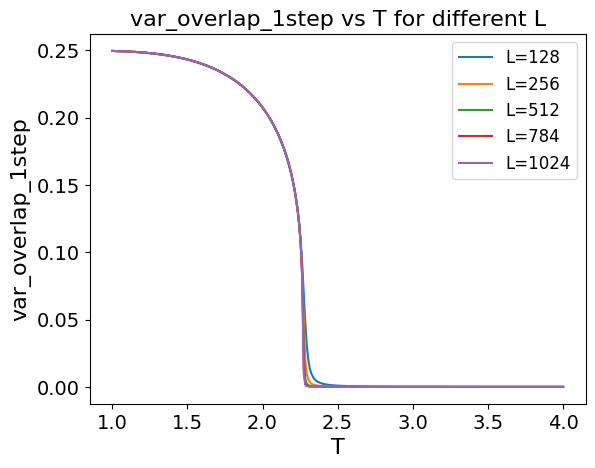

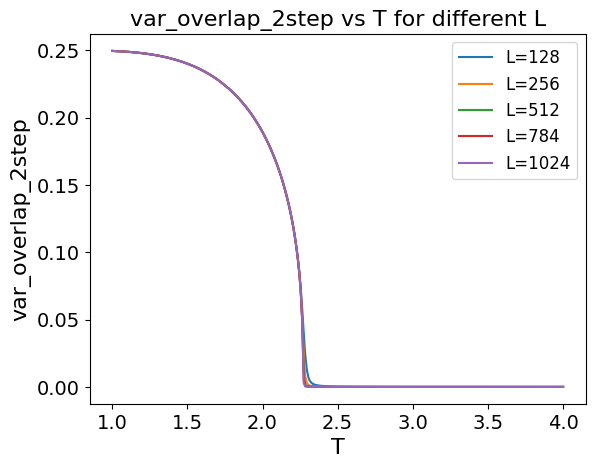

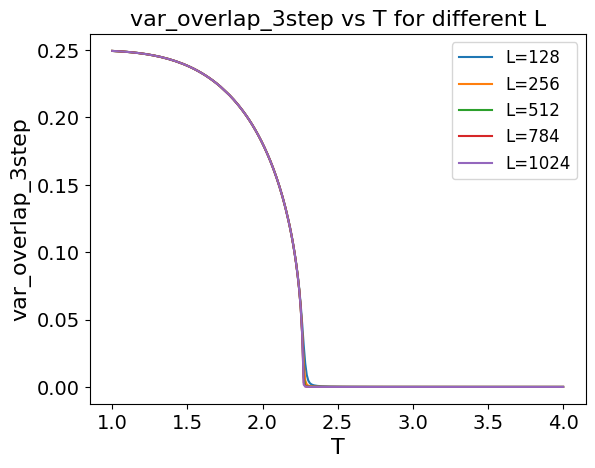

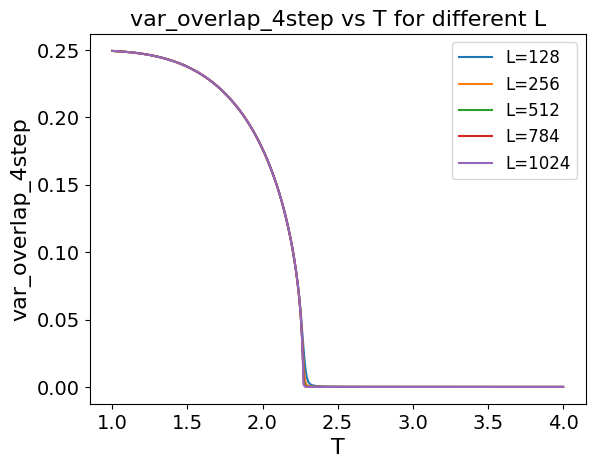

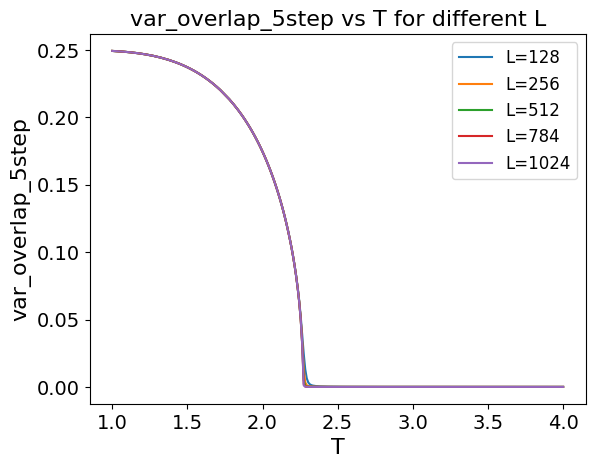

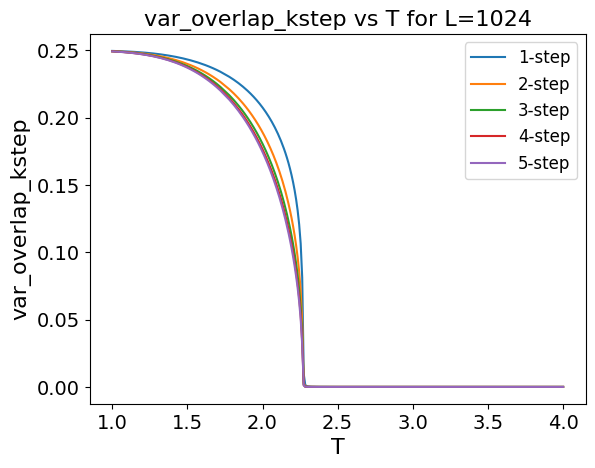

In [181]:
import matplotlib.pyplot as plt

# unique L and ks
Ls=sorted(df['L'].unique())
ks=range(1,6)

# 1: var_overlap_kstep vs T for different L and fixed k
for k in ks:
    plt.figure()
    for L in Ls:
        sub=df[df['L']==L]
        plt.plot(sub['T'], sub[f'var_overlap_{k}step'], label=f'L={L}')
    plt.xlabel('T'); plt.ylabel(f'var_overlap_{k}step'); plt.title(f'var_overlap_{k}step vs T for different L')
    plt.legend()
    plt.show()

# 2: var_overlap_kstep vs T for L=512 varying k
L=1024
sub=df[df['L']==L]
plt.figure()
for k in ks:
    plt.plot(sub['T'], sub[f'var_overlap_{k}step'], label=f'{k}-step')
plt.xlabel('T'); plt.ylabel('var_overlap_kstep'); plt.title('var_overlap_kstep vs T for L=1024')
plt.legend()
plt.show()

# SW Potts 

Using Tc = 0.994972861071817


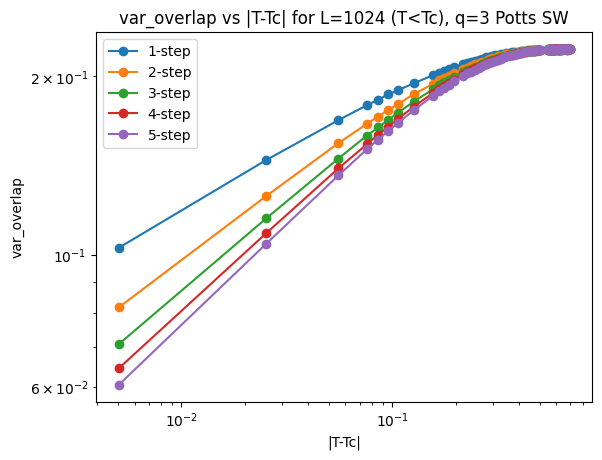

In [177]:
# Load the provided Potts Swendsen-Wang data
path = "results_sw_potts3_multistep.csv"
df = pd.read_csv(path)

# Peek at columns to infer naming (printed for user visibility)
# print("Columns:", df.columns.tolist())
# print(df.head())

# Try to infer Tc for 2D q=3 Potts (exact critical temperature in units J/kB)
# Tc = 1 / ln(1+sqrt(3))
Tc = 1.0 / np.log(1 + np.sqrt(3))

print("Using Tc =", Tc)

# Match the user's Ising-style example: pick largest L available
Lmax = df["L"].max()
sub = df[(df["L"] == Lmax) & (df["T"] < Tc)]

plt.figure()
# Assume columns like var_overlap_1step ... var_overlap_5step exist
for k in range(1, 6):
    col = f"var_overlap_{k}step"
    if col in sub.columns:
        x = np.abs(sub["T"] - Tc)
        y = sub[col]
        plt.loglog(x, y, 'o-', label=f"{k}-step")

plt.xlabel("|T-Tc|")
plt.ylabel("var_overlap")
plt.title(f"var_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), q=3 Potts SW")
plt.legend()
plt.show()


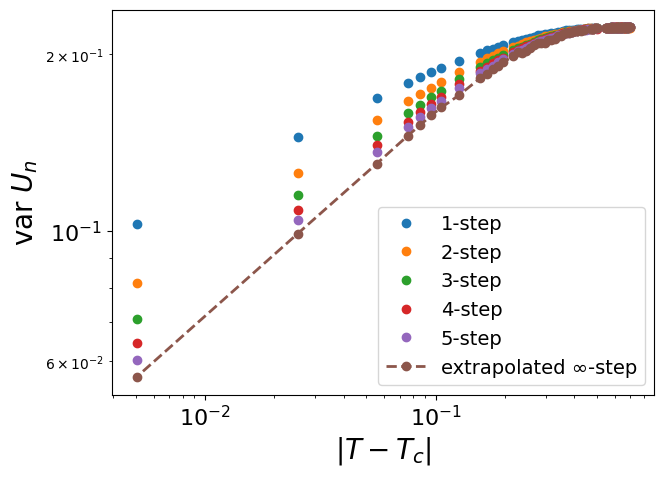

In [179]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# # -----------------------------
# # Load data
# # -----------------------------
# df = pd.read_csv("/mnt/data/results_ising_sw_new.csv")

# Tc = 2.269185

# Select L=1024 and T<Tc
sub = df[(df["L"] == 1024) & (df["T"] < Tc)].copy()
sub = sub.sort_values("T")

# k values and column names
k_vals = np.arange(1, 6)
cols = [f"var_overlap_{k}step" for k in k_vals]

# -----------------------------
# Exponential convergence model
# v_k = v_inf + A * exp(-k/tau)
# -----------------------------
def model(k, v_inf, A, tau):
    return v_inf + A * np.exp(-k / tau)

# Storage
v_inf_list = []
x_list = []

# Threshold for deciding whether extrapolation is meaningful
dk_min = 5e-4   # can tune between ~1e-4 and 1e-3

# -----------------------------
# Main loop
# -----------------------------
for _, row in sub.iterrows():
    vk = row[cols].values.astype(float)

    T = row["T"]
    x = abs(T - Tc)

    # Total variation across steps
    dk = abs(vk[0] - vk[-1])

    # Case 1: almost flat in k -> skip extrapolation
    if dk < dk_min:
        v_inf = vk[-1]

    else:
        # Initial guesses
        p0 = [vk[-1], vk[0] - vk[-1], 1.0]

        try:
            popt, _ = curve_fit(model, k_vals, vk, p0=p0, maxfev=5000)
            v_inf = popt[0]

            # -----------------------------
            # Physical constraints
            # -----------------------------

            # Must not exceed last step
            v_inf = min(v_inf, vk[-1])

            # Must not fall far below last step
            if v_inf < 0.9 * vk[-1]:
                v_inf = vk[-1]

        except Exception:
            v_inf = vk[-1]

    v_inf_list.append(v_inf)
    x_list.append(x)

x_arr = np.array(x_list)
v_inf_arr = np.array(v_inf_list)

# -----------------------------
# Plot
# -----------------------------
# plt.figure()

# for k in k_vals:
#     plt.loglog(
#         x_arr,
#         sub[f"var_overlap_{k}step"].values,
#         "o-",
#         label=f"{k}-step",
#     )

    
# x = 35

# plt.loglog(list(x_arr[:x-1])+list(x_arr[x+1:]), 
#            list(v_inf_arr[:x-1])+list(v_inf_arr[x+1:]), "o-", label="extrapolated ∞-step")

# # plt.xlabel("|T-Tc|")
# # plt.ylabel("var_overlap")
# plt.xlabel(r'$|T-T_c|$', fontsize = fontsize)
# plt.ylabel(r'$var\ (U_k)$', fontsize = fontsize)
# # plt.title("var_overlap vs |T-Tc| for L=1024 (T<Tc): finite k and extrapolated k→∞")
# plt.legend()
# plt.savefig('Potts_SW_varU_multistep_vs_T.png', dpi=200)
# plt.show()
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))

for k in k_vals:
    plt.loglog(
        x_arr,
        sub[f"var_overlap_{k}step"].values,
        "o",
        label=f"{k}-step",
    )

x = 35

# Extrapolated curve (now dashed)
plt.loglog(
    list(x_arr[:x-1]) + list(x_arr[x+1:]),
    list(v_inf_arr[:x-1]) + list(v_inf_arr[x+1:]),
    "o--",                     # <-- dashed
    linewidth=2,
    label="extrapolated ∞-step"
)

# ---- Axis labels ----
plt.xlabel(r"$|T-T_c|$", fontsize=20)
plt.ylabel(r"var $U_n$", fontsize=20)

# ---- Tick sizes ----
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# ---- Legend size ----
plt.legend(fontsize=14)

plt.grid(False)
plt.savefig("Potts_SW_varU_multistep_vs_T.png", dpi=300,
            bbox_inches="tight",
            pad_inches=0.05)
plt.show()

In [260]:
# Match the user's Ising-style example: pick largest L available
# df["L"].max()
# list(x_arr[:x-1])+list(x_arr[x:])

# Wolff Ising 

Using Tc = 2.269185


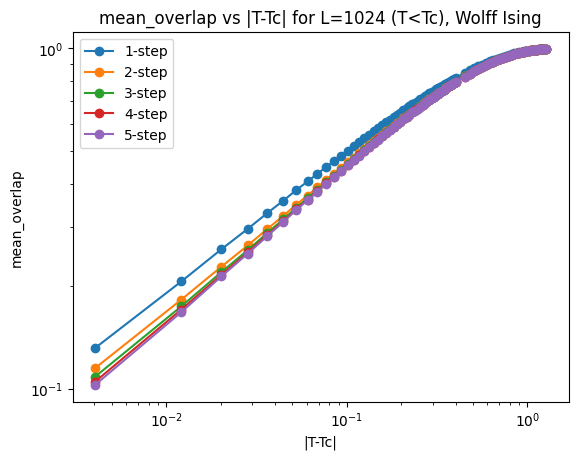

In [180]:
# Load Wolff Ising multistep data
path = "results_wolff_ising_multistep.csv"
df = pd.read_csv(path)

# 2D Ising critical temperature (as in user's example)
Tc = 2.269185
print("Using Tc =", Tc)

# Use largest L available
Lmax = df["L"].max()
sub = df[(df["L"] == Lmax) & (df["T"] < Tc)]


# ---------- MEAN OVERLAP PLOT ----------
plt.figure()
for k in range(1, 6):
    col = f"mean_overlap_fraction_{k}step"
    if col in sub.columns:
        x = np.abs(sub["T"] - Tc)
        y = sub[col]
        plt.loglog(x, y, "o-", label=f"{k}-step")

plt.xlabel("|T-Tc|")
plt.ylabel("mean_overlap")
plt.title(f"mean_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), Wolff Ising")
plt.legend()
plt.show()


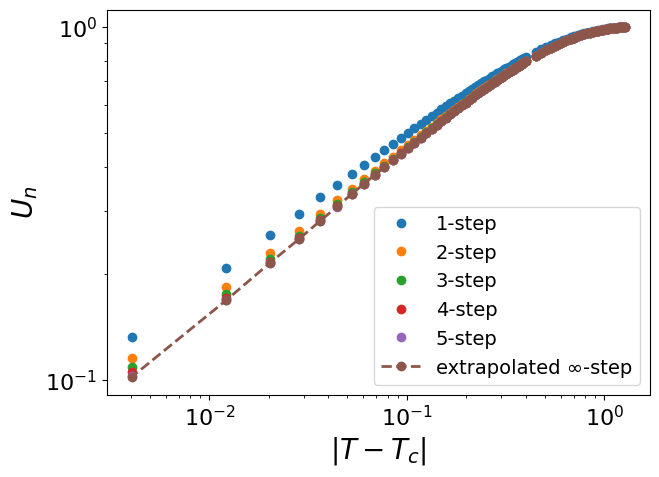

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try importing scipy for curve fitting
try:
    from scipy.optimize import curve_fit
    have_scipy = True
except Exception:
    have_scipy = False

# Load data
# df = pd.read_csv('/mnt/data/results_ising_sw_new.csv')

Tc = 2.269185

# Select L=1024 and T<Tc
sub = df[(df['L'] == 1024) & (df['T'] < Tc)].copy()
sub = sub.sort_values('T')

# Collect k-step columns (1..5)
k_vals = np.arange(1, 6)
cols = [f'mean_overlap_fraction_{k}step' for k in k_vals]

# Exponential model: v_k = v_inf + A * exp(-k/tau)
def model(k, v_inf, A, tau):
    return v_inf + A * np.exp(-k / tau)

v_inf_list = []
x_list = []

for _, row in sub.iterrows():
    vk = row[cols].values.astype(float)
    T = row['T']
    x = abs(T - Tc)

    # Initial guesses
    p0 = [vk[-1], vk[0] - vk[-1], 1.0]

    if have_scipy:
        try:
            popt, _ = curve_fit(model, k_vals, vk, p0=p0, maxfev=5000)
            v_inf = popt[0]
        except Exception:
            # Fallback: take last value
            v_inf = vk[-1]
    else:
        # Simple fallback: assume last value ~ asymptotic
        v_inf = vk[-1]

    v_inf_list.append(v_inf)
    x_list.append(x)

x_arr = np.array(x_list)
v_inf_arr = np.array(v_inf_list)

# Also plot the raw k=1..5 curves for comparison
# plt.figure()

# for k in k_vals:
#     plt.loglog(x_arr, sub[f'mean_overlap_fraction_{k}step'].values, 'o-', label=f'{k}-step')

# # Plot extrapolated infinite-step curve
# plt.loglog(x_arr, v_inf_arr, 'o-', label='extrapolated ∞-step')

# # plt.xlabel('|T-Tc|')
# plt.xlabel(r'$|T-T_c|$', fontsize = fontsize)
# plt.ylabel(r'$U_k$', fontsize = fontsize)
# # plt.ylabel('mean_overlap_fraction')
# # plt.title('mean_overlap_fraction vs |T-Tc| for L=1024 (T<Tc): finite k and extrapolated k→∞')
# plt.savefig('Ising_Wolff_U_multistep_vs_T.png', dpi=200)
# plt.legend()
# plt.show()
# Also plot the raw k=1..5 curves for comparison
plt.figure(figsize=(7,5))

for k in k_vals:
    plt.loglog(
        x_arr,
        sub[f'mean_overlap_fraction_{k}step'].values,
        'o',
        label=f'{k}-step'
    )

# Plot extrapolated infinite-step curve (dashed)
plt.loglog(
    x_arr,
    v_inf_arr,
    'o--',              # <-- dashed
    linewidth=2,
    label='extrapolated ∞-step'
)

# ---- Axis labels ----
plt.xlabel(r'$|T-T_c|$', fontsize=20)
plt.ylabel(r'$U_n$', fontsize=20)

# ---- Tick sizes ----
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# ---- Legend size ----
plt.legend(fontsize=14)

plt.grid(False)
plt.savefig('Ising_Wolff_U_multistep_vs_T.png', dpi=300, 
            bbox_inches="tight",
            pad_inches=0.05)
plt.show()

# Wolff Potts 

Using q = 3
Using Tc = 0.994972861071817


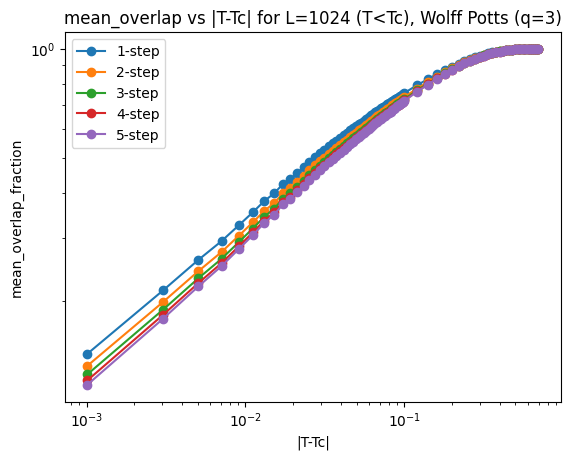

In [182]:
# Load Wolff Potts multistep data
path = "results_wolff_potts_multistep.csv"
df = pd.read_csv(path)

# print("Columns:", df.columns.tolist())
# print(df.head())

# Try to infer q from file if present; otherwise assume q=3 (common)
q = df["q"].iloc[0] if "q" in df.columns else 3

# Critical temperature for 2D q-state Potts (if q provided, use formula)
# Tc = 1 / ln(1+sqrt(q))
Tc = 1.0 / np.log(1 + np.sqrt(q))

print("Using q =", q)
print("Using Tc =", Tc)

# Largest L
Lmax = df["L"].max()
sub = df[(df["L"] == Lmax) & (df["T"] < Tc)]

# -------- MEAN OVERLAP (fraction if available, else mean_overlap_*) --------
plt.figure()

mean_cols = []
for k in range(1, 6):
    if f"mean_overlap_fraction_{k}step" in sub.columns:
        mean_cols.append(("fraction", k))
    elif f"mean_overlap_{k}step" in sub.columns:
        mean_cols.append(("plain", k))

for kind, k in mean_cols:
    if kind == "fraction":
        y = sub[f"mean_overlap_fraction_{k}step"]
        ylabel = "mean_overlap_fraction"
    else:
        y = sub[f"mean_overlap_{k}step"]
        ylabel = "mean_overlap"

    x = np.abs(sub["T"] - Tc)
    plt.loglog(x, y, "o-", label=f"{k}-step")

plt.xlabel("|T-Tc|")
plt.ylabel(ylabel if mean_cols else "mean_overlap")
plt.title(f"mean_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), Wolff Potts (q={q})")
if mean_cols:
    plt.legend()
plt.show()

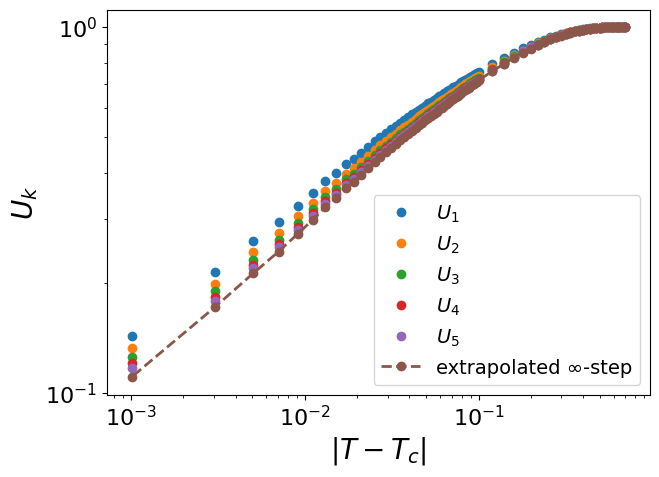

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try importing scipy for curve fitting
try:
    from scipy.optimize import curve_fit
    have_scipy = True
except Exception:
    have_scipy = False


# Select L=1024 and T<Tc
sub = df[(df['L'] == 1024) & (df['T'] < Tc)].copy()
sub = sub.sort_values('T')

# Collect k-step columns (1..5)
k_vals = np.arange(1, 6)
cols = [f'mean_overlap_fraction_{k}step' for k in k_vals]

# Exponential model: v_k = v_inf + A * exp(-k/tau)
def model(k, v_inf, A, tau):
    return v_inf + A * np.exp(-k / tau)

v_inf_list = []
x_list = []

for _, row in sub.iterrows():
    vk = row[cols].values.astype(float)
    T = row['T']
    x = abs(T - Tc)

    # Initial guesses
    p0 = [vk[-1], vk[0] - vk[-1], 1.0]

    if have_scipy:
        try:
            popt, _ = curve_fit(model, k_vals, vk, p0=p0, maxfev=5000)
            v_inf = popt[0]
        except Exception:
            # Fallback: take last value
            v_inf = vk[-1]
    else:
        # Simple fallback: assume last value ~ asymptotic
        v_inf = vk[-1]

    v_inf_list.append(v_inf)
    x_list.append(x)

x_arr = np.array(x_list)
v_inf_arr = np.array(v_inf_list)

# Also plot the raw k=1..5 curves for comparison
# Also plot the raw k=1..5 curves for comparison
plt.figure(figsize=(7,5))

for k in k_vals:
    plt.loglog(
        x_arr,
        sub[f'mean_overlap_fraction_{k}step'].values,
        'o',
        label=fr'${k}-step'
    )

# Plot extrapolated infinite-step curve (dashed)
plt.loglog(
    x_arr,
    v_inf_arr,
    'o--',               # <-- dashed
    linewidth=2,
    label='extrapolated ∞-step'
)

# ---- Axis labels ----
plt.xlabel(r'$|T-T_c|$', fontsize=20)
plt.ylabel(r'$U_k$', fontsize=20)

# ---- Tick sizes ----
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# ---- Legend ----
plt.legend(fontsize=14)

plt.grid(False)
plt.savefig('Potts_Wolff_U_multistep_vs_T.png', dpi=300,
            bbox_inches="tight",
            pad_inches=0.05)
plt.show()

# Metropolis Ising

Using Tc = 2.269185
Detected mean columns: [(1, 'mean_overlap_1step'), (2, 'mean_overlap_2step'), (3, 'mean_overlap_3step'), (4, 'mean_overlap_4step'), (5, 'mean_overlap_5step')]
Detected var columns: [(1, 'var_overlap_1step'), (2, 'var_overlap_2step'), (3, 'var_overlap_3step'), (4, 'var_overlap_4step'), (5, 'var_overlap_5step')]


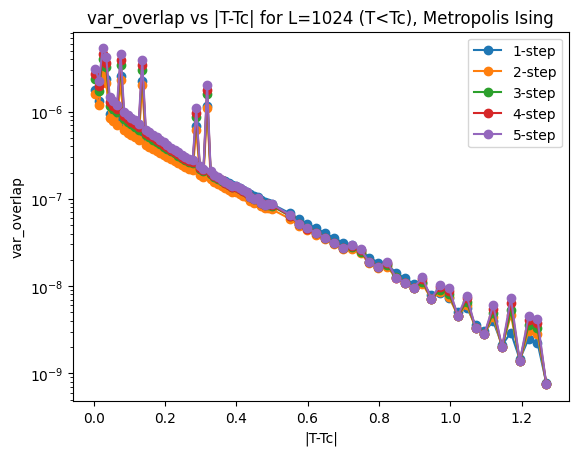

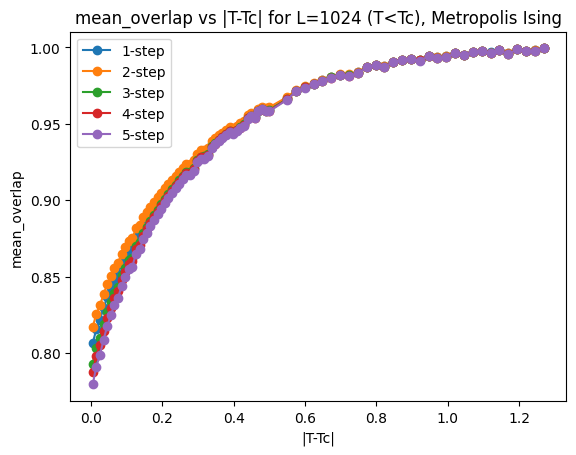

In [245]:
# Load Metropolis Ising multistep data
path = "results_metropolis_ising_multistep.csv"
df = pd.read_csv(path)

# 2D Ising critical temperature
Tc = 2.269185
print("Using Tc =", Tc)

# Largest system size
Lmax = df["L"].max()
sub = df[(df["L"] == Lmax) & (df["T"] < Tc)]

# ---- Infer column patterns ----
# Mean overlap candidates
mean_cols = []
for k in range(1, 6):
    for base in [
        f"mean_overlap_{k}step",
        f"mean_overlap_fraction_{k}step",
        f"mean_overlap_jaccard_{k}step",
    ]:
        if base in sub.columns:
            mean_cols.append((k, base))

# Variance overlap candidates
var_cols = []
for k in range(1, 6):
    for base in [
        f"var_overlap_{k}step",
        f"variance_overlap_{k}step",
    ]:
        if base in sub.columns:
            var_cols.append((k, base))

print("Detected mean columns:", mean_cols)
print("Detected var columns:", var_cols)

# ---------- VAR OVERLAP PLOT (if present) ----------
if len(var_cols) > 0:
    plt.figure()
    for k, col in var_cols:
        x = np.abs(sub["T"] - Tc)
        y = sub[col]
        plt.semilogy(x, y, "o-", label=f"{k}-step")

    plt.xlabel("|T-Tc|")
    plt.ylabel("var_overlap")
    plt.title(f"var_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), Metropolis Ising")
    plt.legend()
    plt.show()
else:
    print("No variance overlap columns found.")

# ---------- MEAN OVERLAP PLOT (if present) ----------
if len(mean_cols) > 0:
    plt.figure()
    for k, col in mean_cols:
        x = np.abs(sub["T"] - Tc)
        y = sub[col]
        plt.plot(x, y, "o-", label=f"{k}-step")

    plt.xlabel("|T-Tc|")
    plt.ylabel("mean_overlap")
    plt.title(f"mean_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), Metropolis Ising")
    plt.legend()
    plt.show()
else:
    print("No mean overlap columns found.")


In [264]:
df

,L,N,T,beta,rng_seed,mean_overlap_1step,var_overlap_1step,mean_overlap_2step,var_overlap_2step,mean_overlap_3step,var_overlap_3step,mean_overlap_4step,var_overlap_4step,mean_overlap_5step,var_overlap_5step,mean_energy_per_spin,Cv_per_spin,n_measurements,n_thermalization
0,128,16384,1.000000,1.000000,1930057826,0.999276,4.976896e-08,0.999276,4.795297e-08,0.999276,4.790314e-08,0.999276,4.789494e-08,0.999276,4.792212e-08,-1.997160,0.023434,1000000,200000
1,128,16384,1.024799,0.975801,959328447,0.999114,6.160424e-08,0.999115,5.913221e-08,0.999114,5.910859e-08,0.999114,5.901511e-08,0.999114,5.895289e-08,-1.996534,0.027234,1000000,200000
2,128,16384,1.049599,0.952745,2137082719,0.998925,7.590284e-08,0.998927,7.234125e-08,0.998926,7.236955e-08,0.998925,7.232186e-08,0.998925,7.222521e-08,-1.995803,0.031581,1000000,200000
3,128,16384,1.074398,0.930753,1166353340,0.998706,9.262429e-08,0.998709,8.771211e-08,0.998707,8.792505e-08,0.998707,8.793781e-08,0.998706,8.788048e-08,-1.994961,0.036227,1000000,200000
4,128,16384,1.099198,0.909754,196623964,0.998456,1.125073e-07,0.998459,1.064454e-07,0.998456,1.061160e-07,0.998456,1.064469e-07,0.998456,1.062448e-07,-1.994000,0.041499,1000000,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,1024,1048576,3.592823,0.278333,600589511,0.439300,4.974297e-07,0.575471,3.830854e-07,0.490171,4.063165e-07,0.516117,3.973472e-07,0.498699,3.984819e-07,-0.637976,0.229932,1000000,200000
630,1024,1048576,3.837129,0.260612,94186557,0.408706,4.666218e-07,0.573517,3.573404e-07,0.479766,3.705104e-07,0.515106,3.637768e-07,0.495314,3.646745e-07,-0.586754,0.191930,1000000,200000
631,1024,1048576,3.877847,0.257875,10119399,0.404032,4.606567e-07,0.573598,3.540532e-07,0.478300,3.643611e-07,0.515182,3.585671e-07,0.494877,3.574439e-07,-0.579069,0.185673,1000000,200000
632,1024,1048576,3.959282,0.252571,1988468728,0.395015,4.511306e-07,0.574048,3.475900e-07,0.475539,3.561632e-07,0.515487,3.511571e-07,0.494068,3.502286e-07,-0.564338,0.176250,1000000,200000


In [ ]:
mean_overlap vs E

# Metropolis Potts

Using Tc = 0.994972861071817
Detected mean columns: [(1, 'mean_overlap_1step'), (2, 'mean_overlap_2step'), (3, 'mean_overlap_3step'), (4, 'mean_overlap_4step'), (5, 'mean_overlap_5step')]
Detected var columns: [(1, 'var_overlap_1step'), (2, 'var_overlap_2step'), (3, 'var_overlap_3step'), (4, 'var_overlap_4step'), (5, 'var_overlap_5step')]


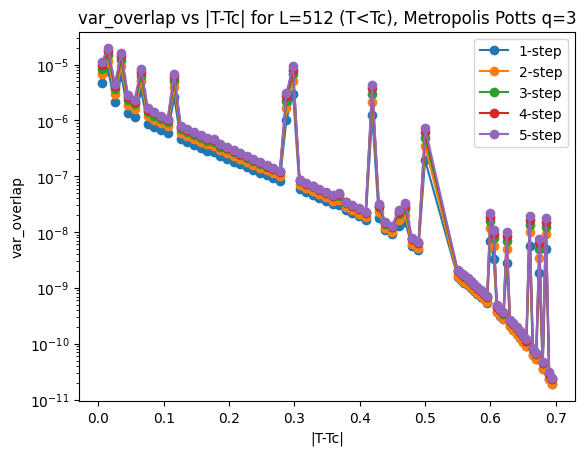

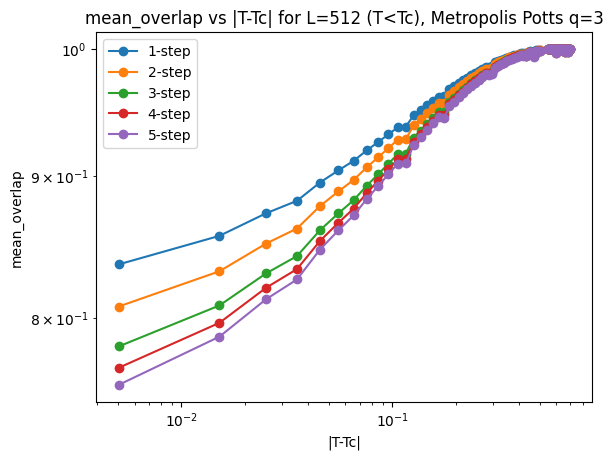

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Metropolis Potts (q=3) multistep data
path = "results_metropolis_potts3_multistep.csv"
df = pd.read_csv(path)

# print("Columns:", df.columns.tolist())
# print(df.head())

# q=3 Potts critical temperature in 2D
q = 3
Tc = 1.0 / np.log(1 + np.sqrt(q))
print("Using Tc =", Tc)

# Largest system size
Lmax = df["L"].max()
sub = df[(df["L"] == Lmax) & (df["T"] < Tc)]

# Detect mean / var columns (same logic as before)
mean_cols = []
var_cols = []

for k in range(1, 6):
    m = f"mean_overlap_{k}step"
    v = f"var_overlap_{k}step"
    if m in sub.columns:
        mean_cols.append((k, m))
    if v in sub.columns:
        var_cols.append((k, v))

print("Detected mean columns:", mean_cols)
print("Detected var columns:", var_cols)

# ---------- VAR OVERLAP ----------
if len(var_cols) > 0:
    plt.figure()
    for k, col in var_cols:
        x = np.abs(sub["T"] - Tc)
        y = sub[col]
        plt.semilogy(x, y, "o-", label=f"{k}-step")

    plt.xlabel("|T-Tc|")
    plt.ylabel("var_overlap")
    plt.title(f"var_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), Metropolis Potts q=3")
    plt.legend()
    plt.show()
else:
    print("No var_overlap columns found.")

# ---------- MEAN OVERLAP ----------
if len(mean_cols) > 0:
    plt.figure()
    for k, col in mean_cols:
        x = np.abs(sub["T"] - Tc)
        y = sub[col]
        plt.loglog(x, y, "o-", label=f"{k}-step")

    plt.xlabel("|T-Tc|")
    plt.ylabel("mean_overlap")
    plt.title(f"mean_overlap vs |T-Tc| for L={int(Lmax)} (T<Tc), Metropolis Potts q=3")
    plt.legend()
    plt.show()
else:
    print("No mean_overlap columns found.")
